# DAY 1 · ESS 배터리 수명 예측 설계
**울산 3반 · 신현중 · 2026-10-01**

`day1.md`와 제공 요구사항에 따라 Batch 1·2·3의 다섯 EDA 질문을 분석한다.
결과 → 해석 → 피처·모델 설계의 연결을 기록하며, DAY 2 모델 성능은 아직 계산하지 않는다.

기존 Scratch의 로딩·셀 단위 집계·분포·열화·정책·상관관계 흐름을 확장했다.
대용량 원본 전체를 메모리에 올리지 않고 HDF5에서 요약값과 필요한 초기 사이클만 읽는다.

**실행 환경:** 프로젝트 루트의 `.venv/bin/python`을 노트북 커널로 선택한다. 패키지는 `day1/requirements.txt`에 기록했다. Scratch의 mat73 전체 로딩을 h5py 선택 필드 로딩으로 바꿨으므로 mat73는 필요하지 않다.

In [1]:
from pathlib import Path
import os, json, re, base64, html, sys, importlib.metadata
os.environ.setdefault('MPLCONFIGDIR', '/private/tmp/day1-matplotlib')
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors, font_manager
from scipy.stats import spearmanr, pearsonr
from IPython.display import display, HTML, Image

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (current_dir, *current_dir.parents)
    if (p/'data').is_dir() and (p/'요구사항').is_dir()
    and (p/'day1/day1.ipynb').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('프로젝트 루트 또는 day1 폴더에서 실행하세요.')
DATA_DIR = PROJECT_ROOT/'data'
OUTPUT_DIR = PROJECT_ROOT/'day1/output'
IMAGE_DIR = OUTPUT_DIR/'image'
HTML_PATH = OUTPUT_DIR/'DS-MINI-Design-울산_3반-신현중.html'
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
FILES = {'B1':'2017-05-12_batchdata_updated_struct_errorcorrect.mat',
         'B2':'2018-02-20_batchdata_updated_struct_errorcorrect.mat',
         'B3':'2018-04-12_batchdata_updated_struct_errorcorrect.mat'}
BATCH_COLORS = {'B1':'#2563a7','B2':'#d25c32','B3':'#16816b'}
plt.rcParams.update({'font.size':12, 'axes.spines.top':False,
                     'axes.spines.right':False, 'figure.dpi':110})
# 그래프는 영문 변수명을 사용하여 환경별 한글 폰트 누락을 피한다. 해석은 한국어로 작성한다.
REPORT = []
FIGURES = []
def table(df, index=False):
    labels={'batch':'배치','raw_cells':'원본 셀','target_cells':'라벨 보유','missing_target':'라벨 결측','min_cycles':'최소 기록','max_cycles':'최대 기록','early5':'5사이클 확보','early100':'100사이클 확보','delta_available':'ΔQ 확보','bad_QD_rows':'QD 비정상 행','missing_summary':'NaN 요약값','count':'셀 수','mean':'평균','median':'중앙값','std':'표준편차','min':'최솟값','max':'최댓값','50%':'중앙값','n':'유효 n','cell_id':'셀 ID','policy':'충전 정책','exclusion_reason':'제외 사유','short':'<500 셀','long':'>1000 셀','middle':'500–1000 셀','class0':'<550 셀','class1':'≥550 셀','short_pct':'<500 (%)','long_pct':'>1000 (%)','class0_pct':'<550 (%)','cycle_life':'총 수명','qref':'초기 QD (Ah)','last_q_ratio':'종료/초기 QD','knee_candidates':'knee 후보 수','median_knee':'knee 중앙 사이클','median_sse_gain':'SSE 개선 중앙값','end_above_80':'종료비율>80% 셀','median_end_ratio':'종료비율 중앙값','median_initial_QD':'초기 QD 중앙값(Ah)','signal':'신호','relationship':'수명 상관관계','raw_supported':'raw 전압범위 확보','median_offset_3_4V':'3.4V ΔQ 중앙값(Ah)','median_raw_rmse':'raw RMSE 중앙값(Ah)','offset_3_4V':'3.4V ΔQ(Ah)','rmse_raw_vs_qdlin':'raw RMSE(Ah)','raw_low_voltage_zero_Qd':'저전압 Qd≤0 표본','feature':'피처','early_degradation_relationship':'초기 QD 기울기 상관','feature_1':'피처 1','feature_2':'피처 2','planned_split':'분할 계획','cells':'셀 수','policy_groups':'정책 그룹 수','min_life':'최소 수명','max_life':'최대 수명','unseen_policy_cells':'미관측 정책 셀','total_cells':'총 셀','unseen_pct':'미관측 비율 (%)'}
    return df.rename(columns=labels).to_html(index=index, border=0, float_format=lambda x:(f'{x:.2e}' if 0 < abs(x) < .001 else f'{x:.3f}'), na_rep='—', escape=True)
def add(title, body):
    REPORT.append({'title':title,'body':body})
    display(HTML('<h3>'+html.escape(title)+'</h3>'+body))
def fig_save(fig, name, caption):
    path=IMAGE_DIR/name
    fig.savefig(path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    FIGURES.append(name)
    display(Image(filename=str(path)))
    return '<figure><img alt="'+html.escape(caption,quote=True)+'" src="data:image/png;base64,'+base64.b64encode(path.read_bytes()).decode()+'"><figcaption>'+html.escape(caption)+'</figcaption></figure>'
def r_text(df, feature, target='cycle_life'):
    a=df[[feature,target]].replace([np.inf,-np.inf],np.nan).dropna()
    if len(a)<3 or a[feature].nunique()<2: return f'n={len(a)}, 산출 불가'
    return f"Pearson r={a[feature].corr(a[target]):.3f}, Spearman ρ={a[feature].corr(a[target],method='spearman'):.3f}, n={len(a)}"
print('Python:',sys.executable)
print('프로젝트 루트:',PROJECT_ROOT)
print('그래프:',IMAGE_DIR)
print('HTML:',HTML_PATH)

Python: /Users/u085/Documents/교육자료/데이터 분석/.venv/bin/python
프로젝트 루트: /Users/u085/Documents/교육자료/데이터 분석
그래프: /Users/u085/Documents/교육자료/데이터 분석/day1/output/image
HTML: /Users/u085/Documents/교육자료/데이터 분석/day1/output/DS-MINI-Design-울산_3반-신현중.html


## 0. 로딩·자료 구조·품질 점검

실제 `summary.cycle` 번호와 사이클 배열의 길이·순차성을 확인하고 대응시킨다.
`QD←QDischarge`, `QC←QCharge`, 정책은 `policy_readable`, 전압 축은 `Vdlin`이다.
원본은 보존하고 결측 타깃만 수명 관련 EDA에서 제외한다. 초기에 누락된 측정과 비정상 용량은 별도 기록한다.

In [2]:
def read_array(f, obj):
    a=obj[()]
    if h5py.check_dtype(ref=obj.dtype) is not None:
        a=np.concatenate([np.asarray(f[r][()]).ravel() for r in a.ravel()])
    return np.asarray(a).ravel()
def text_value(f, ref):
    return ''.join(chr(int(v)) for v in read_array(f,f[ref]) if v)
def interp_discharge(raw, grid):
    # I < -0.1 A인 방전 구간만 사용. 동일 전압의 Qd 중앙값으로 보간, 외삽 금지.
    d=pd.DataFrame(raw)
    d=d[np.isfinite(d[['V','Qd','I']]).all(axis=1) & (d.I < -0.1)]
    d=d.groupby('V',as_index=False).Qd.median().sort_values('V')
    if len(d)<20 or d.V.min()>grid.min() or d.V.max()<grid.max():
        return None
    return np.interp(grid,d.V,d.Qd)
raw_cells={}
metadata=[]
structure=[]
GRID=np.linspace(2.1,3.4,500)  # 원본 방전 V 범위와 맞는지 셀별로 확인
for bid,filename in FILES.items():
    with h5py.File(DATA_DIR/filename,'r') as f:
        b=f['batch']
        structure.append({'batch':bid,'cells':len(b['summary']), 'fields':', '.join(b.keys())})
        for i in range(len(b['summary'])):
            cid=f'{bid}c{i}'
            sg=f[b['summary'][i,0]]
            cg=f[b['cycles'][i,0]]
            rename={'QDischarge':'QD','QCharge':'QC'}
            s=pd.DataFrame({rename.get(k,k):read_array(f,sg[k]) for k in sg.keys()})
            life=float(read_array(f,f[b['cycle_life'][i,0]])[0])
            policy=text_value(f,b['policy_readable'][i,0])
            v=read_array(f,f[b['Vdlin'][i,0]])
            assert len(s)==len(cg['Qdlin']), f'{cid}: summary/cycles 길이 불일치'
            assert np.array_equal(s.cycle.to_numpy(),np.arange(1,len(s)+1)), f'{cid}: 비순차 cycle'
            assert len(v)==1000 and np.all(np.diff(v)<0), f'{cid}: Vdlin 재검토 필요'
            qcurves={}; raw={}
            for cycle in (10,100):
                positions=np.flatnonzero(s.cycle.to_numpy()==cycle)
                if len(positions)!=1: continue
                pos=int(positions[0])
                q=read_array(f,f[cg['Qdlin'][pos,0]])
                if len(q)==len(v) and np.isfinite(q).all(): qcurves[cycle]=q
                values={k:read_array(f,f[cg[k][pos,0]]) for k in ('V','Qd','I')}
                if len({len(x) for x in values.values()})==1: raw[cycle]=values
            base=s.loc[s.cycle.between(2,10),'QD']
            base=base[(base>0)&np.isfinite(base)]
            qref=float(base.median()) if len(base) else np.nan
            q=s.QD.to_numpy()
            bad=(~np.isfinite(q))|(q<=0)|(q>qref*1.3)
            # 80% 하한으로 일괄 삭제하지 않아 실제 말기 열화를 보존한다.
            p=re.match(r'^(\d+(?:\.\d+)?)C\((\d+(?:\.\d+)?)%\)-(\d+(?:\.\d+)?)C(.*)$',policy)
            vals=[float(p.group(j)) for j in (1,2,3)] if p else [np.nan]*3
            rec={'cell_id':cid,'batch':bid,'index':i,'cycle_life':life,'policy':policy,
                 'C1':vals[0],'switch_SOC':vals[1],'C2':vals[2],
                 'new_structure':int('newstructure' in policy),
                 'barcode_raw':','.join(map(str,read_array(f,f[b['barcode'][i,0]]))),
                 'n_cycles':len(s),'qref':qref,'last_q_ratio':float(s.QD.tail(5).median()/qref),
                 'bad_QD_rows':int(bad.sum()),'missing_summary_values':int(s.isna().sum().sum()),
                 'has_5':bool(set(range(1,6)).issubset(s.cycle)),
                 'has_100':bool(set(range(1,101)).issubset(s.cycle)),
                 'has_delta':10 in qcurves and 100 in qcurves,
                 'v_min':float(v.min()),'v_max':float(v.max()),'v_points':len(v),
                 'raw_low_voltage_zero_Qd':sum(int(((a['I']<-.1)&(a['V']<2.5)&(a['Qd']<=0)).sum()) for a in raw.values())}
            metadata.append(rec)
            raw_cells[cid]={'summary':s,'v':v,'qcurves':qcurves,'raw':raw,'bad_q':bad}
    print(bid,'선택 필드 추출 완료')
meta=pd.DataFrame(metadata)
meta['usable_target']=np.isfinite(meta.cycle_life)&(meta.cycle_life>0)
meta['exclusion_reason']=np.where(meta.usable_target,'보존','cycle_life 결측; 수명 관련 분석에서 제외')
usable=meta[meta.usable_target].copy()
quality=meta.groupby('batch').agg(raw_cells=('cell_id','size'),target_cells=('usable_target','sum'),
    missing_target=('usable_target',lambda s:int((~s).sum())),min_cycles=('n_cycles','min'),max_cycles=('n_cycles','max'),
    early5=('has_5','sum'),early100=('has_100','sum'),delta_available=('has_delta','sum'),
    bad_QD_rows=('bad_QD_rows','sum'),missing_summary=('missing_summary_values','sum')).reset_index()
exclusions=meta[~meta.usable_target][['cell_id','policy','exclusion_reason']]
# 동일 barcode가 배치별 다른 정책에 재사용되는지 확인: 실제 물리 셀 ID로 사용할 수 없음.
barcode_groups=meta.groupby('barcode_raw').filter(lambda x:x.batch.nunique()>1)
barcode_collisions=barcode_groups.groupby('barcode_raw').agg(cells=('cell_id','size'),policies=('policy','nunique'))
body=table(quality)+table(exclusions)+f'''<p><b>핵심:</b> 원본 {len(meta)}개 중 수명 라벨이 있는 {len(usable)}개를 수명 관련 분석에 사용한다. 누락 라벨은 추정·대치하지 않는다. 용량의 비정상 행은 전체 곡선 표시·초기 피처 계산에서만 제외하고 원본을 보존한다. 초기 기준 용량은 사이클 2–10의 양수 QD 중앙값이며, QD≤0 / 비유한값 / 초기 기준의 1.3배 초과를 비정상으로 표시한다. 80% 이하 용량은 제거하지 않는다.</p>
<p><b>자료 대응:</b> 모든 셀에서 summary.cycle=1…N과 cycles 배열 길이가 일치한다. 따라서 확인된 실제 cycle 위치로 10·100을 선택했다. Vdlin은 모든 셀에서 1,000포인트, 3.5→2.0V로 확인됐다. 문서 예시의 3.6V를 사용하지 않았다.</p>
<p><b>동일 물리 셀 확인의 한계:</b> 배치 간 반복되는 barcode 직렬화 값은 {len(barcode_collisions)}개이며 서로 다른 정책에도 재사용된다. 이 필드는 물리 셀 식별자로 신뢰할 수 없다. 원논문 로딩 코드는 이어서 측정된 셀의 결합·제외를 제공하지만, 로컬 Batch 2는 47셀 및 다른 정책 구성으로 원논문 예제와 대응하지 않는다. 해당 인덱스 매핑을 적용하지 않았다. 동일 셀의 배치 간 중복이 없다는 보장은 확보하지 못했으므로 DAY 2 분할 전 실험 로그·실제 식별자 확인이 필요하다.</p>
<p><b>EOL 주의:</b> 수명 라벨이 있는 Batch 1·3 모든 셀의 기록 종료 비율은 초기 기준 용량 대비 80%보다 높고, Batch 2는 모두 아래다. cycle_life를 제공 라벨로 유지하되, 미완주·명목용량 기준·라벨 정의 차이를 확인해야 한다. 종료 길이로 누락 라벨을 생성하거나 원논문 수명을 임의로 더하지 않았다.</p>'''
add('데이터 범위와 품질 · 원본 보존, 라벨 결측 구분',body)
meta.to_csv(OUTPUT_DIR/'cell_audit.csv',index=False)
quality.to_csv(OUTPUT_DIR/'batch_quality.csv',index=False)
display(pd.DataFrame(structure))

B1 선택 필드 추출 완료


B2 선택 필드 추출 완료


B3 선택 필드 추출 완료


,batch,cells,fields
0,B1,46,"Vdlin, barcode, channel_id, cycle_life, cycles..."
1,B2,47,"Vdlin, barcode, channel_id, cycle_life, cycles..."
2,B3,46,"Vdlin, barcode, channel_id, cycle_life, cycles..."


## 1. Cycle Life 분포

셀당 한 행을 사용하고 동일한 histogram 구간으로 배치를 비교한다.
장수명 >1,000 / 단수명 <500은 설명용 구분이며, 550 분류 기준과 다르다.

/var/folders/mx/q8zv1gy500d5tl5xlpyrc2240000gn/T/ipykernel_70402/1705105088.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[1,k].boxplot(d.cycle_life,vert=False,patch_artist=True,boxprops={'facecolor':BATCH_COLORS[bid]})
/var/folders/mx/q8zv1gy500d5tl5xlpyrc2240000gn/T/ipykernel_70402/1705105088.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[1,k].boxplot(d.cycle_life,vert=False,patch_artist=True,boxprops={'facecolor':BATCH_COLORS[bid]})
/var/folders/mx/q8zv1gy500d5tl5xlpyrc2240000gn/T/ipykernel_70402/1705105088.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[1,k].boxplot(d.cycle_life,vert=False,patch_artist=True,boxprops={'fa

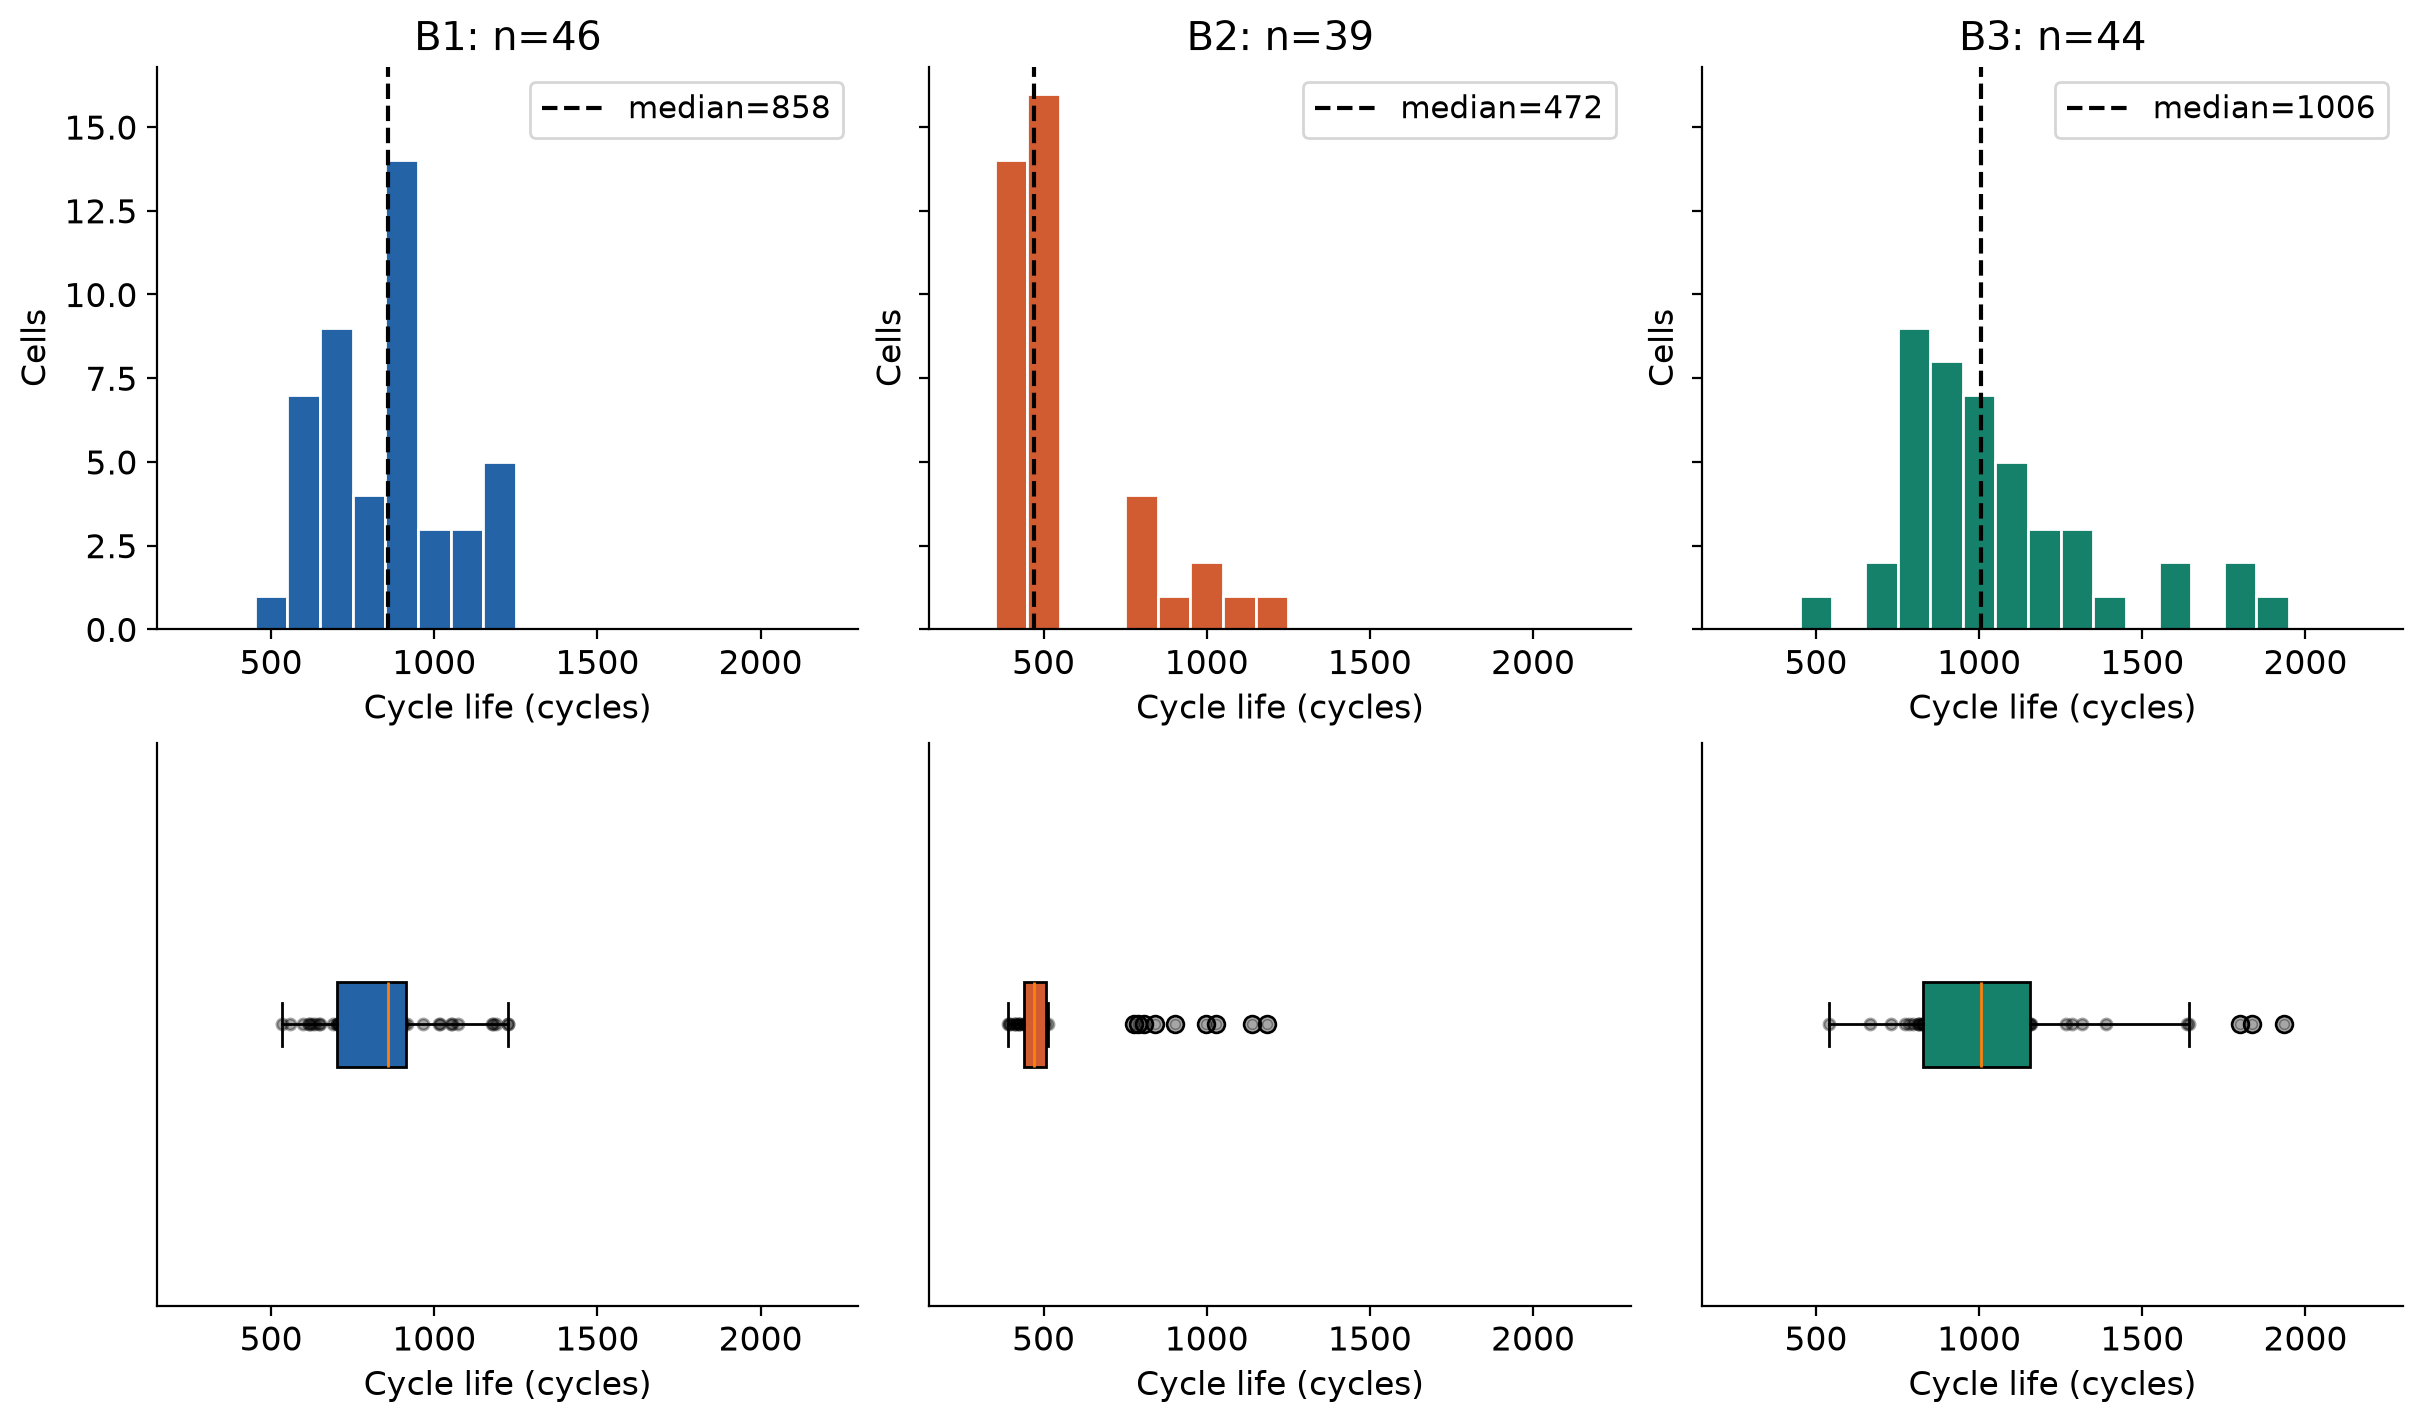


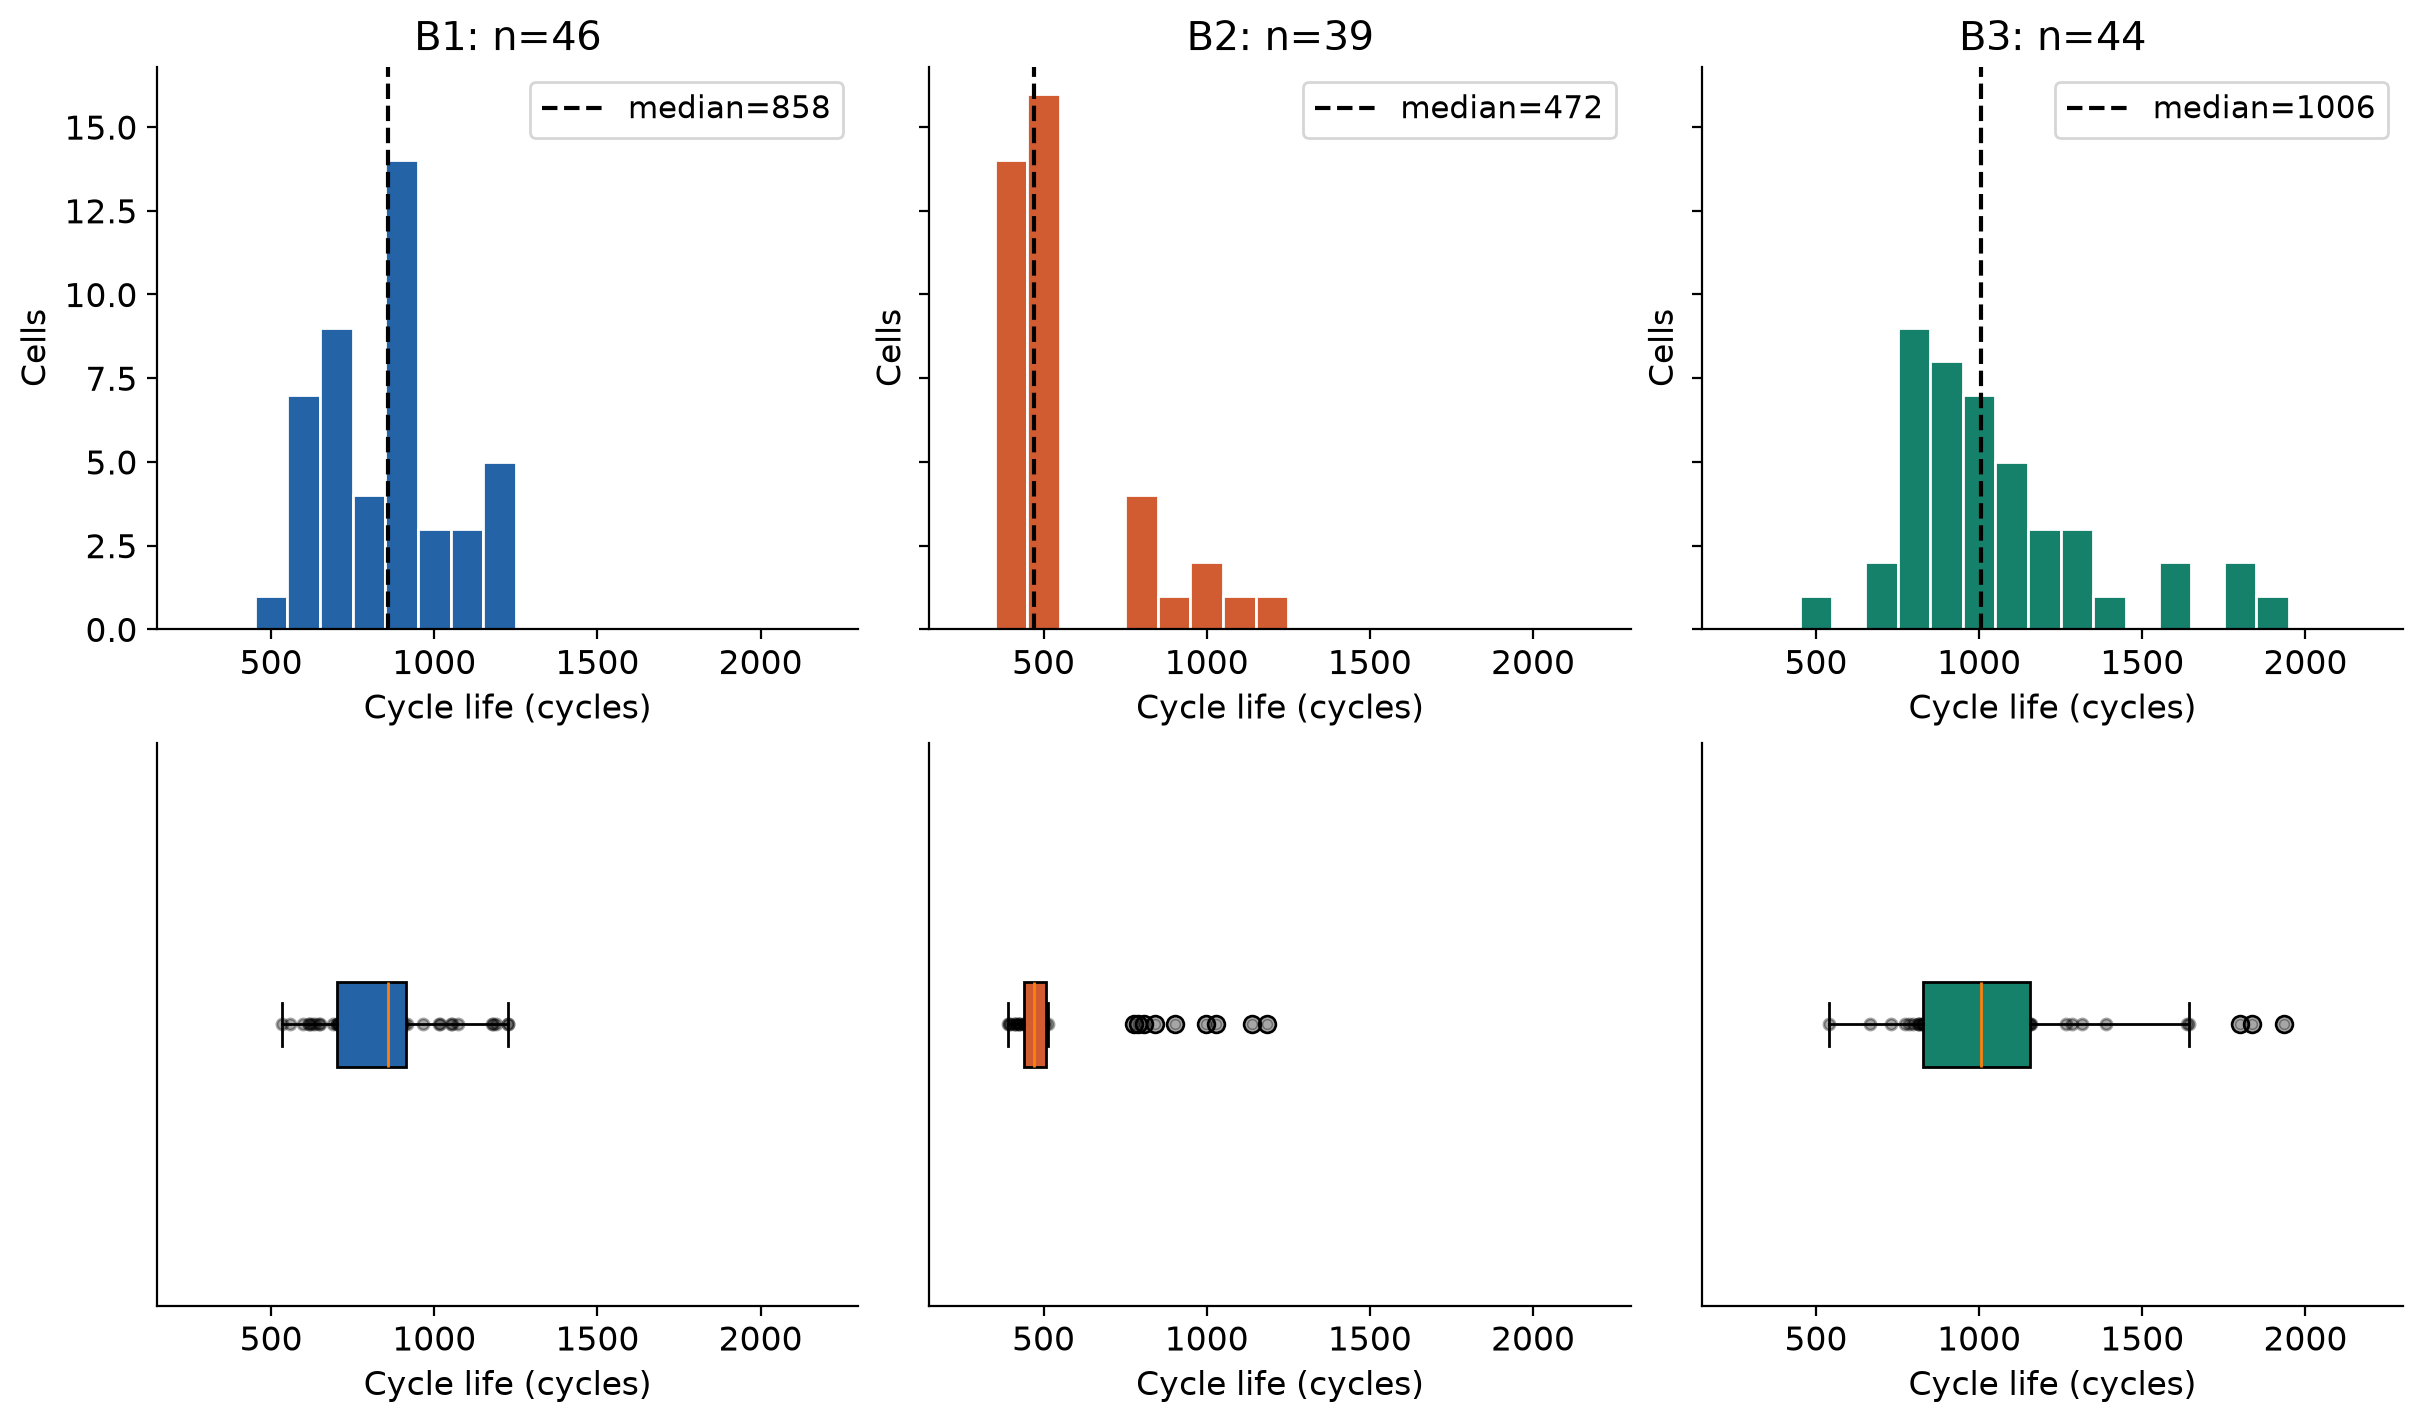

In [3]:
stats=usable.groupby('batch').cycle_life.describe().reset_index()
groups=usable.groupby('batch').agg(n=('cell_id','size'),short=('cycle_life',lambda x:int((x<500).sum())),
    long=('cycle_life',lambda x:int((x>1000).sum())),class0=('cycle_life',lambda x:int((x<550).sum())),
    class1=('cycle_life',lambda x:int((x>=550).sum()))).reset_index()
groups['middle']=groups.n-groups.short-groups.long
for col in ['short','long','class0']: groups[col+'_pct']=100*groups[col]/groups.n
fig,axs=plt.subplots(2,3,figsize=(12,7),sharex='row',sharey='row',layout='constrained')
bins=np.arange(150,2301,100)
for k,bid in enumerate(FILES):
    d=usable[usable.batch==bid]
    axs[0,k].hist(d.cycle_life,bins=bins,color=BATCH_COLORS[bid],edgecolor='white')
    axs[0,k].axvline(d.cycle_life.median(),color='black',ls='--',label=f'median={d.cycle_life.median():.0f}')
    axs[0,k].set(title=f'{bid}: n={len(d)}',xlabel='Cycle life (cycles)',ylabel='Cells',xlim=(150,2300))
    axs[0,k].legend(fontsize=11)
    axs[1,k].boxplot(d.cycle_life,vert=False,patch_artist=True,boxprops={'facecolor':BATCH_COLORS[bid]})
    axs[1,k].scatter(d.cycle_life,np.ones(len(d)),s=16,c='black',alpha=.35)
    axs[1,k].set(xlabel='Cycle life (cycles)',yticks=[],xlim=(150,2300))
img=fig_save(fig,'q1_cycle_life_distribution.png','배치별 수명 분포: 동일 구간 히스토그램과 셀 단위 박스플롯. 150–2,300 밖의 관측치는 없다.')
assert usable.cycle_life.between(150,2300).all()
extremes=pd.concat([d.nsmallest(1,'cycle_life') for _,d in usable.groupby('batch')]+[d.nlargest(1,'cycle_life') for _,d in usable.groupby('batch')])
summary='; '.join(f"{r.batch}: 중앙값 {stats.set_index('batch').loc[r.batch,'50%']:.1f}, 단수명 {r.short}/{r.n}({r.short_pct:.1f}%), 장수명 {r.long}/{r.n}({r.long_pct:.1f}%)" for r in groups.itertuples())
add('Q1 · 수명 분포가 배치마다 달라지는가?',img+table(stats)+table(groups)+
    '<p><b>관찰:</b> '+summary+'.</p><p><b>해석:</b> 배치 이동 시 타깃 분포가 달라진다. 단순히 동일 분포의 새 표본으로 가정할 수 없다. 극단 수명 셀은 삭제하지 않고 아래의 정책·용량 종료 상태를 확인한다. 짧은 수명 자체는 측정 오류의 근거가 아니다.</p>'+table(extremes[['cell_id','cycle_life','policy','qref','last_q_ratio']])+
    '<p><b>전략:</b> 수명 구간별 잔차·MAPE를 DAY 2에서 따로 확인한다. 550 분류 기준은 Batch 1에 단수명 표본이 거의 없어 안정적인 학습·검증이 어렵다. 총 수명을 연속값으로 예측하는 회귀를 우선 검토한다.</p>')
stats.to_csv(OUTPUT_DIR/'cycle_life_statistics.csv',index=False)
groups.to_csv(OUTPUT_DIR/'life_groups.csv',index=False)

## 2. 방전 용량 열화와 knee 탐색

색상은 실제 수명이다. 정규화 QD의 0.8선은 초기 관측 기준이며 제공 라벨의 EOL을 재정의하지 않는다.
Knee는 전체 기록에서 구간별 연속 선형회귀의 SSE 개선과 기울기 증가를 확인하는 **설명용 후보**다.
초기 피처에는 100사이클 이내만 사용한다.

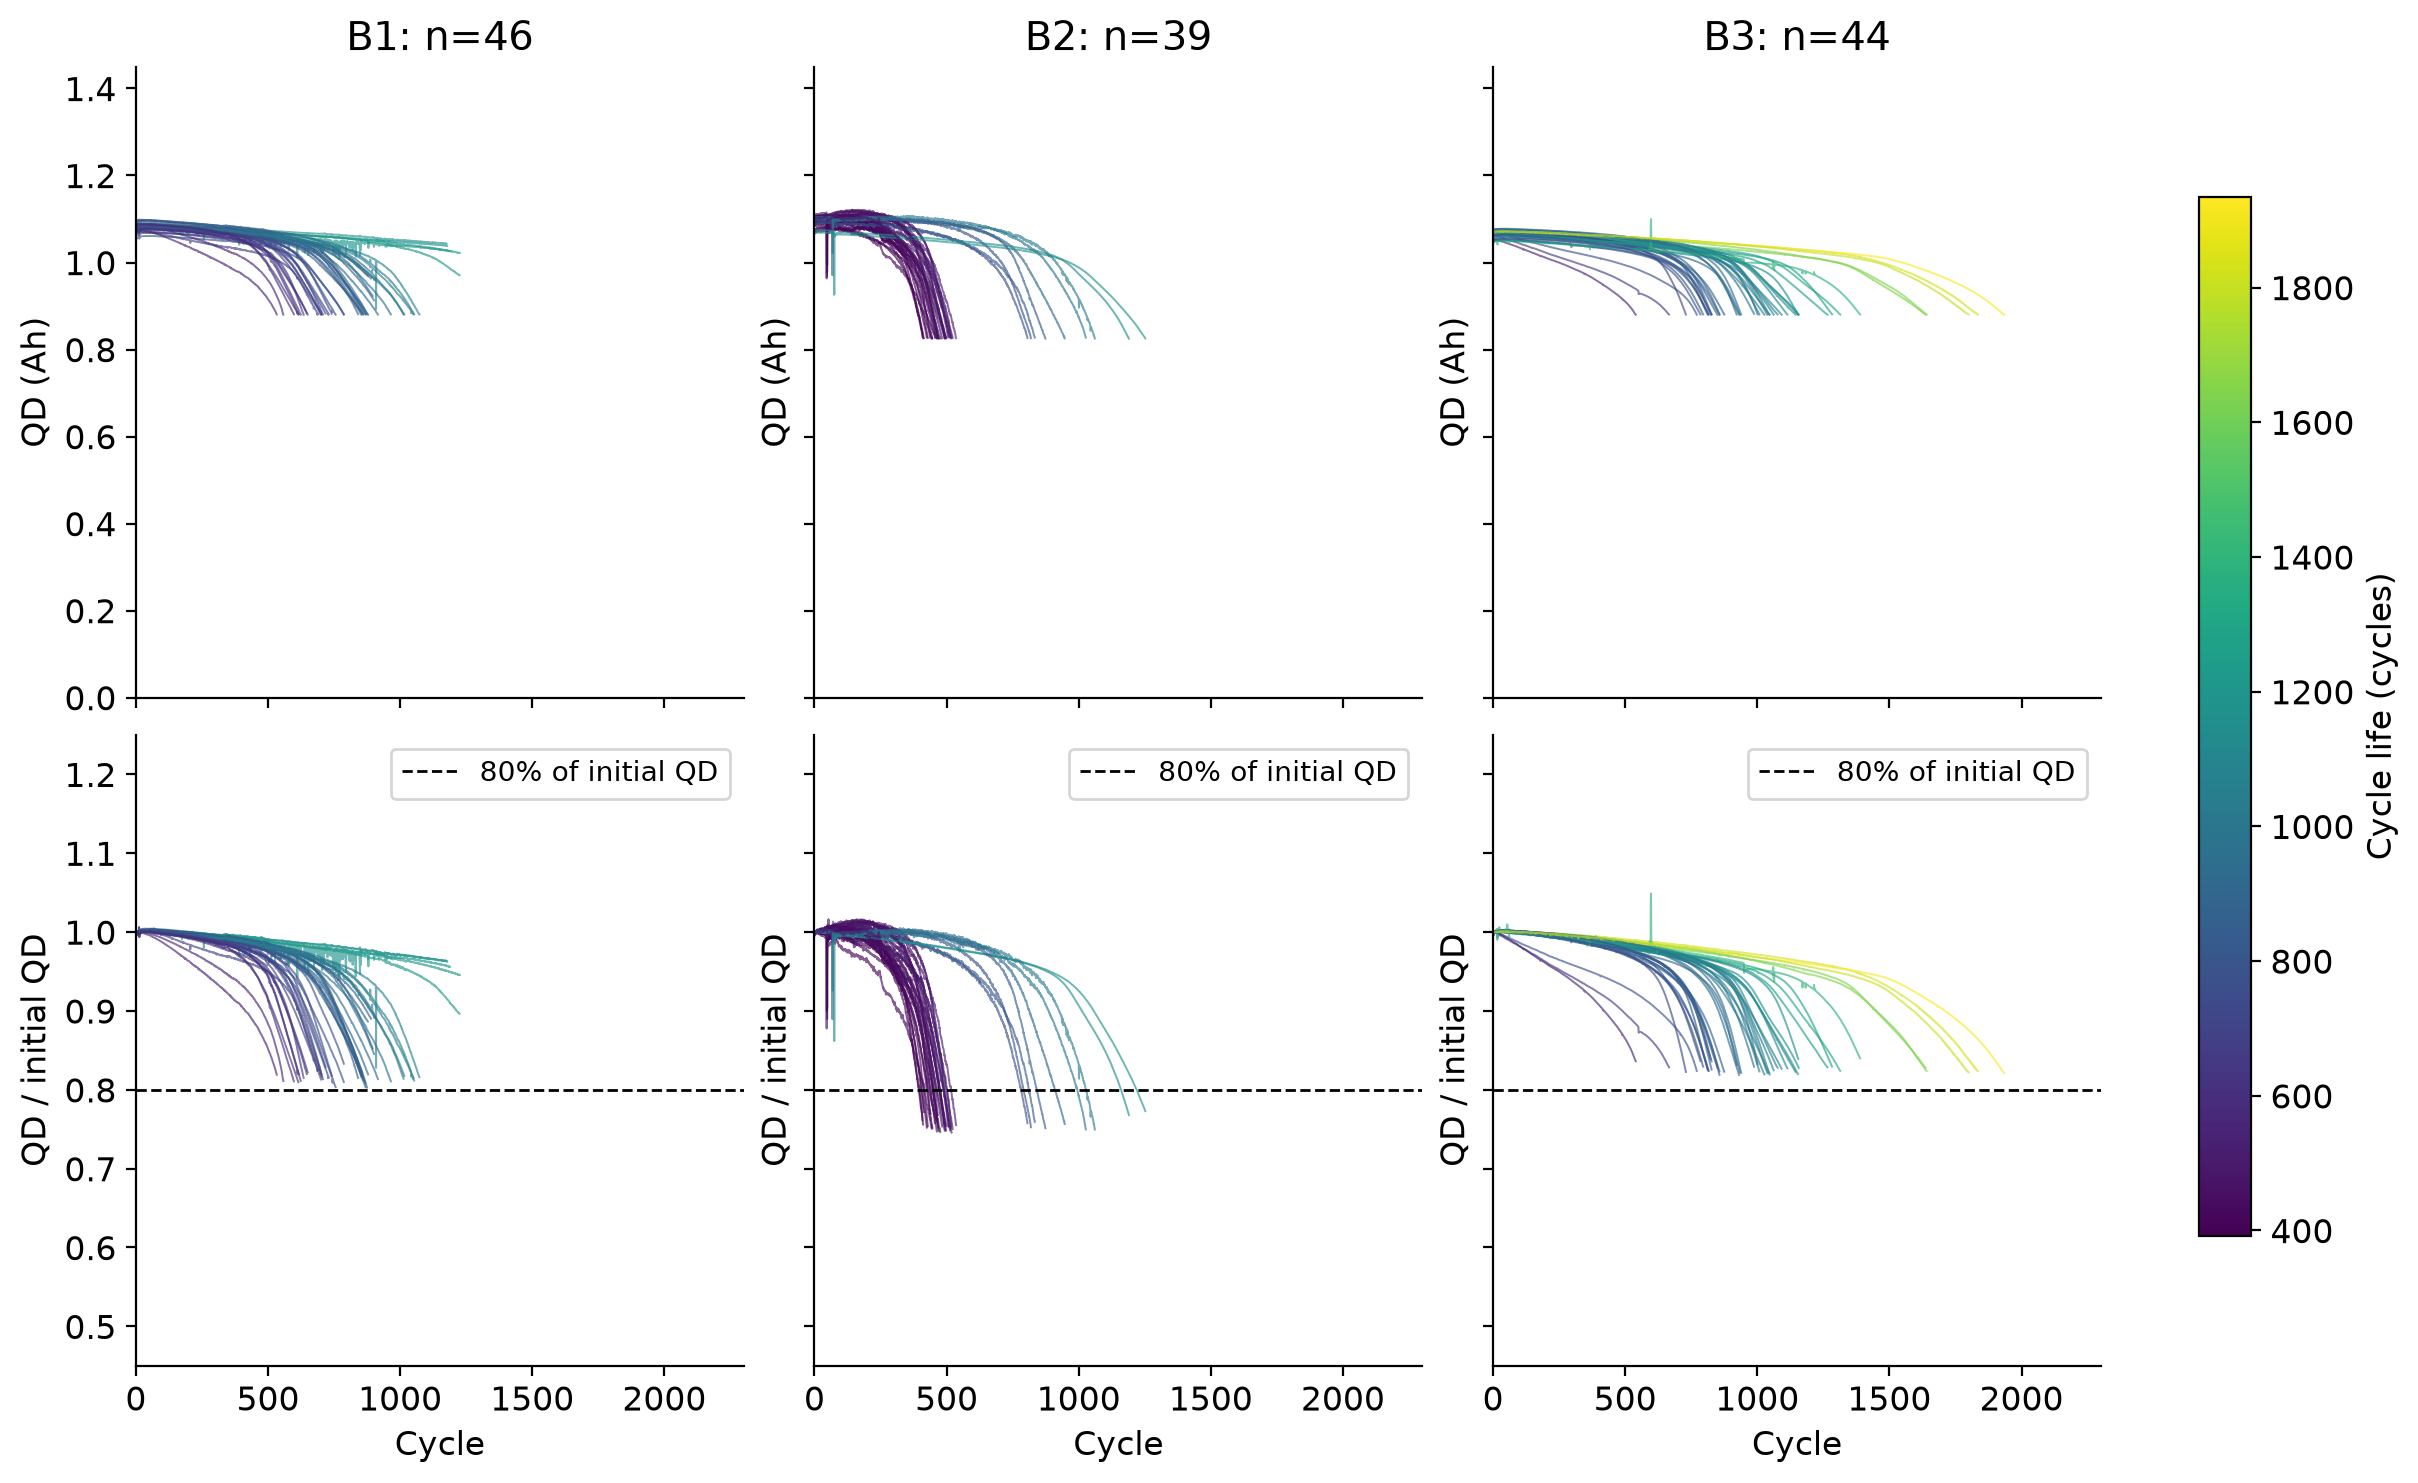

배치,유효 n,knee 후보 수,knee 중앙 사이클,SSE 개선 중앙값
B1,46,45,607.000,0.968
B2,39,39,356.000,0.941
B3,44,44,818.500,0.952
배치,유효 n,종료비율>80% 셀,종료비율 중앙값,초기 QD 중앙값(Ah)
B1,46,46,0.819,1.081
B2,39,0,0.759,1.097
B3,44,44,0.826,1.068

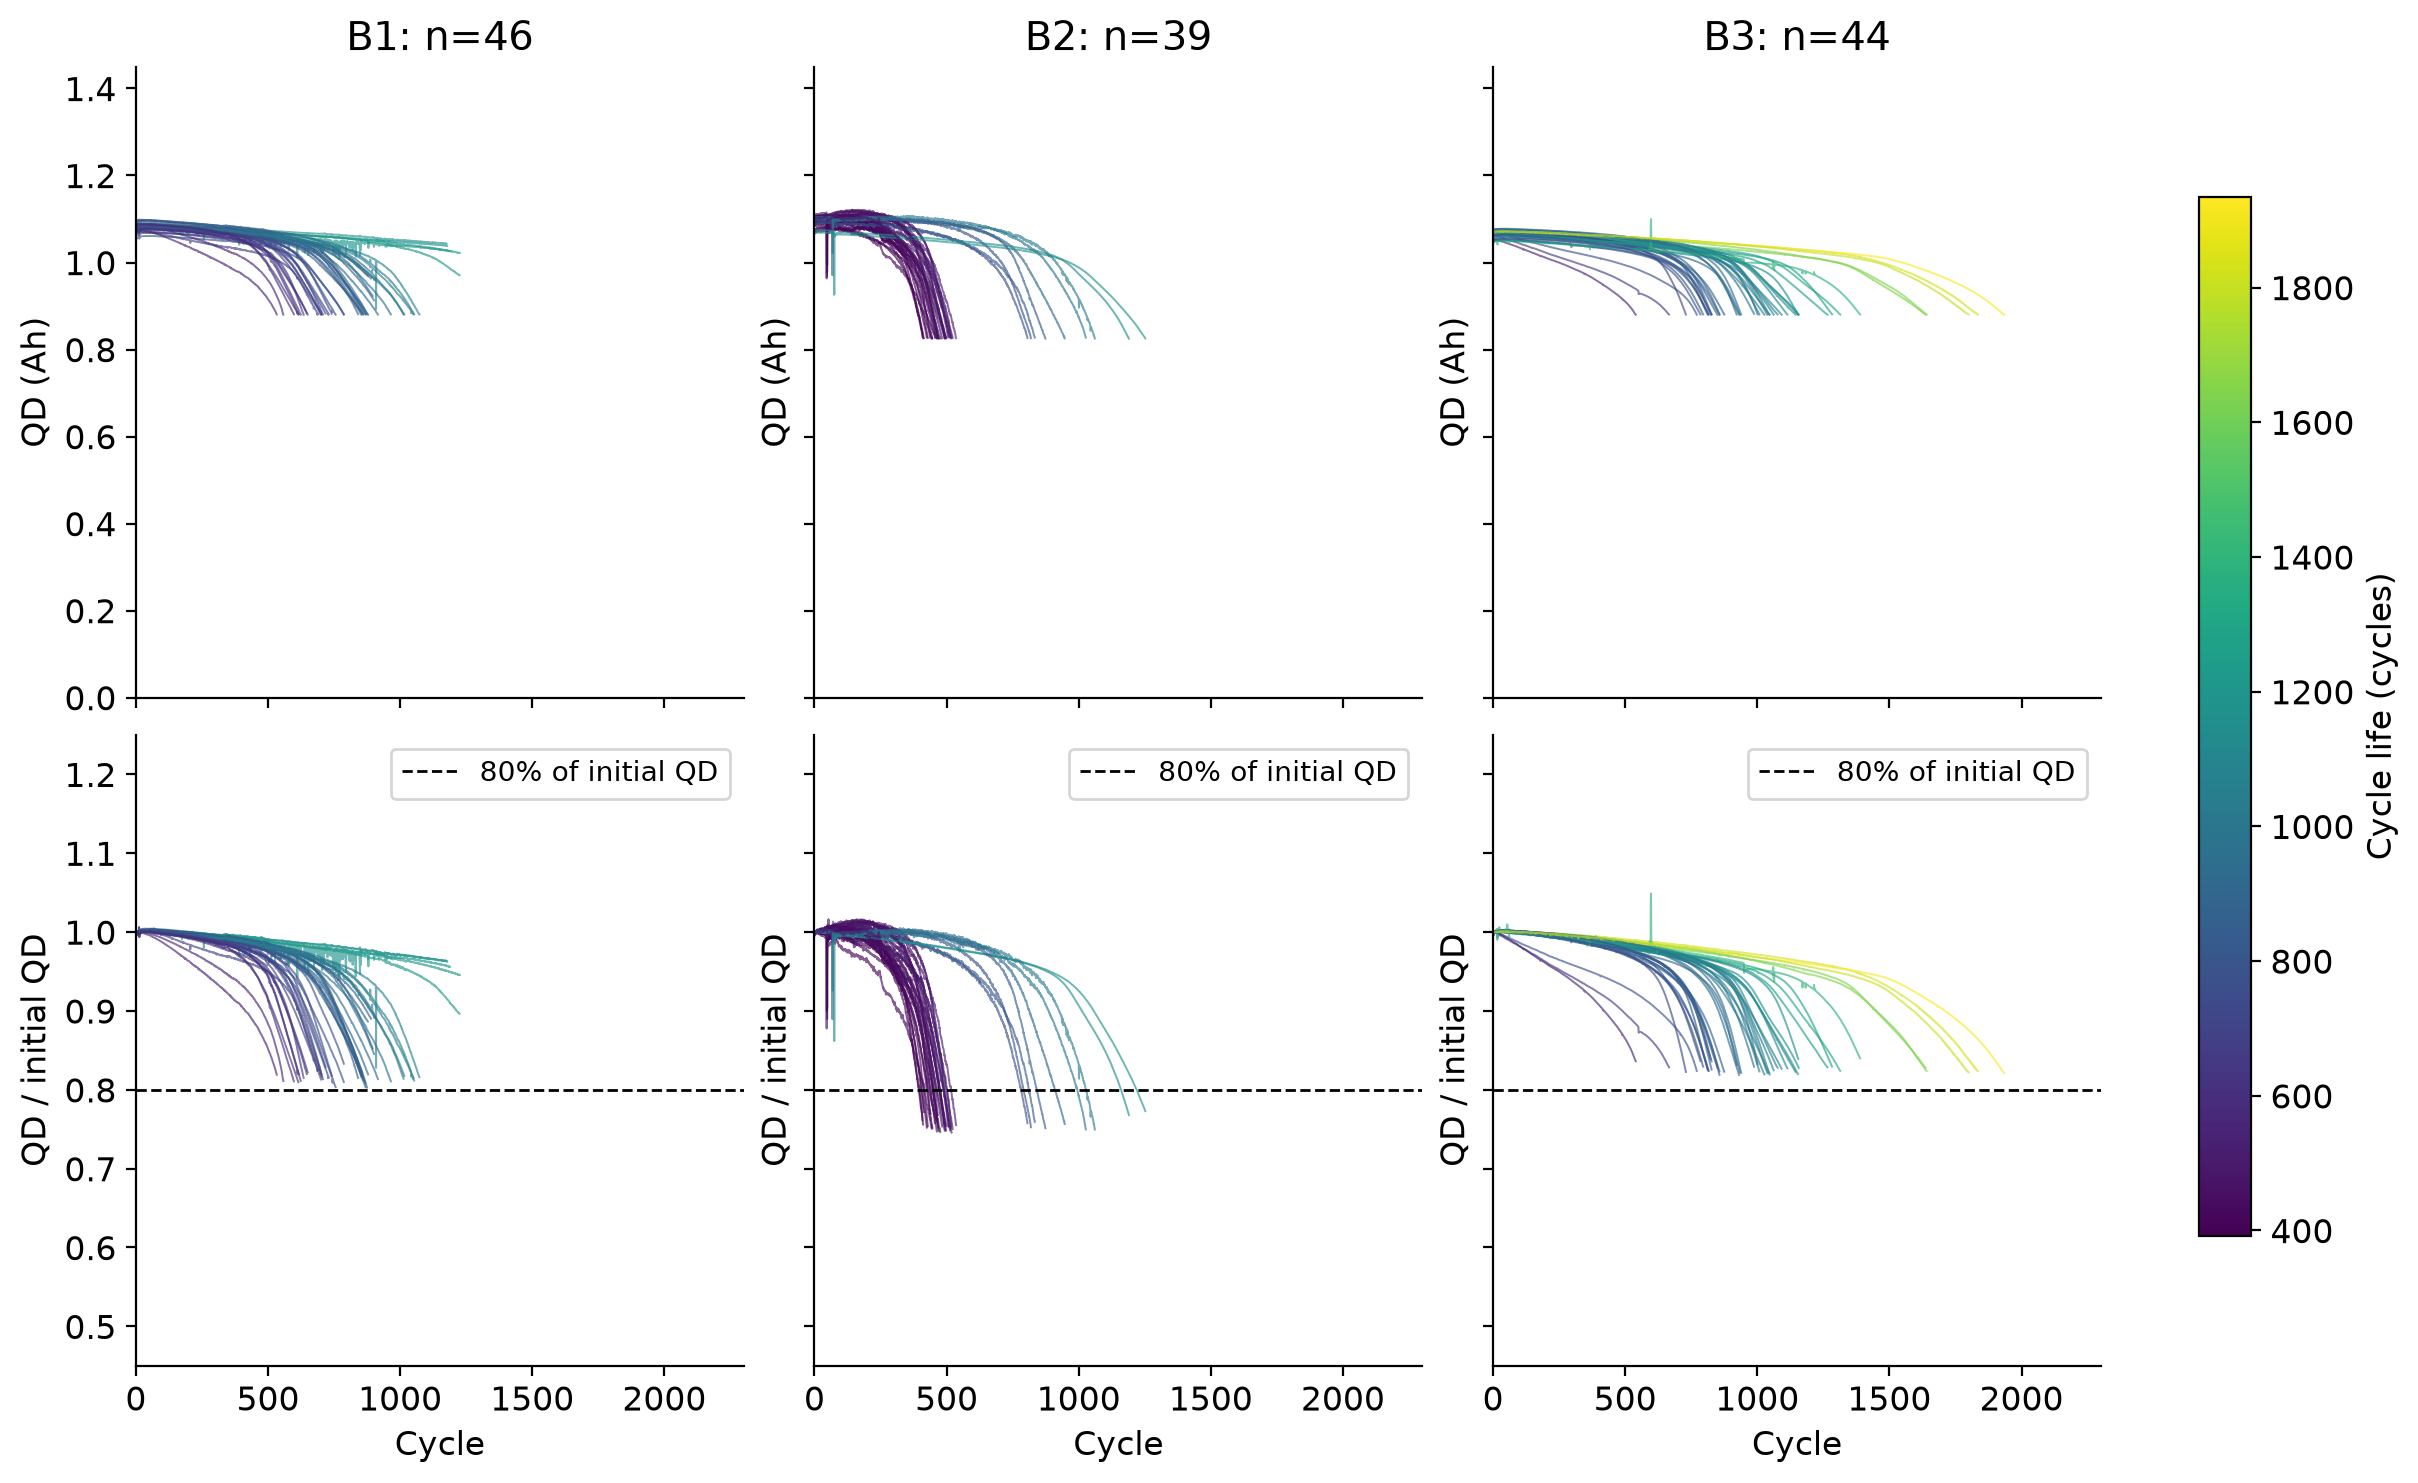

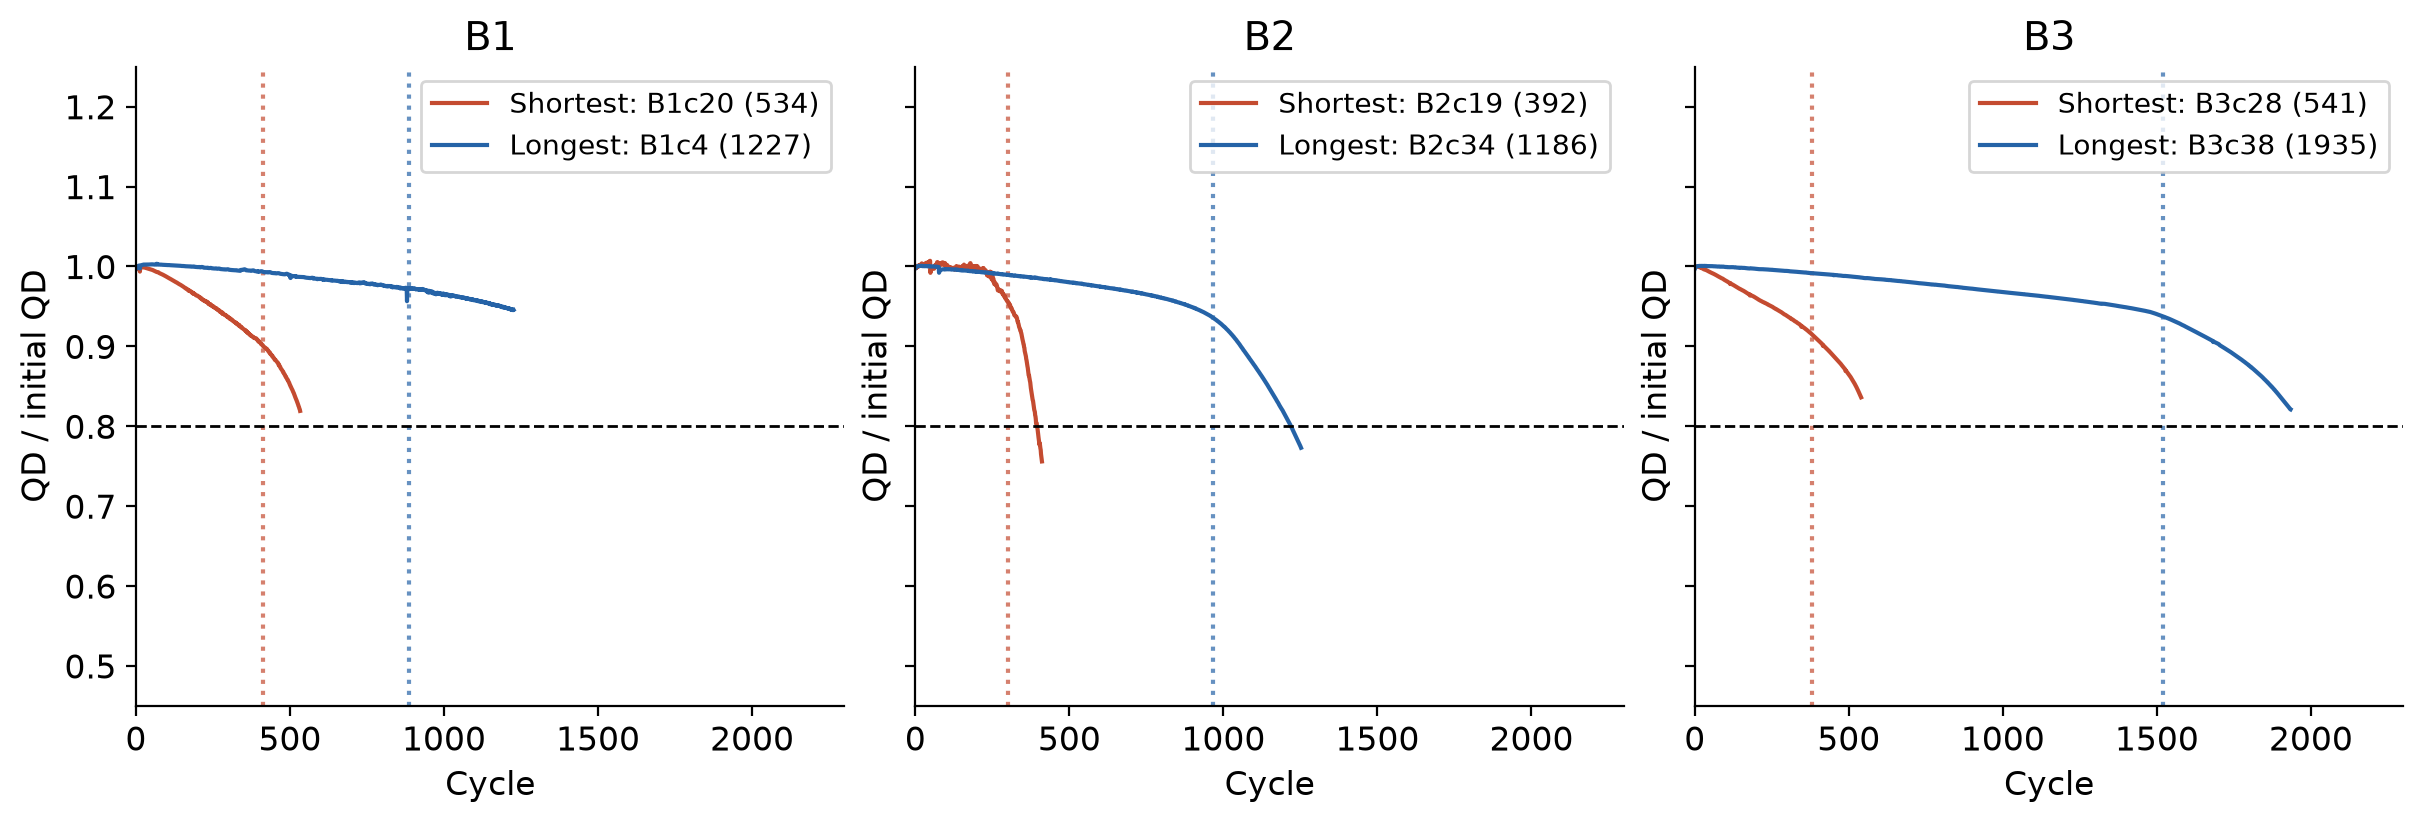


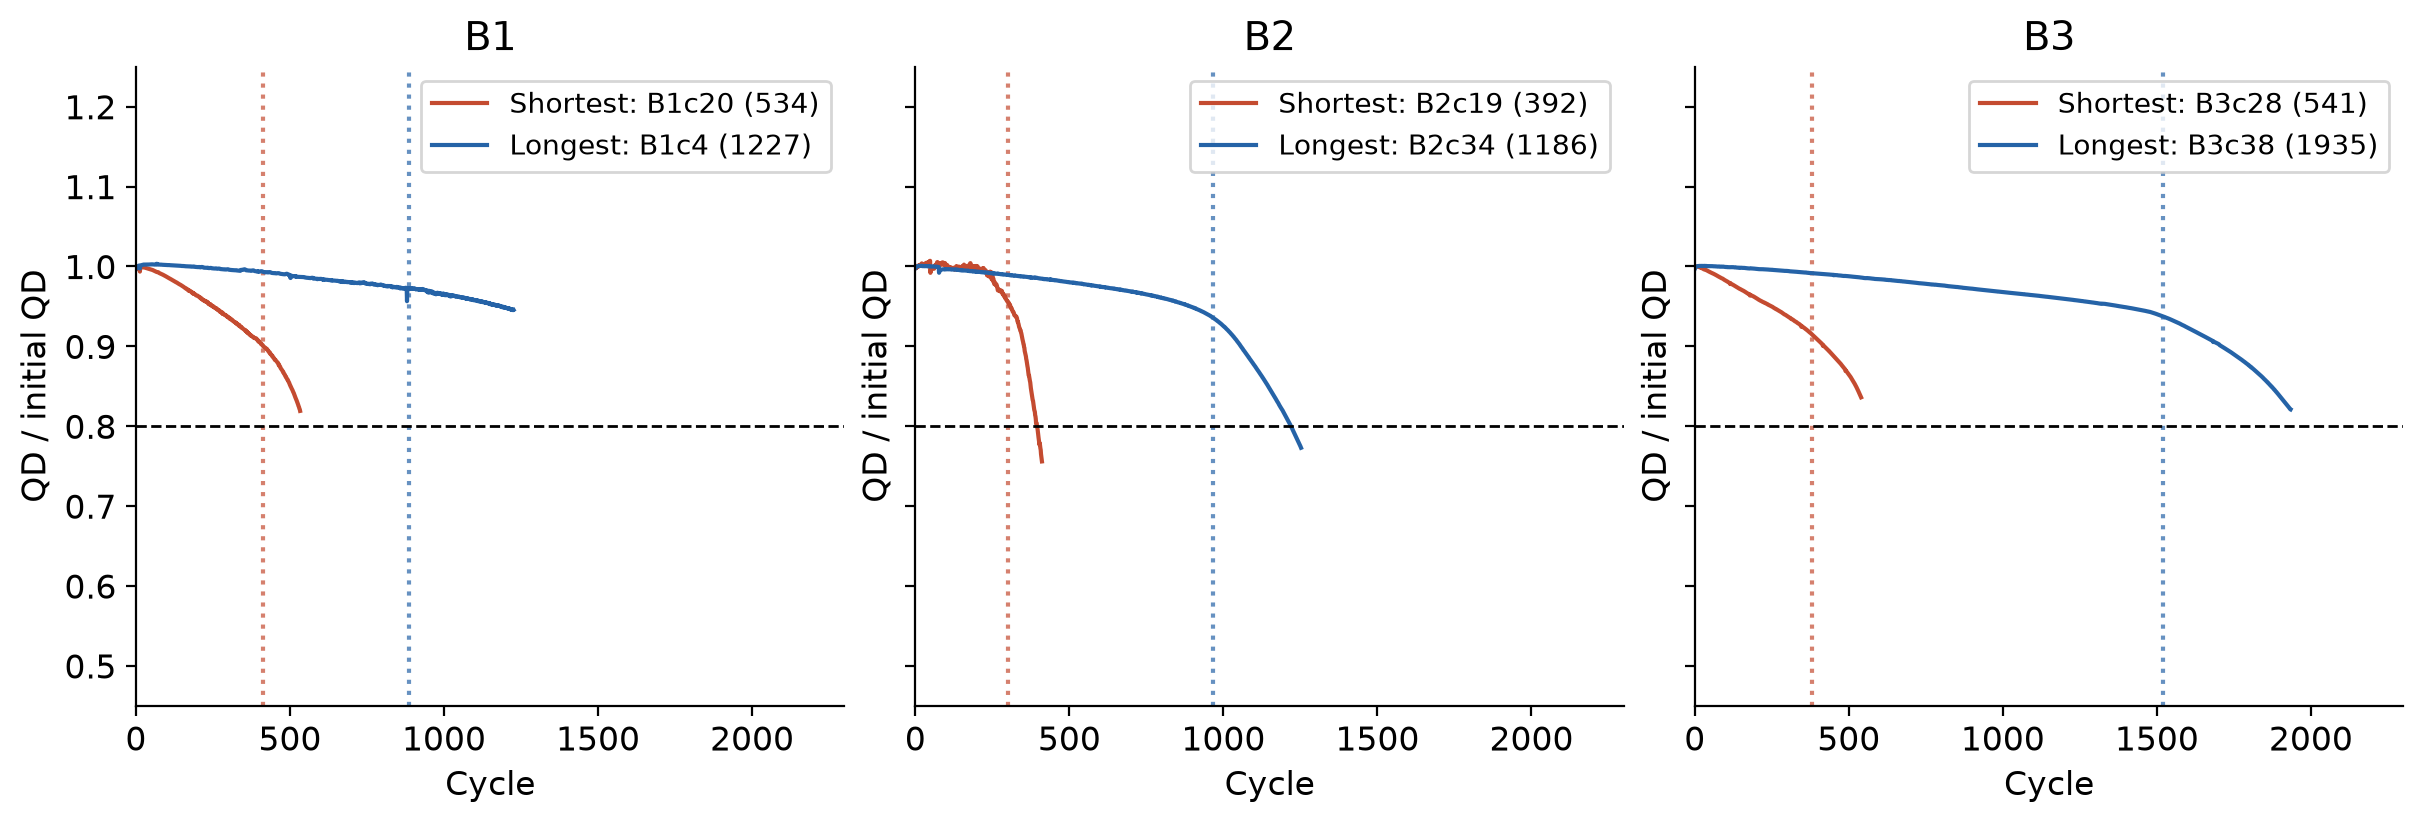

In [4]:
def slope(x,y):
    x=np.asarray(x);y=np.asarray(y);m=np.isfinite(x)&np.isfinite(y)
    return float(np.polyfit(x[m],y[m],1)[0]) if m.sum()>=3 and np.ptp(x[m])>0 else np.nan

def knee_candidate(s, qref, bad):
    d=s.loc[~bad,['cycle','QD']].copy()
    if len(d)<100: return {'knee_cycle':np.nan,'sse_gain':np.nan,'early_slope':np.nan,'late_slope':np.nan}
    d['y']=d.QD.rolling(11,center=True,min_periods=5).median()/qref
    d=d.dropna().iloc[::5]
    x=d.cycle.to_numpy();y=d.y.to_numpy();xc=x-x[0]
    A=np.column_stack([np.ones(len(x)),xc]);coef=np.linalg.lstsq(A,y,rcond=None)[0]
    sse0=np.sum((y-A@coef)**2);best=None
    for j in range(max(10,int(.15*len(x))),min(len(x)-10,int(.85*len(x))),3):
        knot=xc[j];M=np.column_stack([np.ones(len(x)),xc,np.maximum(0,xc-knot)])
        c=np.linalg.lstsq(M,y,rcond=None)[0];sse=np.sum((y-M@c)**2)
        if best is None or sse<best[0]:best=(sse,x[j],c[1],c[1]+c[2])
    if best is None:return {'knee_cycle':np.nan,'sse_gain':np.nan,'early_slope':np.nan,'late_slope':np.nan}
    gain=1-best[0]/sse0 if sse0>0 else 0
    accepted=gain>=.25 and best[3]<0 and abs(best[3])>=1.5*abs(best[2])
    return {'knee_cycle':best[1] if accepted else np.nan,'sse_gain':gain,
            'early_slope':best[2],'late_slope':best[3]}
knees=[]
for r in usable.itertuples():
    d=raw_cells[r.cell_id]
    knees.append({'cell_id':r.cell_id,'batch':r.batch,**knee_candidate(d['summary'],r.qref,d['bad_q'])})
knee_df=pd.DataFrame(knees)
knee_summary=knee_df.groupby('batch').agg(n=('cell_id','size'),knee_candidates=('knee_cycle','count'),
    median_knee=('knee_cycle','median'),median_sse_gain=('sse_gain','median')).reset_index()
fig,axs=plt.subplots(2,3,figsize=(12,7.3),sharex=True,sharey='row',layout='constrained')
norm=colors.Normalize(usable.cycle_life.min(),usable.cycle_life.max());cmap=plt.get_cmap('viridis')
for k,bid in enumerate(FILES):
    d=usable[usable.batch==bid]
    for r in d.itertuples():
        raw=raw_cells[r.cell_id];s=raw['summary'];q=s.QD.mask(raw['bad_q'])
        col=cmap(norm(r.cycle_life))
        axs[0,k].plot(s.cycle,q,color=col,alpha=.65,lw=.7)
        axs[1,k].plot(s.cycle,q/r.qref,color=col,alpha=.65,lw=.7)
    axs[0,k].set(title=f'{bid}: n={len(d)}',ylabel='QD (Ah)',ylim=(0,1.45))
    axs[1,k].axhline(.8,color='black',ls='--',lw=1,label='80% of initial QD')
    axs[1,k].set(xlabel='Cycle',ylabel='QD / initial QD',ylim=(.45,1.25),xlim=(0,2300))
    axs[1,k].legend(fontsize=10)
fig.colorbar(plt.cm.ScalarMappable(norm=norm,cmap=cmap),ax=axs,label='Cycle life (cycles)',shrink=.8)
img=fig_save(fig,'q2_capacity_degradation.png','上段は放電容量、下段は初期観測容量で正規化。色は実際のcycle_life。80%以下の末期区間も保持。'.replace('上段は放電容量、下段は初期観測容量で正規化。色は実際のcycle_life。80%以下の末期区間も保持。','상단: 방전 용량. 하단: 초기 기준으로 정규화. 색상은 실제 수명이며, 80% 아래 말기 구간도 유지한다.'))
endcheck=usable.groupby('batch').agg(n=('cell_id','size'),end_above_80=('last_q_ratio',lambda x:int((x>.8).sum())),
    median_end_ratio=('last_q_ratio','median'),median_initial_QD=('qref','median')).reset_index()
add('Q2 · 열화 속도는 일정한가?',img+table(knee_summary)+table(endcheck)+
    f'<p><b>수치 요약:</b> knee 후보는 B1 {int(knee_summary.set_index("batch").loc["B1","knee_candidates"])}/46, B2 39/39, B3 44/44에서 검출됐다. 후보 위치 중앙값은 각각 607, 356, 818.5사이클이다. 종료 용량 비율 중앙값은 B1 81.9%, B2 75.9%, B3 82.6%로, 동일한 관측 초기 기준 EOL로 해석할 수 없다.</p>'+ 
    '<p><b>관찰:</b> 곡선은 초기 용량 수준이 비슷해도 이후 경로와 종료 시점이 다르다. 정규화 곡선의 80% 도달 여부와 제공 라벨은 반드시 일치하지 않는다. 위 종료 비율은 마지막 5개 QD의 중앙값/초기 기준이다.</p>'+
    '<p><b>방법:</b> 비정상 QD를 제외하고 11점 이동 중앙값, 5사이클 간격으로 완화한다. 기록의 15–85% 구간에서 연속 2구간 직선의 SSE를 최소화한다. 단일 직선보다 SSE가 25% 이상 감소하고 후기 기울기가 음수이며 절댓값이 초기의 1.5배 이상일 때 knee 후보로 표시한다. 임계값은 탐색용이며 물리적인 확정 시점이 아니다.</p>'+
    '<p><b>전략:</b> 예측 입력은 10–100사이클의 QD 기울기·변동성을 후보로 삼는다. 전체 기록의 knee, 종료 비율, 전체 기록 길이는 미래 정보여서 입력에서 제외한다. 라벨의 명목용량 기준 및 Batch 1 미완주 가능성을 먼저 확인한다.</p>')
fig,axs=plt.subplots(1,3,figsize=(12,4),layout='constrained',sharey=True)
representatives=[]
for k,bid in enumerate(FILES):
    d=usable[usable.batch==bid]
    for idx,label,col in [(d.cycle_life.idxmin(),'Shortest','#c44b30'),(d.cycle_life.idxmax(),'Longest','#2563a7')]:
        r=d.loc[idx];raw=raw_cells[r.cell_id];s=raw['summary'];q=s.QD.mask(raw['bad_q'])
        axs[k].plot(s.cycle,q/r.qref,label=f'{label}: {r.cell_id} ({r.cycle_life:.0f})',color=col)
        kn=knee_df.set_index('cell_id').loc[r.cell_id,'knee_cycle']
        if np.isfinite(kn):axs[k].axvline(kn,color=col,ls=':',alpha=.7)
        representatives.append(r.cell_id)
    axs[k].axhline(.8,color='black',ls='--',lw=1)
    axs[k].set(title=bid,xlabel='Cycle',ylabel='QD / initial QD',ylim=(.45,1.25),xlim=(0,2300));axs[k].legend(fontsize=10)
img=fig_save(fig,'q2_representative_knees.png','배치별 최소·최대 수명 셀의 정규화 용량. 점선 수직선은 방법에 의해 검출된 knee 후보이며 수명 그룹 전체를 대표하는 통계는 아니다.')
add('Q2 보충 · 대표 셀과 변화점의 한계',img+'<p>극단 셀의 종료 상태와 곡선을 대조했다. Batch 1의 긴 수명 셀은 관측 종료에도 80% 위에 남을 수 있어 장수명을 온전히 관측했는지 검증이 필요하다. 측정값만으로 짧은 수명의 물리적 원인을 확정할 수 없다. 점선은 탐색 알고리즘이 선택한 후보이며 단일 knee 정의나 실사용 임계값을 주장하지 않는다.</p>')
knee_df.to_csv(OUTPUT_DIR/'knee_candidates.csv',index=False)

## 3. ΔQ(V) = Q₁₀₀(V) − Q₁₀(V)

실제 Vdlin에 맞춰 비교하고, raw 방전 I·V·Qd에서 독립적으로 재보간한 결과를 점검한다.
공통 2.1–3.4V에서 외삽 없이 비교한다. 시작 용량 오프셋 민감도는 높은 전압점 기준 정렬로 점검한다.

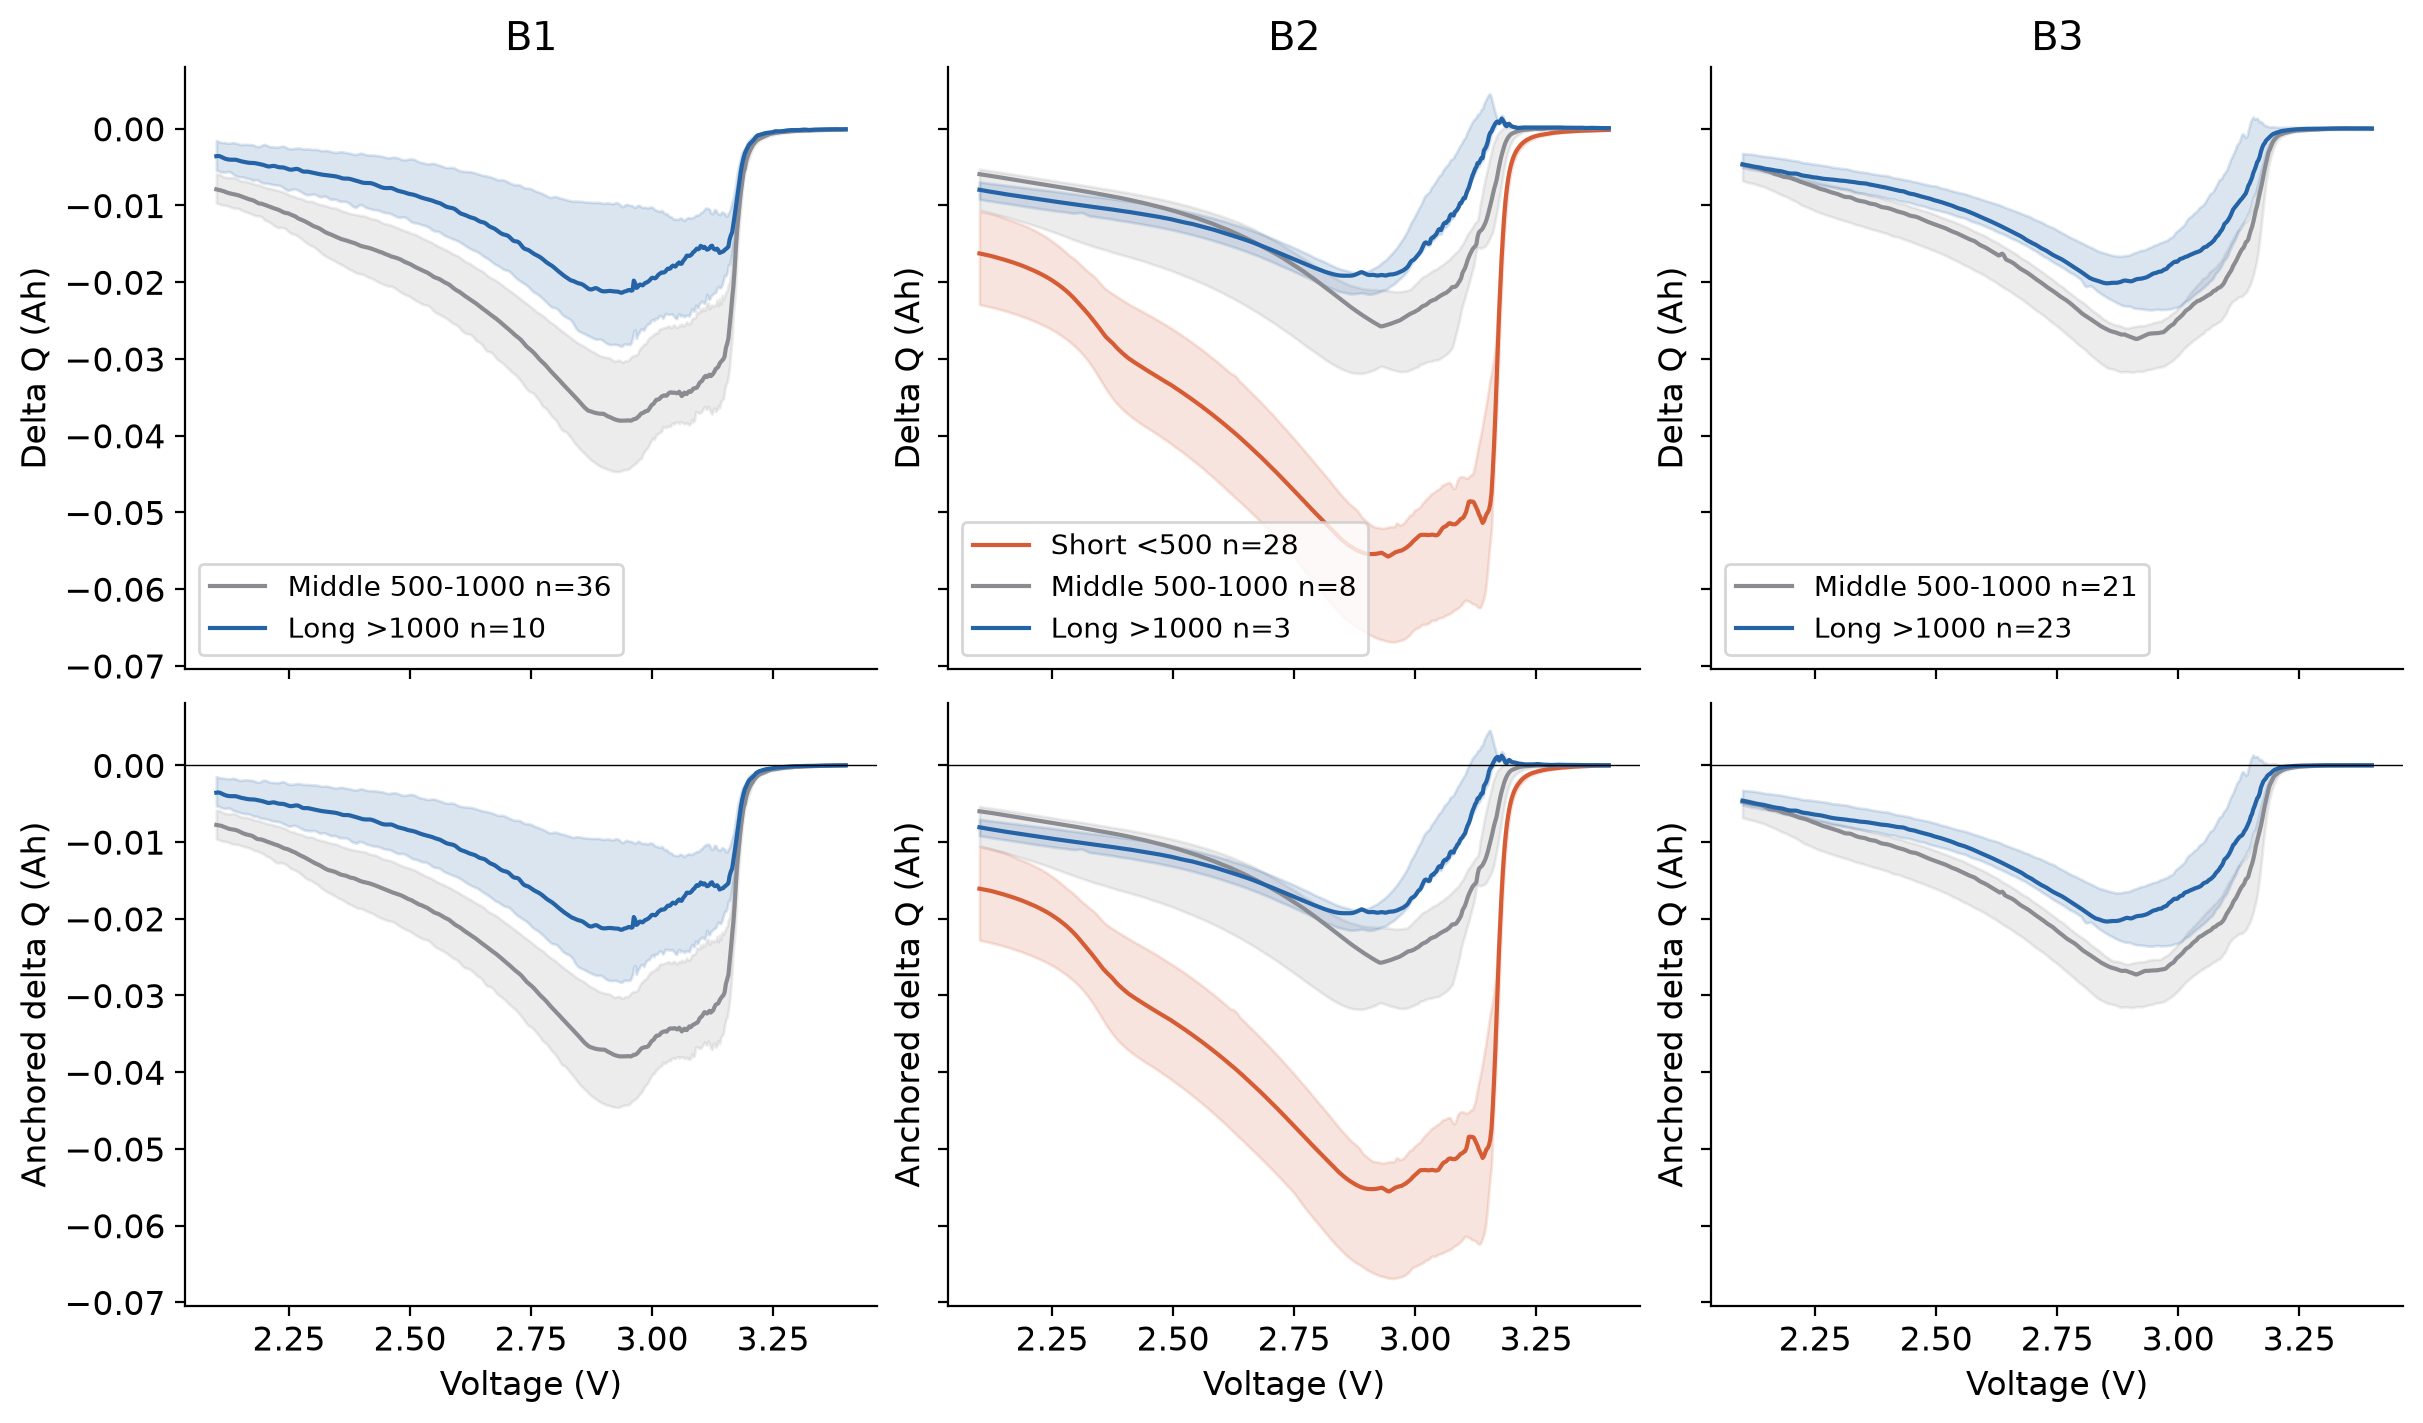


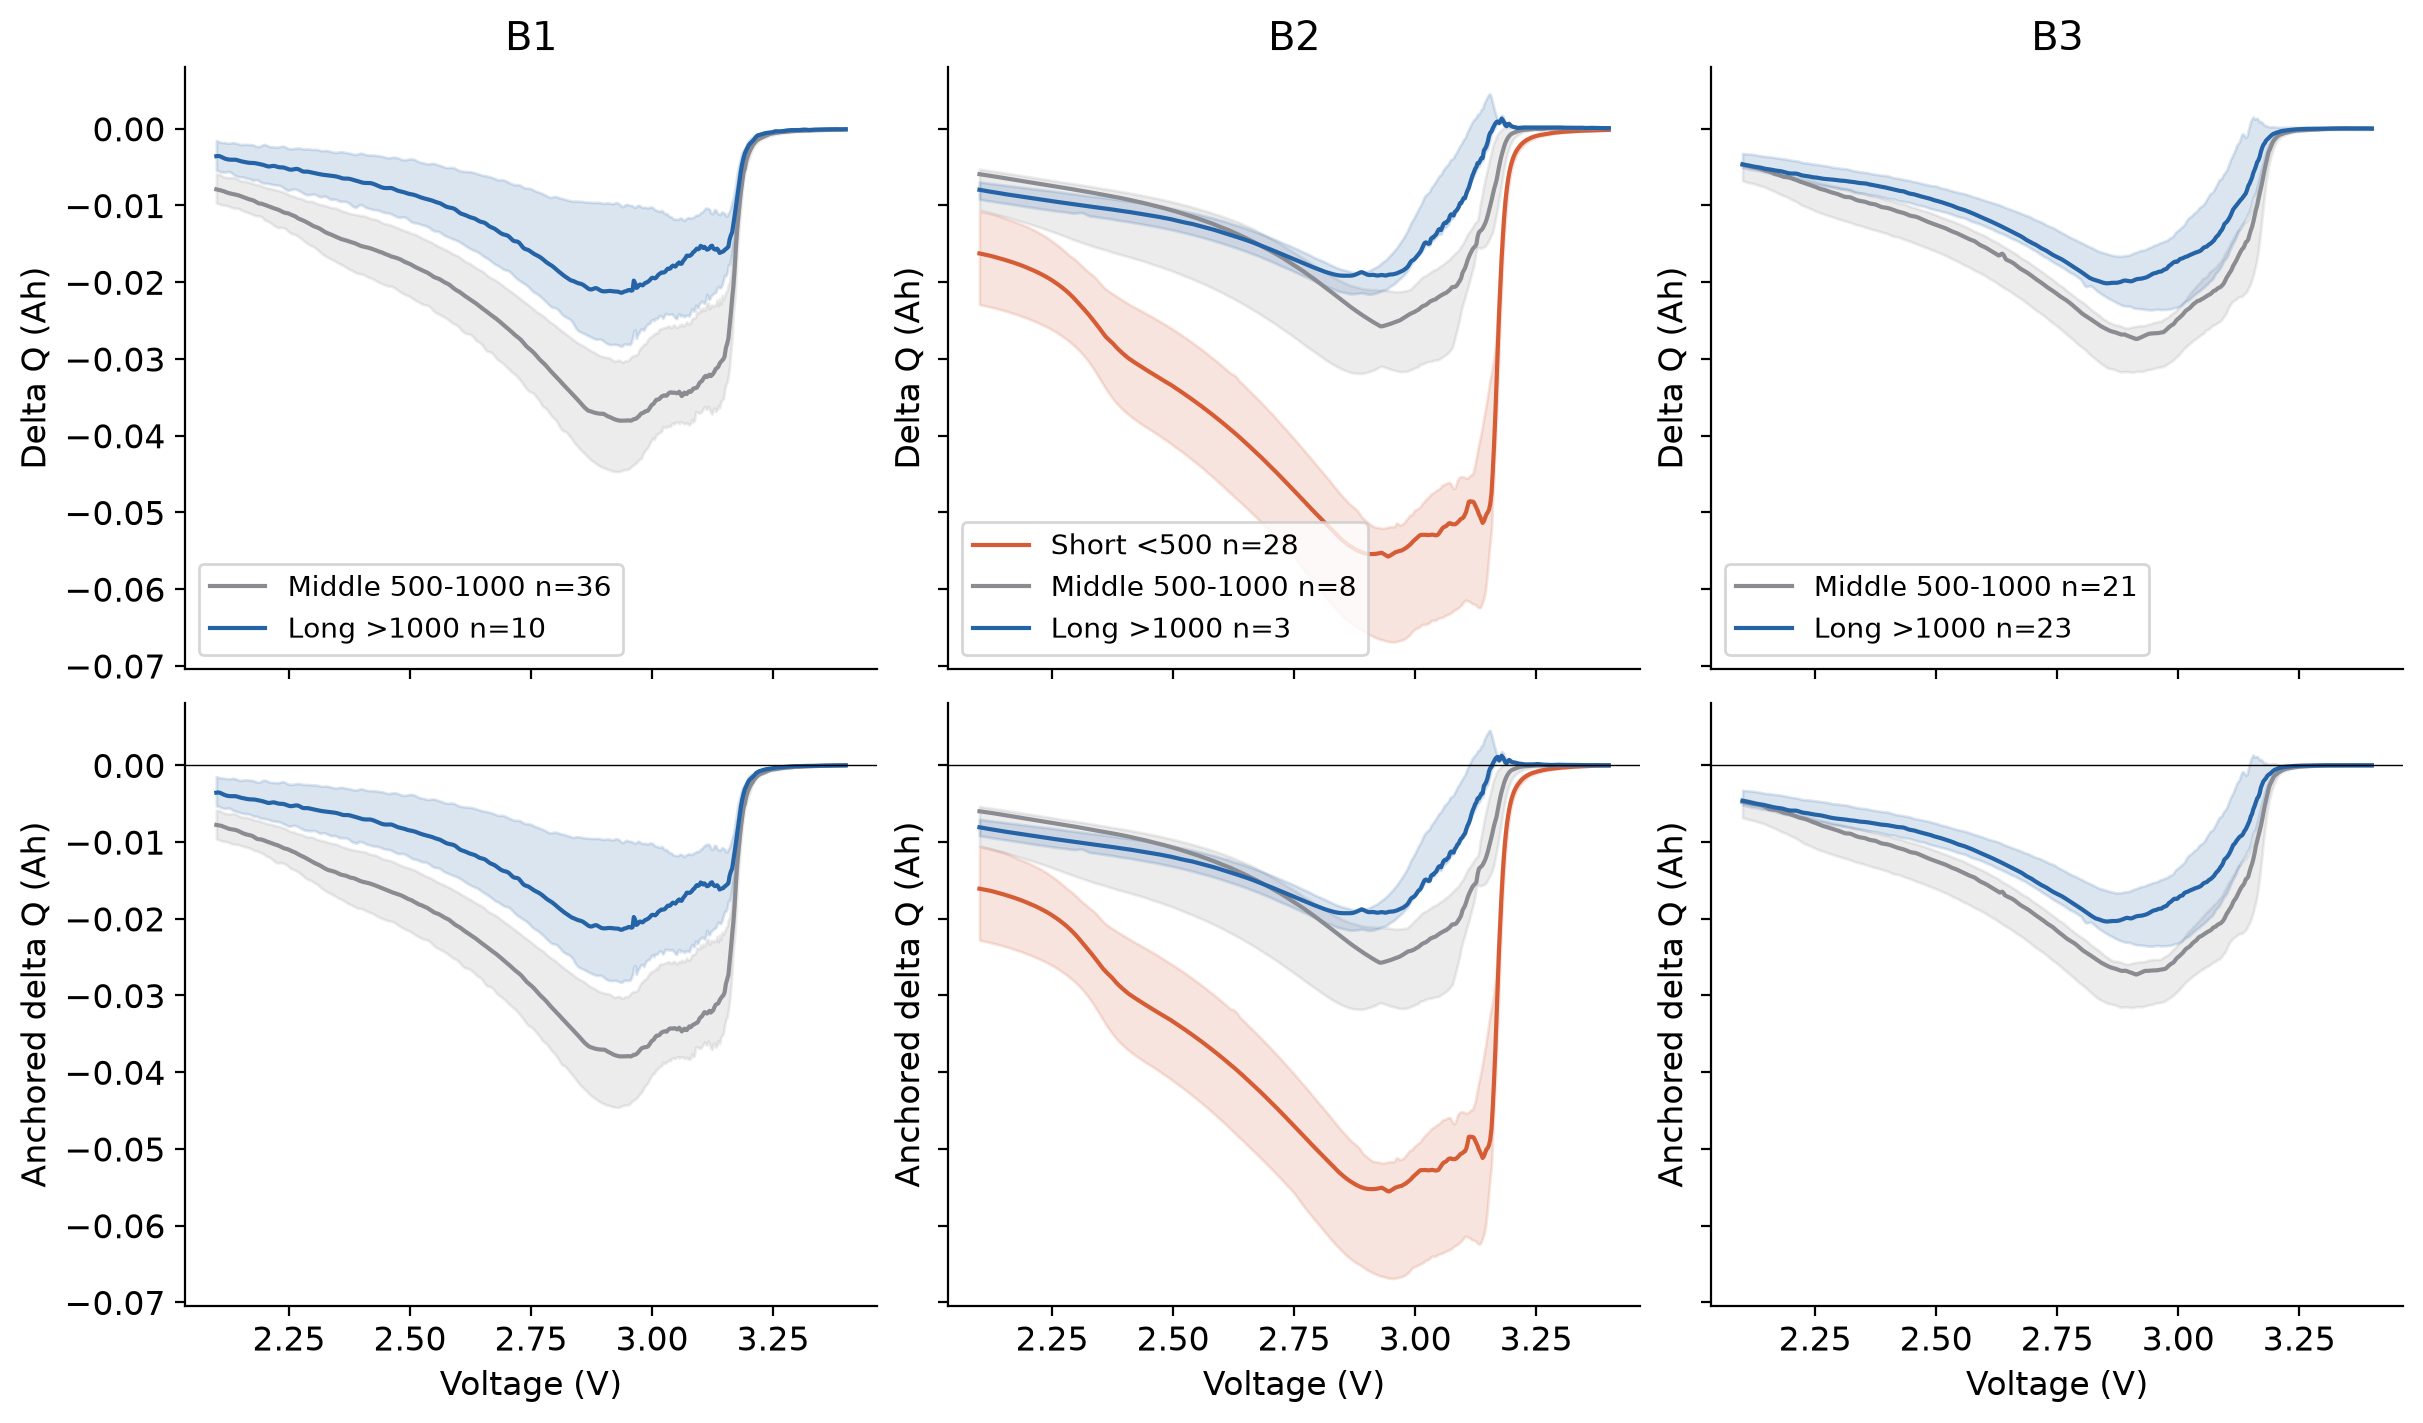

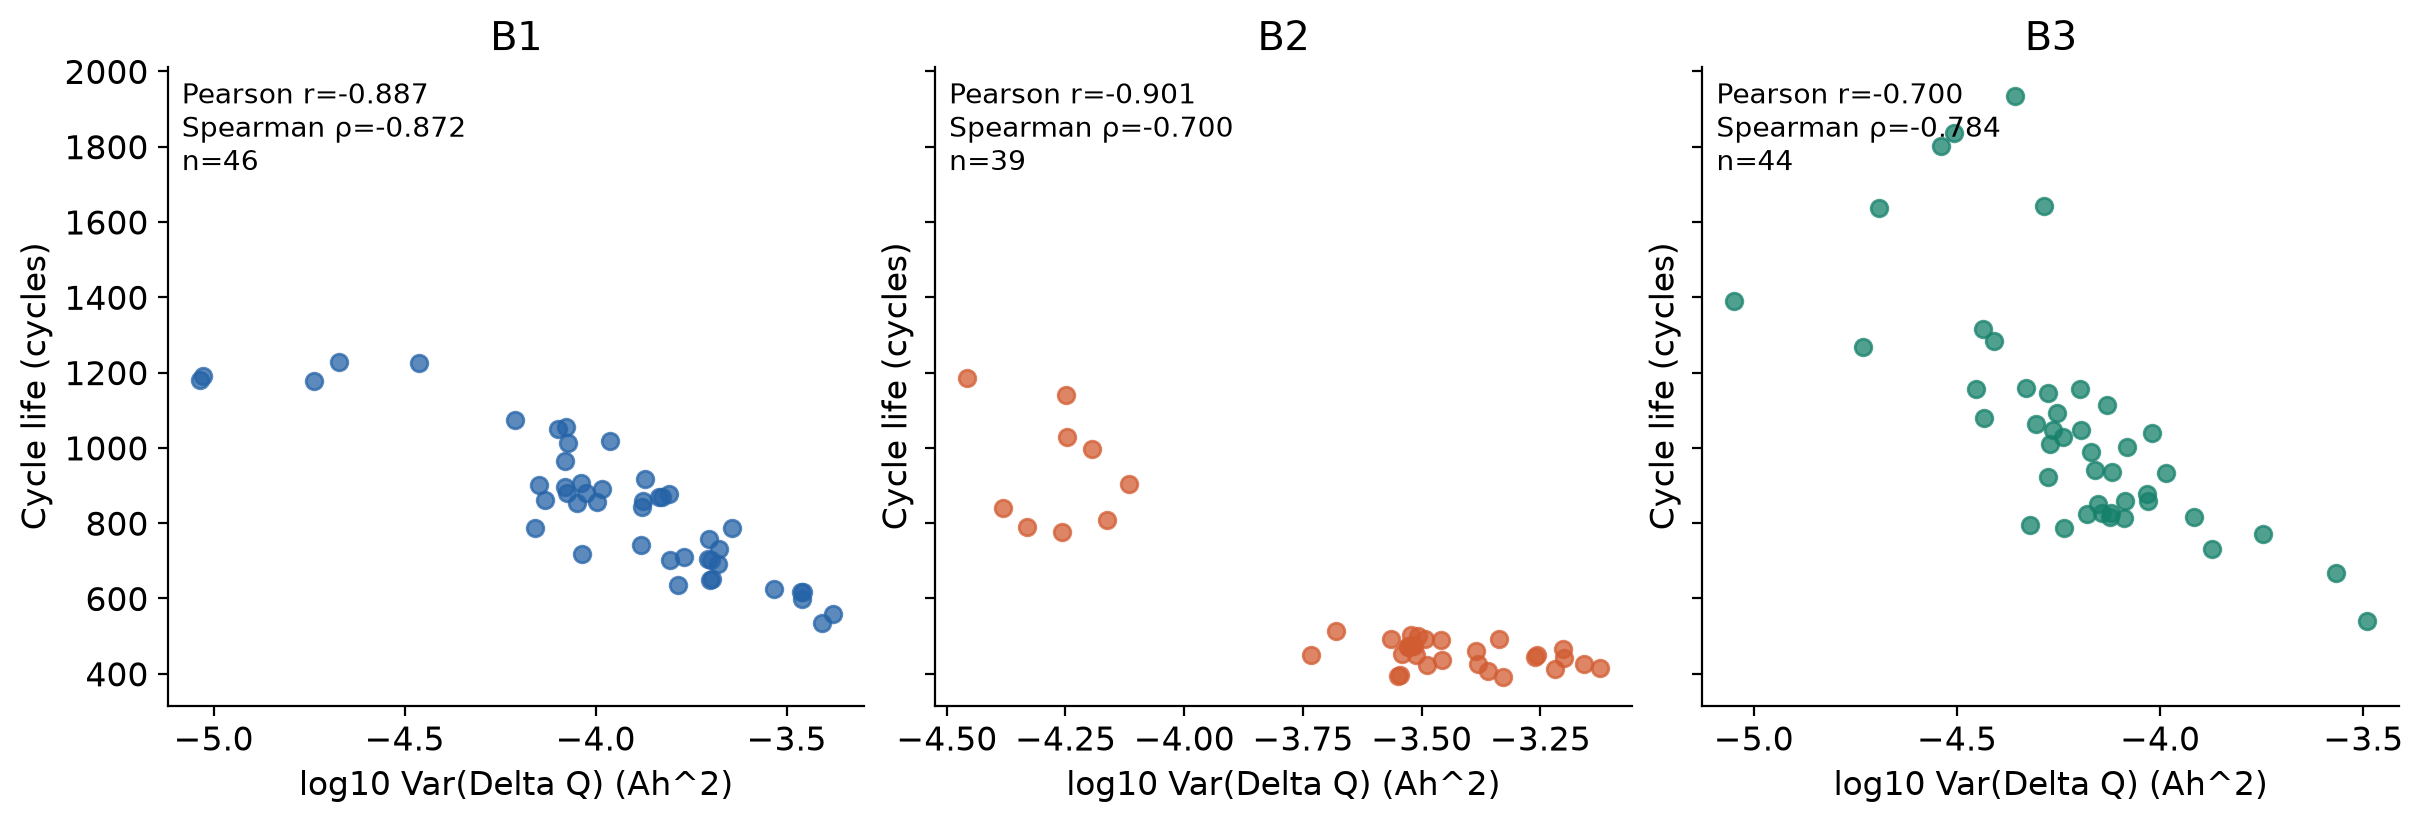


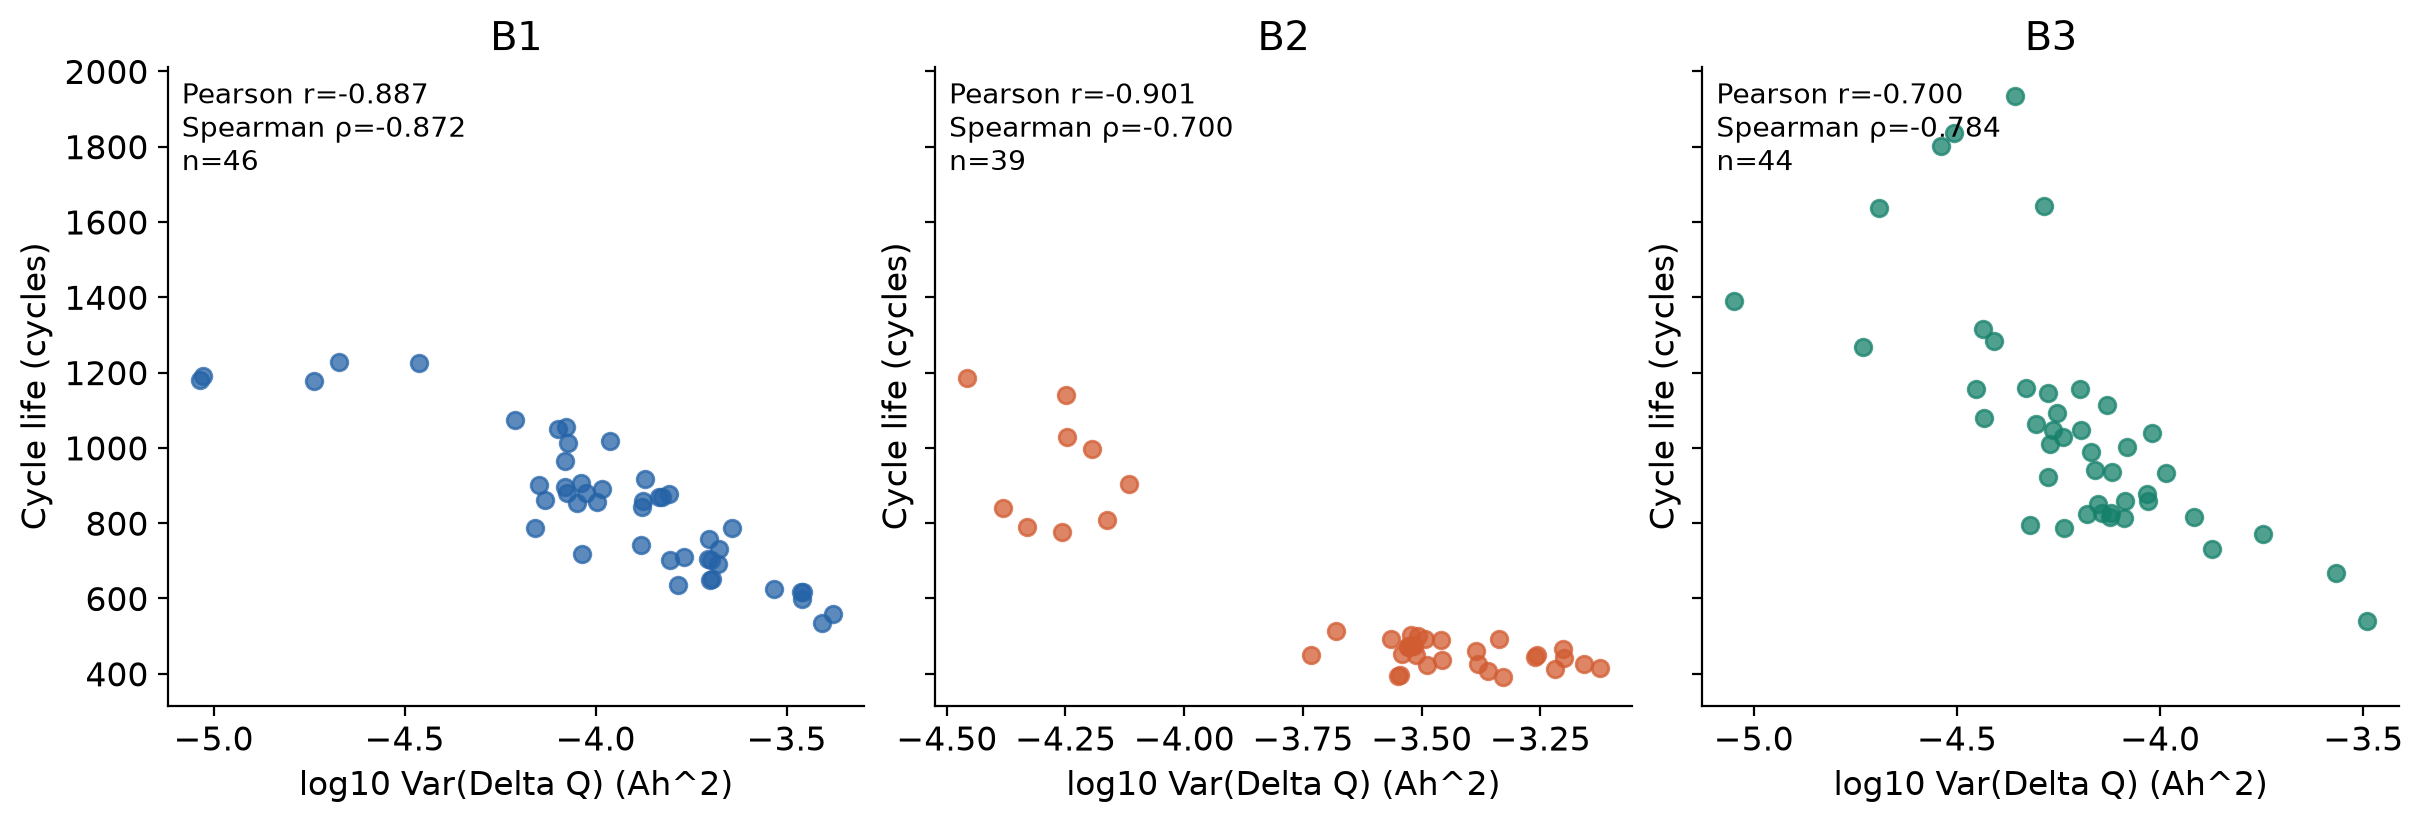

In [5]:
features=[];deltas={};alignment=[]
for r in usable.itertuples():
    raw=raw_cells[r.cell_id];s=raw['summary'].copy()
    s.loc[raw['bad_q'],'QD']=np.nan
    early=s[s.cycle.between(2,100)];s10=s[s.cycle.between(2,10)]
    rec={'cell_id':r.cell_id,'batch':r.batch,'cycle_life':r.cycle_life,'policy':r.policy,
         'C1':r.C1,'switch_SOC':r.switch_SOC,'C2':r.C2,'new_structure':r.new_structure,
         'initial_QD':r.qref,'mean_QD':early.QD.mean(),'std_QD':early.QD.std(),
         'QD_slope_10_100':slope(early.loc[early.cycle>=10,'cycle'],early.loc[early.cycle>=10,'QD']),
         'mean_IR':early.loc[early.IR>0,'IR'].mean(),
         'IR_change':s.loc[s.cycle.between(91,100)&(s.IR>0),'IR'].median()-s10.loc[s10.IR>0,'IR'].median(),
         'mean_Tavg':early.Tavg.mean(),'mean_Tmax':early.Tmax.mean(),
         'mean_chargetime':early.loc[early.chargetime>0,'chargetime'].mean()}
    raw10=raw['raw'].get(10)
    if raw10 is not None:
        pos=raw10['I'][np.isfinite(raw10['I'])&(raw10['I']>.1)]
        rec['I10_charge_median']=np.median(pos) if len(pos) else np.nan
    if 10 in raw['qcurves'] and 100 in raw['qcurves']:
        v=raw['v'];q10=raw['qcurves'][10];q100=raw['qcurves'][100]
        # 원본 배열을 실제 전압 오름차순으로 정렬하고 공통 범위에 보간한다.
        a=np.interp(GRID,v[::-1],q10[::-1]);b=np.interp(GRID,v[::-1],q100[::-1])
        delta=b-a;anchored=delta-delta[-1]
        var=float(np.var(delta,ddof=0))
        rec.update(delta_logvar=np.log10(var) if var>0 else np.nan,
                   delta_min=float(delta.min()),delta_mean=float(delta.mean()),
                   delta_range=float(np.ptp(delta)),delta_anchor_mean=float(anchored.mean()),
                   delta_full_logvar=np.log10(np.var(q100-q10)) if np.var(q100-q10)>0 else np.nan)
        deltas[r.cell_id]={'delta':delta,'anchor':anchored,'q10':a,'q100':b}
        raw_a=interp_discharge(raw['raw'].get(10,{}),GRID) if 10 in raw['raw'] else None
        raw_b=interp_discharge(raw['raw'].get(100,{}),GRID) if 100 in raw['raw'] else None
        if raw_a is not None and raw_b is not None:
            rd=raw_b-raw_a;rv=np.var(rd)
            rec['delta_raw_logvar']=np.log10(rv) if rv>0 else np.nan
            alignment.append({'cell_id':r.cell_id,'batch':r.batch,'offset_3_4V':delta[-1],
                              'raw_supported':True,'rmse_raw_vs_qdlin':np.sqrt(np.mean((rd-delta)**2))})
        else:
            alignment.append({'cell_id':r.cell_id,'batch':r.batch,'offset_3_4V':delta[-1],
                              'raw_supported':False,'rmse_raw_vs_qdlin':np.nan})
    features.append(rec)
feat=pd.DataFrame(features).replace([np.inf,-np.inf],np.nan)
align=pd.DataFrame(alignment)
align_summary=align.groupby('batch').agg(n=('cell_id','size'),raw_supported=('raw_supported','sum'),
    median_offset_3_4V=('offset_3_4V','median'),median_raw_rmse=('rmse_raw_vs_qdlin','median')).reset_index()
fig,axs=plt.subplots(2,3,figsize=(12,7),layout='constrained',sharex=True,sharey='row')
groupcols={'Short <500':'#d55c35','Middle 500-1000':'#8a8c91','Long >1000':'#2563a7'}
for k,bid in enumerate(FILES):
    d=usable[usable.batch==bid]
    for label,mask in [('Short <500',d.cycle_life<500),('Middle 500-1000',d.cycle_life.between(500,1000)),('Long >1000',d.cycle_life>1000)]:
        ids=[cid for cid in d.loc[mask,'cell_id'] if cid in deltas]
        if not ids:continue
        for row,key in enumerate(['delta','anchor']):
            a=np.array([deltas[cid][key] for cid in ids])
            med=np.median(a,axis=0);lo,hi=np.quantile(a,[.25,.75],axis=0)
            axs[row,k].plot(GRID,med,color=groupcols[label],label=f'{label} n={len(ids)}')
            axs[row,k].fill_between(GRID,lo,hi,color=groupcols[label],alpha=.16)
    axs[0,k].set(title=bid,ylabel='Delta Q (Ah)')
    axs[1,k].set(xlabel='Voltage (V)',ylabel='Anchored delta Q (Ah)')
    axs[0,k].legend(fontsize=10);axs[1,k].axhline(0,color='black',lw=.5)
img=fig_save(fig,'q3_delta_q_curves.png','그룹별 ΔQ 중앙값과 사분위 범위. 상단은 원본 Qdlin을 공통 전압에 보간, 하단은 3.4V의 용량 차이를 제거한 민감도 점검. B1·B3에는 <500 셀이 없다.')
relations=pd.DataFrame([{'batch':b,'signal':'log10 Var ΔQ', 'relationship':r_text(d,'delta_logvar')}
                        for b,d in feat.groupby('batch')])
add('Q3 · 초기 곡선의 작은 차이를 수명 신호로 쓸 수 있는가?',img+table(relations)+table(align_summary)+
    f'<p><b>수치 요약:</b> ΔQ 로그 분산의 수명 Pearson r은 B1 −0.887, B2 −0.901, B3 −0.700이다. B1에서 원본 보간값과 raw 재보간값의 수명 관계가 비슷하지만, B2 일부 셀의 raw Qd에는 저전압 방전 중 0으로 떨어지는 표본이 있어 재보간을 왜곡한다. 아래는 RMSE가 큰 셀의 점검 기록이다.</p>'+
    table(align.nlargest(6,'rmse_raw_vs_qdlin').merge(meta[['cell_id','raw_low_voltage_zero_Qd']],on='cell_id'))+
    '<p><b>관찰:</b> 초기 100–10사이클 ΔQ 형태와 통계량을 확인했다. 수명 그룹이 없는 배치는 해당 비교를 생략했고, 중간 그룹을 단수명으로 이름 바꾸지 않았다. 색별 띠는 표본의 IQR이며 신뢰구간이 아니다.</p>'+
    '<p><b>정렬 검증:</b> 모든 Vdlin 축은 동일하다. 하지만 동일 축이 동일 용량 원점·측정 절차를 뜻하지는 않는다. 공통 2.1–3.4V에서 raw 방전 구간(I&lt;−0.1A)을 재보간해 Qdlin ΔQ와 RMSE를 비교했다. raw가 해당 구간 전체를 덮지 못하는 셀은 외삽하지 않았다. 원점 정렬은 3.4V에서 ΔQ를 빼는 민감도 비교이며 모든 구조 차이를 해결했다고 주장하지 않는다. raw 비교의 중앙 RMSE만으로 모든 셀이 정합하다고 결론 내리지 않는다. B2c41–46의 큰 RMSE와 0값 문제를 기록했으며 raw 재보간 피처는 품질 진단용으로만 사용한다.</p>'+
    '<p><b>피처:</b> log10(var(ΔQ)), 최소값, 평균, 범위를 검토한다. 분산은 공통 500점의 모집단 분산(ddof=0), 단위 Ah²이며 0 또는 비유한값은 NaN으로 처리한다. 상수 원점 이동은 분산을 바꾸지 않지만 평균·최솟값은 바꾼다. 분산 피처를 우선 후보로 두고 평균·최솟값은 중복 및 측정 정렬을 확인한 뒤 채택한다.</p>')
fig,axs=plt.subplots(1,3,figsize=(12,4),layout='constrained',sharey=True)
for k,bid in enumerate(FILES):
    d=feat[feat.batch==bid]
    axs[k].scatter(d.delta_logvar,d.cycle_life,color=BATCH_COLORS[bid],alpha=.75)
    axs[k].set(title=bid,xlabel='log10 Var(Delta Q) (Ah^2)',ylabel='Cycle life (cycles)')
    axs[k].text(.02,.98,r_text(d,'delta_logvar').replace(', ','\n'),transform=axs[k].transAxes,va='top',fontsize=10)
img=fig_save(fig,'q3_delta_feature_life.png','배치별 ΔQ 로그 분산과 수명 관계. 원본 셀당 한 점이며, 선형·순위 상관을 함께 표시한다.')
add('Q3 보충 · ΔQ 통계량과 수명 관계',img+'<p>관계의 크기는 배치별로 확인해야 한다. B1에서 raw와 Qdlin 로그 분산 r은 각각 −0.888·−0.887로 유사하지만, B2 raw 재보간은 저전압 0값 때문에 왜곡된다. 원본 전체 전압 구간, 공통 구간, raw 재보간 분산의 차이는 아래 상관관계 표에서 검토한다. 이 그림의 Batch 2·3 수명 상관을 기준으로 학습 피처를 최적화하지 않는다. DAY 2 선정은 Batch 1 학습 fold 안에서 재검증한다.</p>')
feat.to_csv(OUTPUT_DIR/'early_features.csv',index=False)
align.to_csv(OUTPUT_DIR/'voltage_alignment_audit.csv',index=False)

## 4. 충전 정책·전류와 수명

정책 문자열의 C1 / 전환 SOC / C2와 `newstructure` 표기를 구분한다.
오차막대는 표준편차이며 작은 표본에서 인과관계나 확정적 순위를 주장하지 않는다.

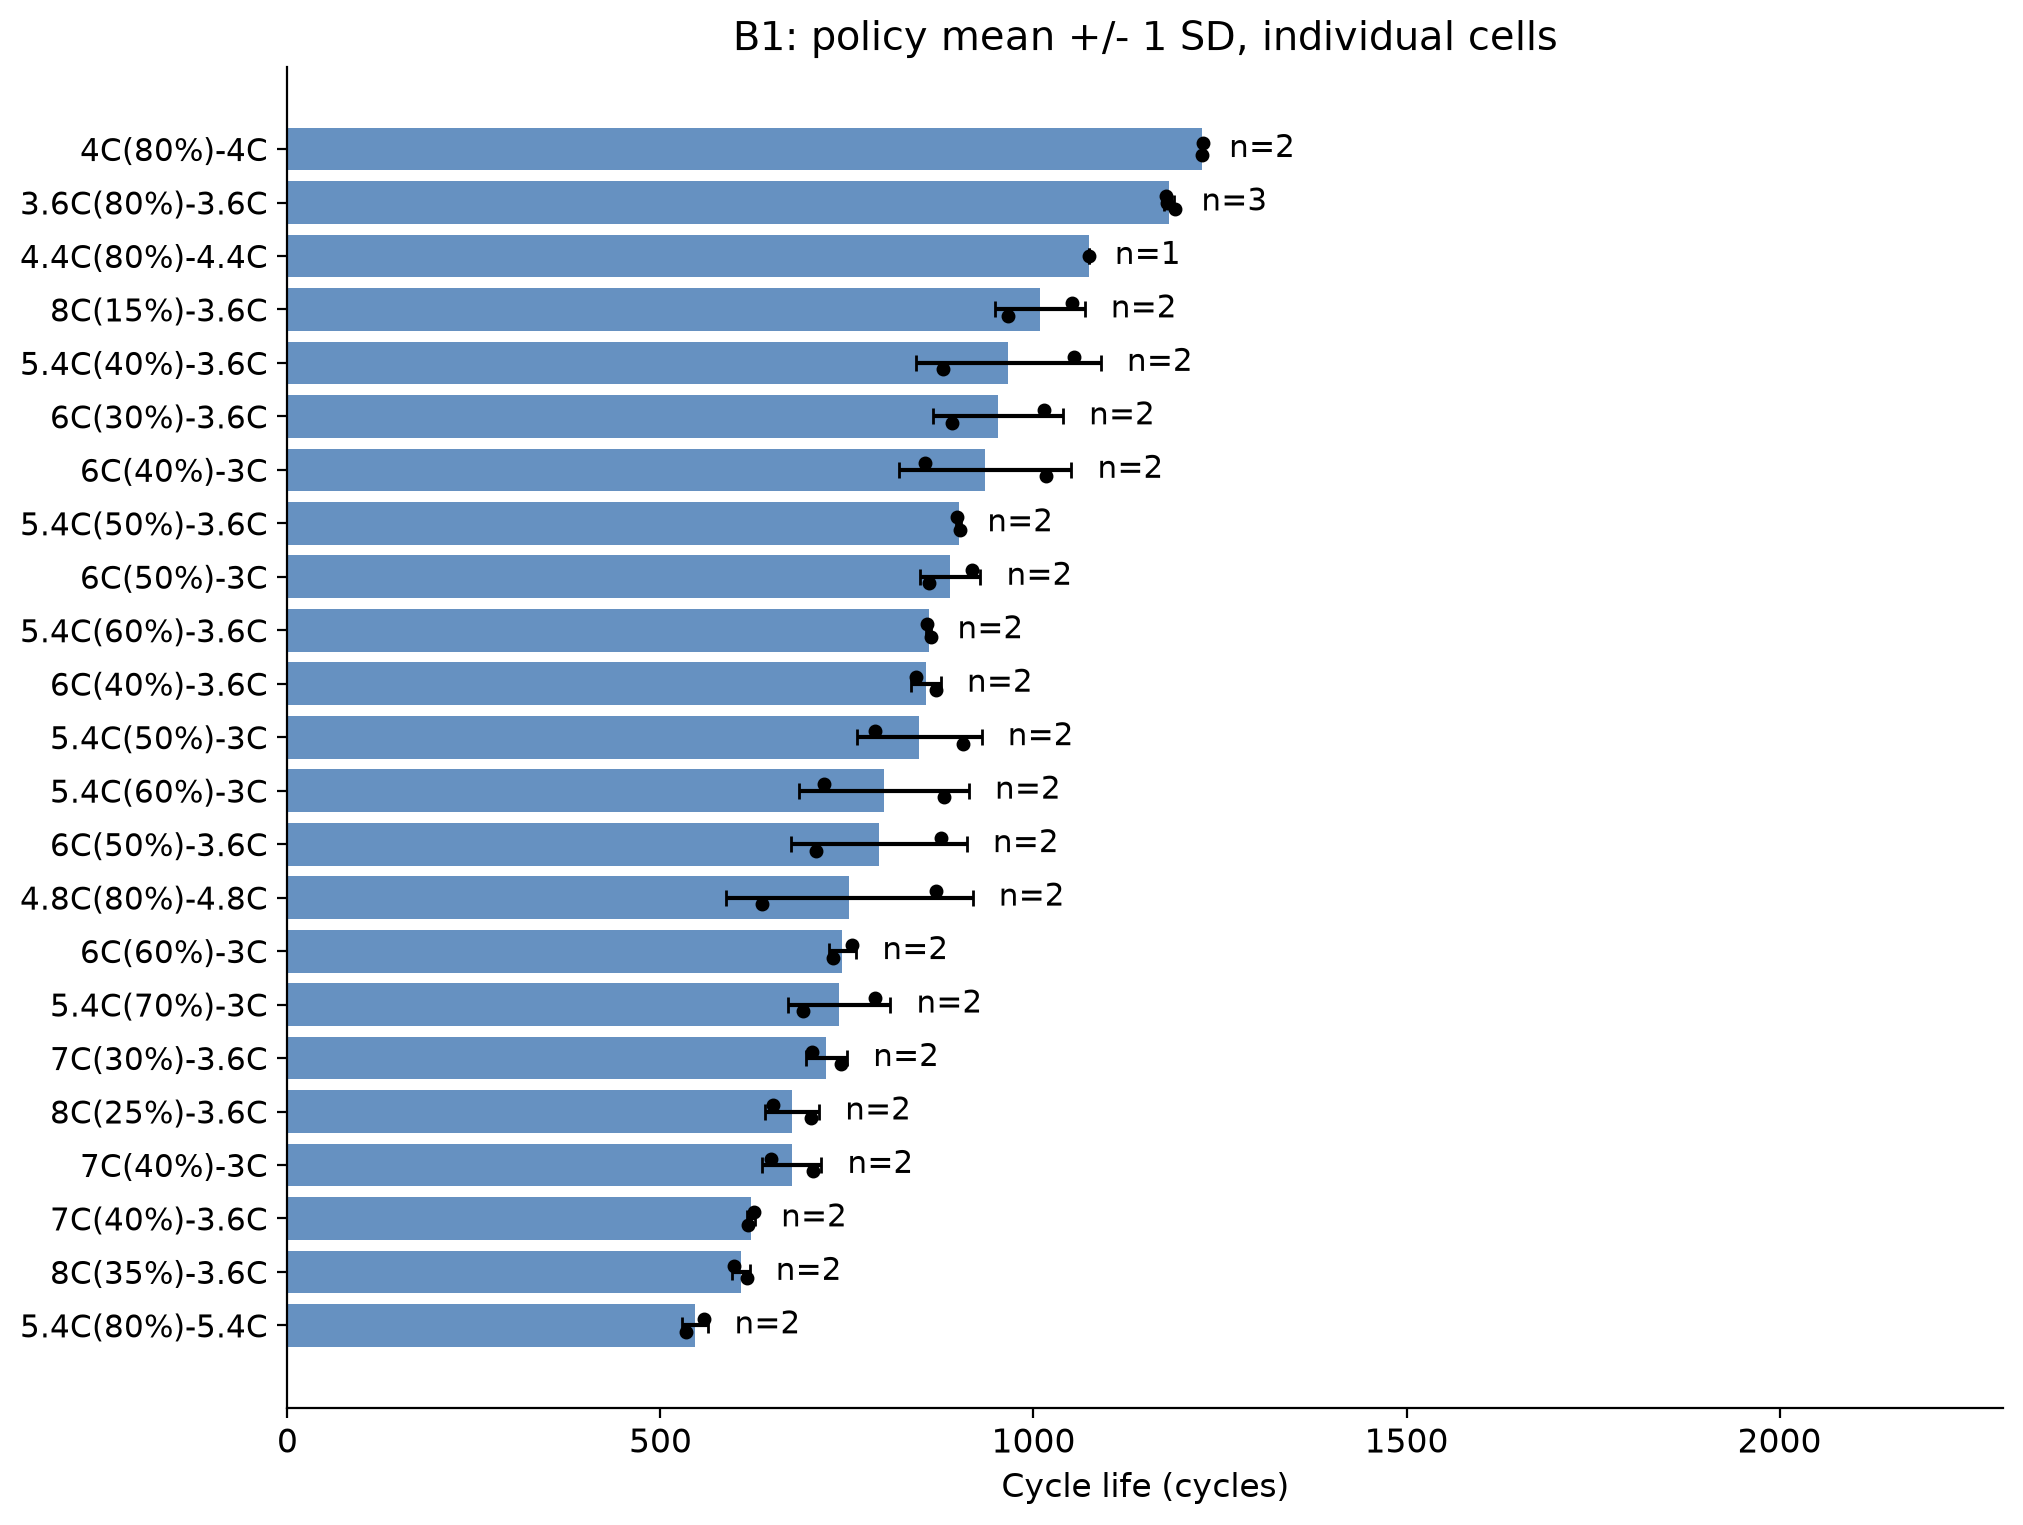

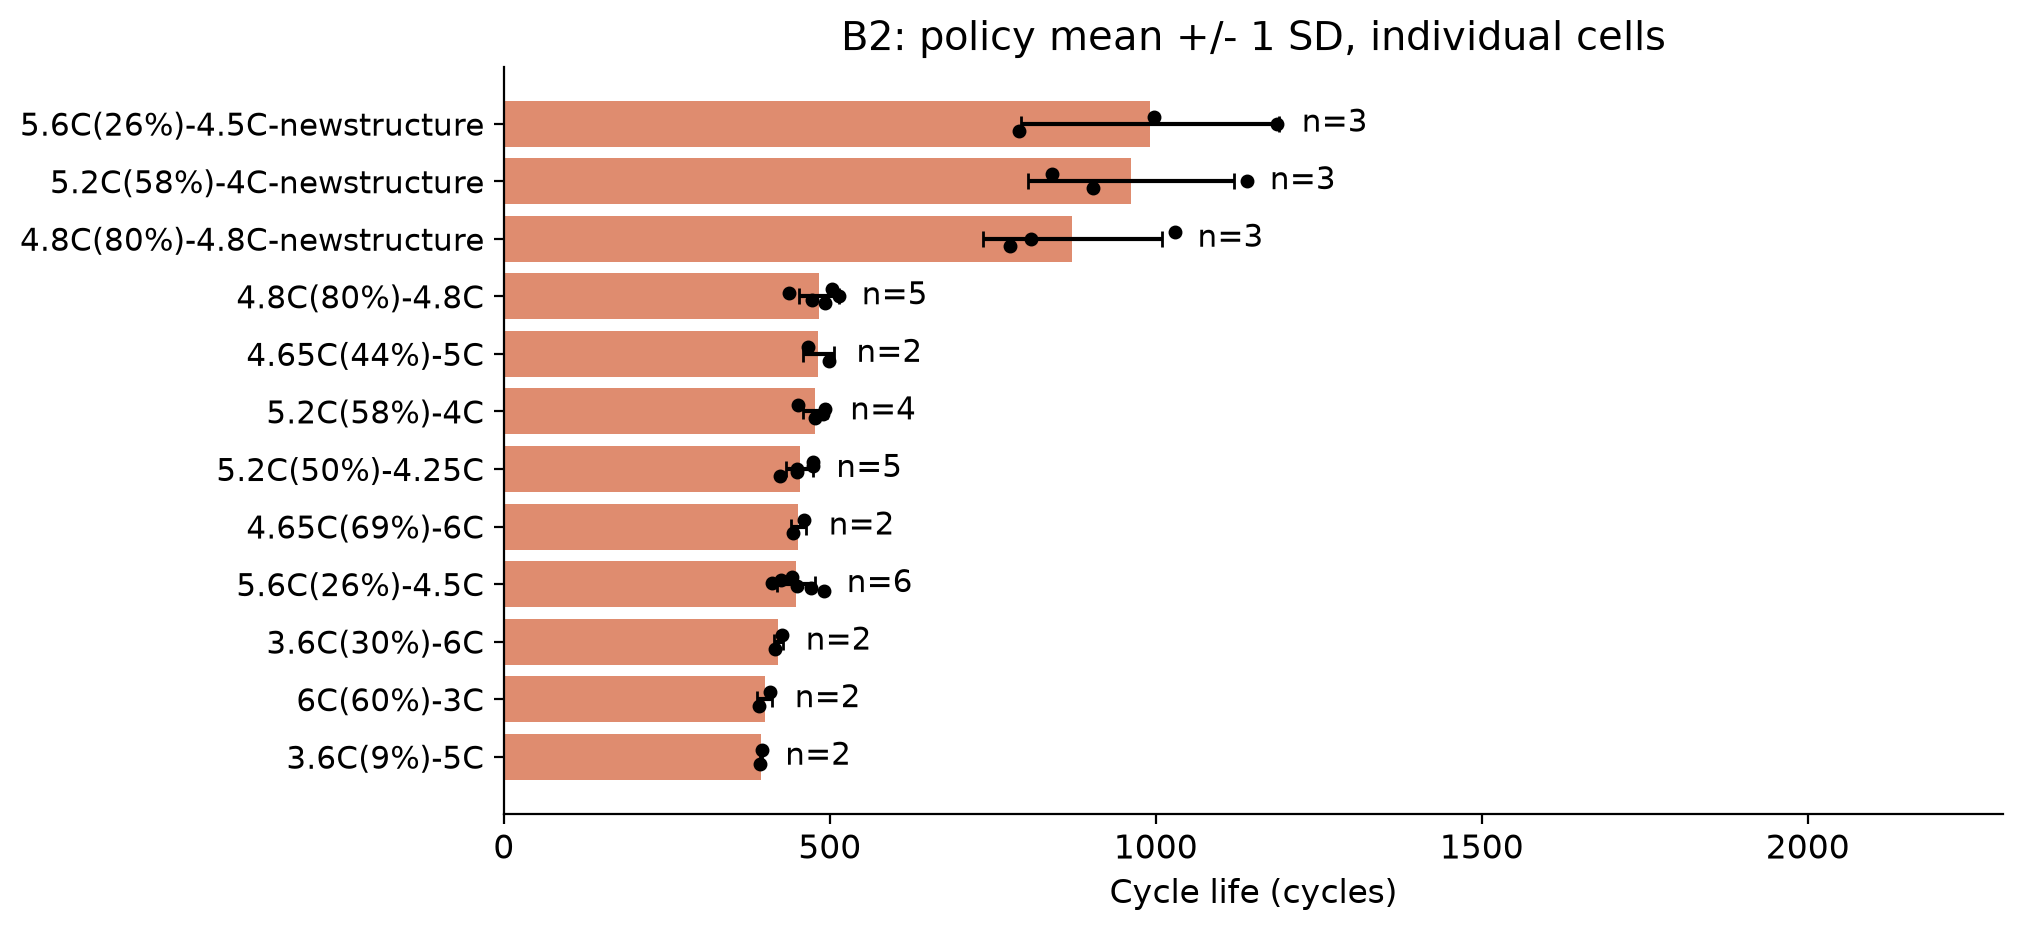

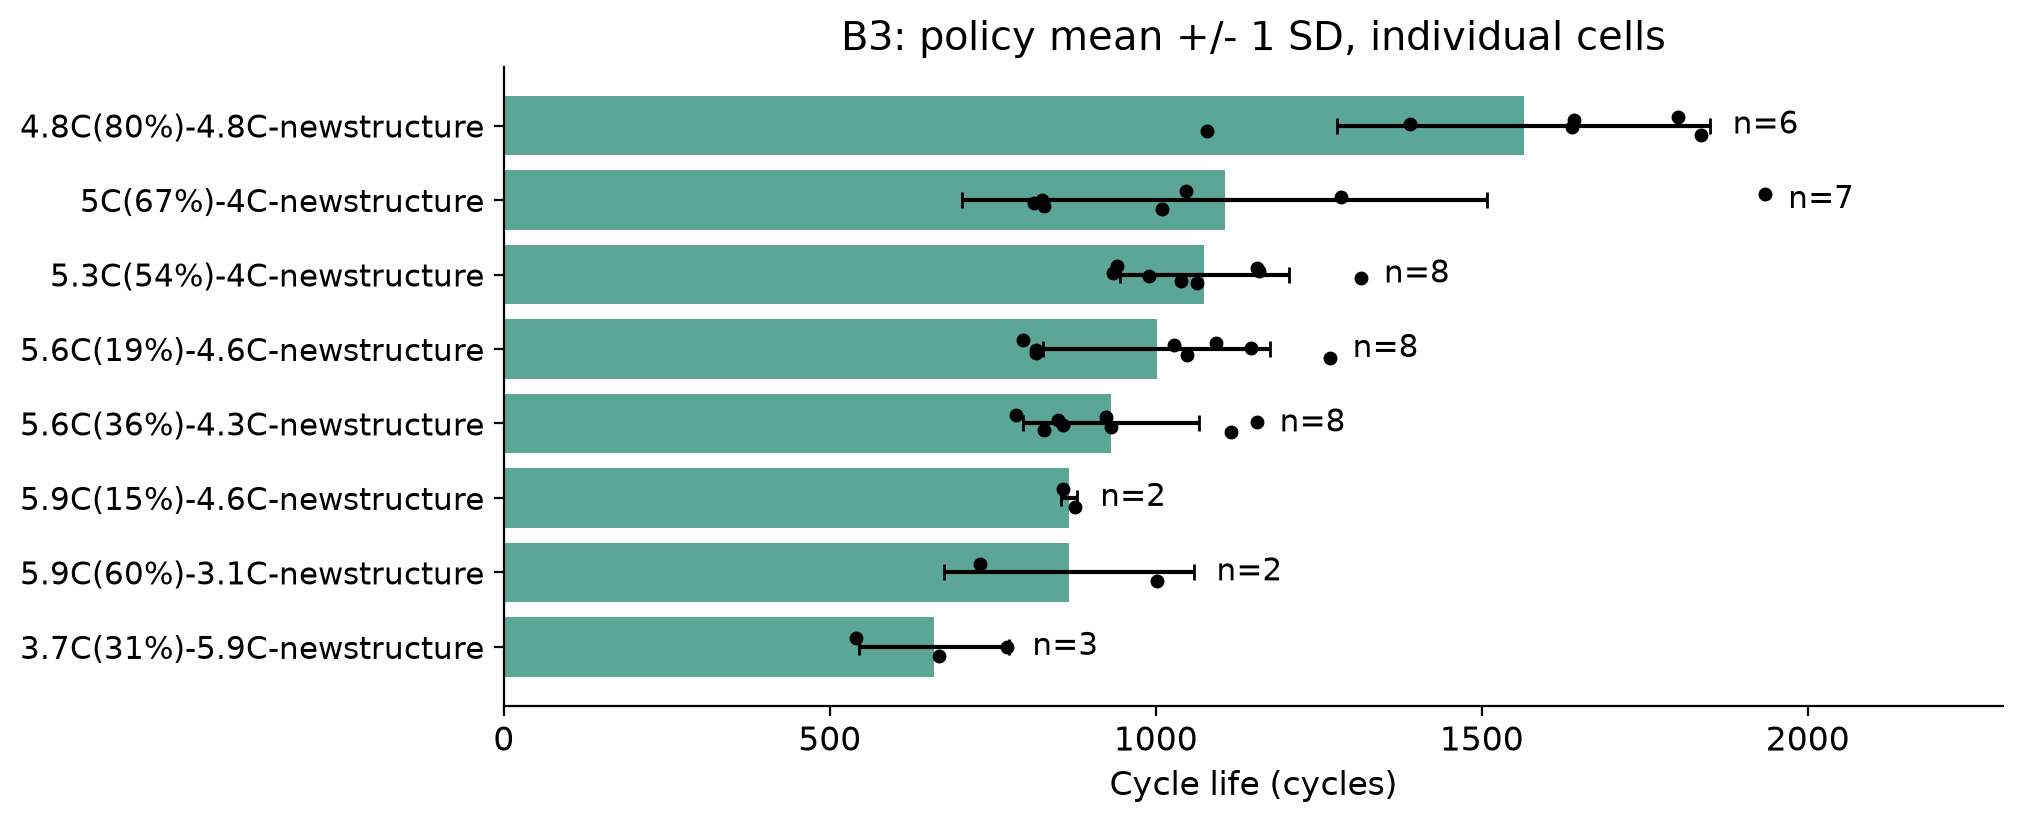


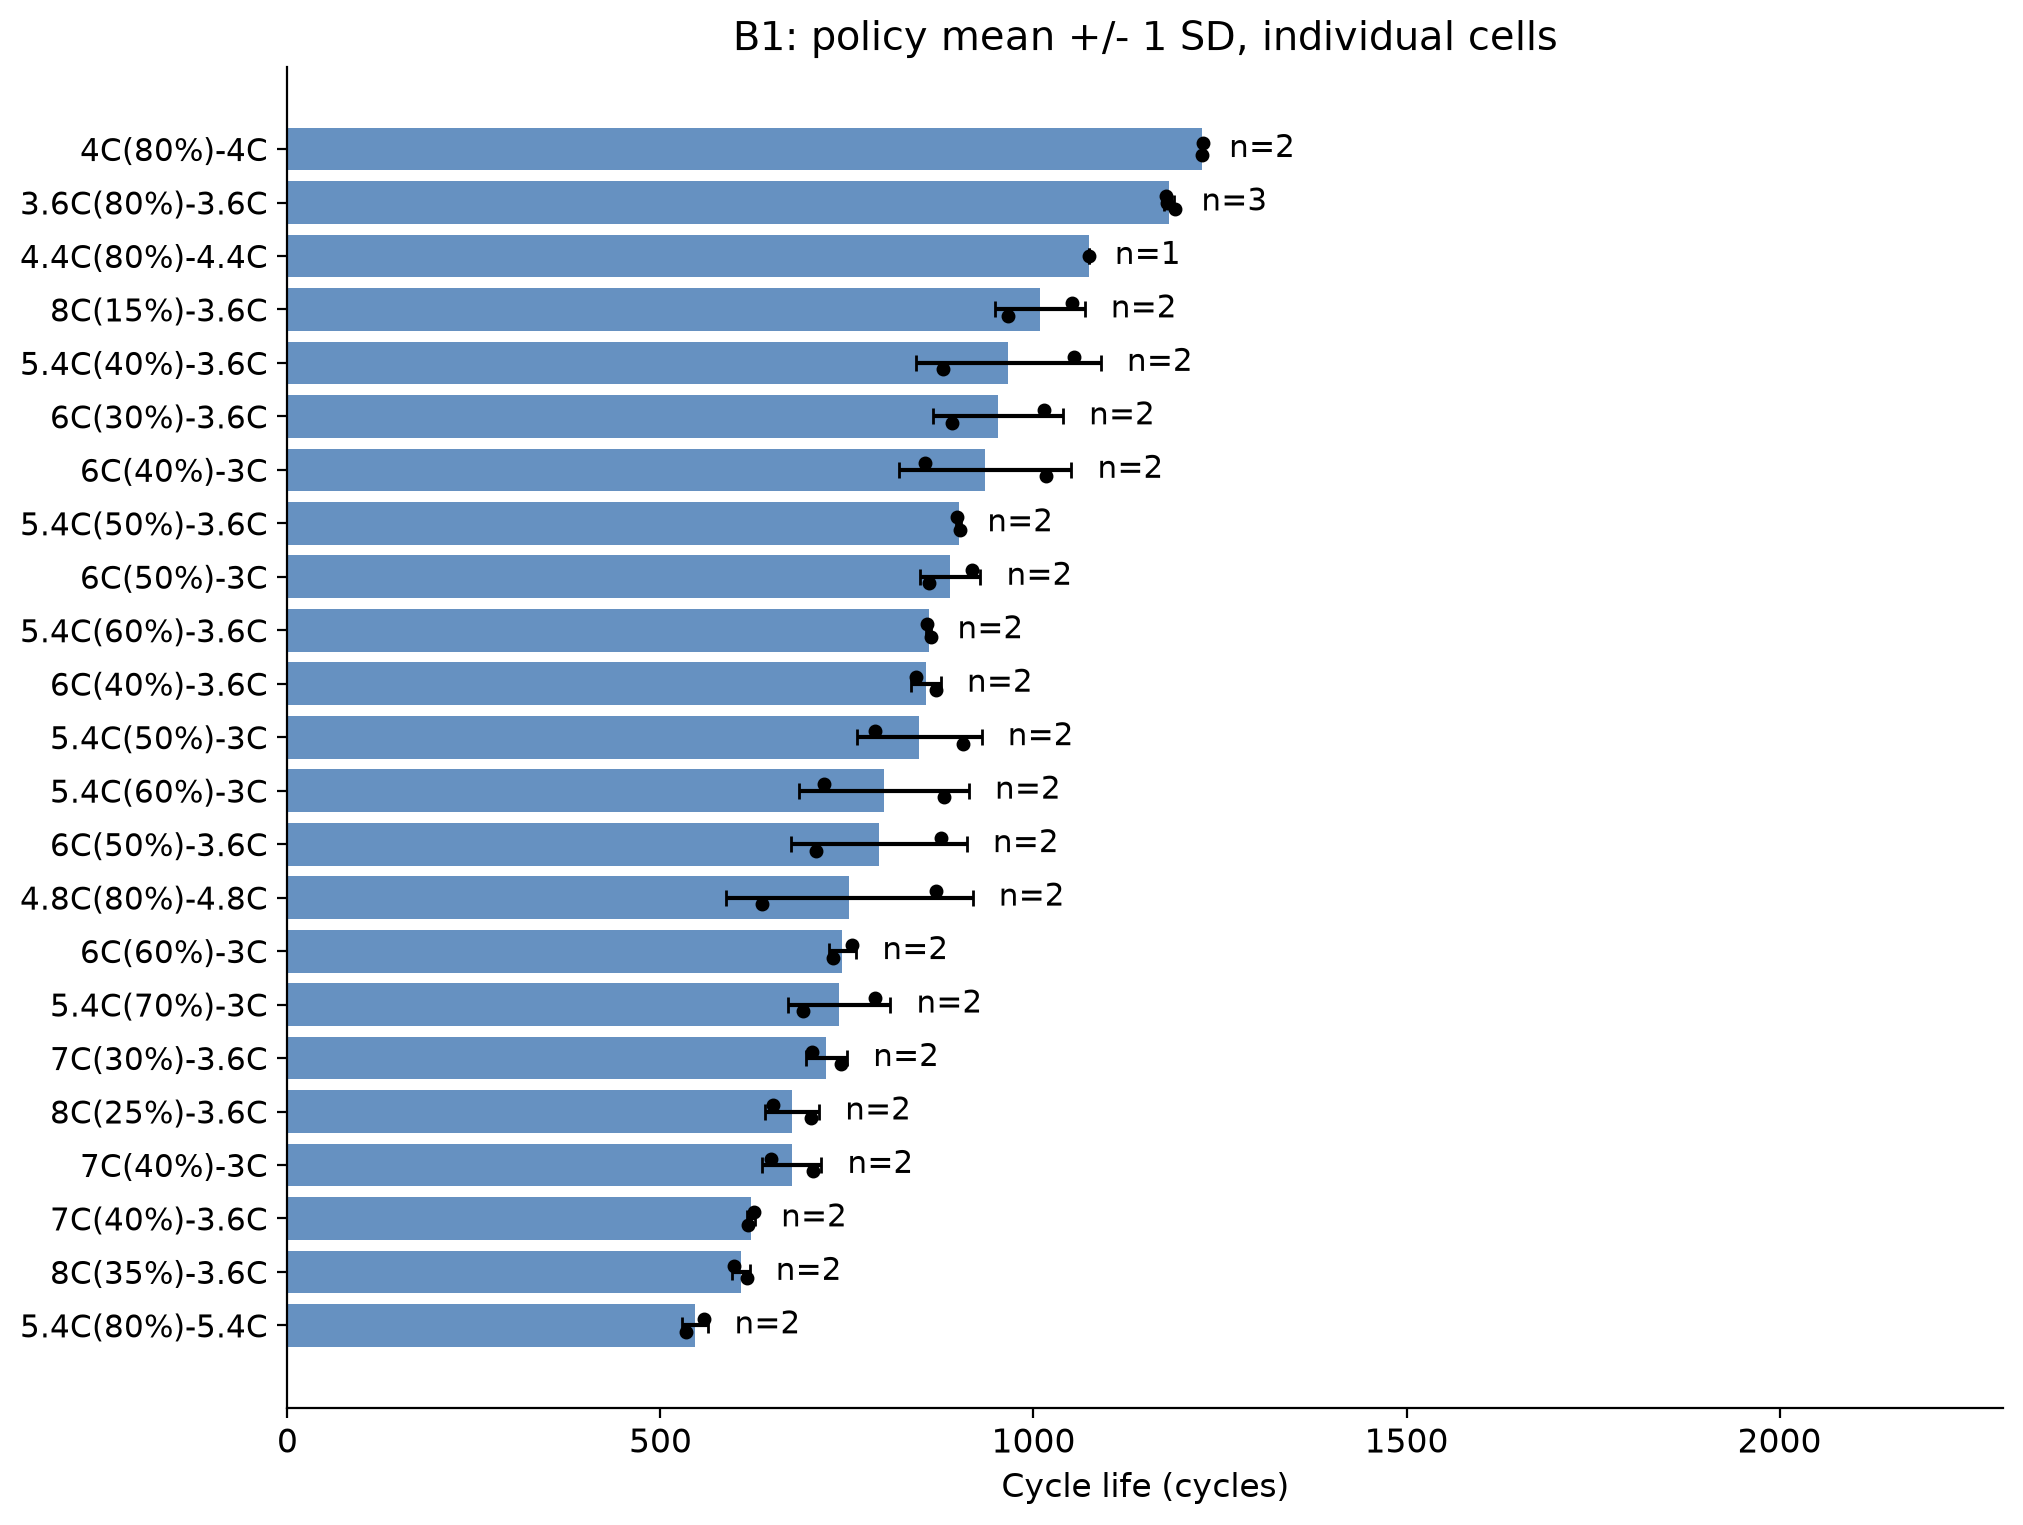
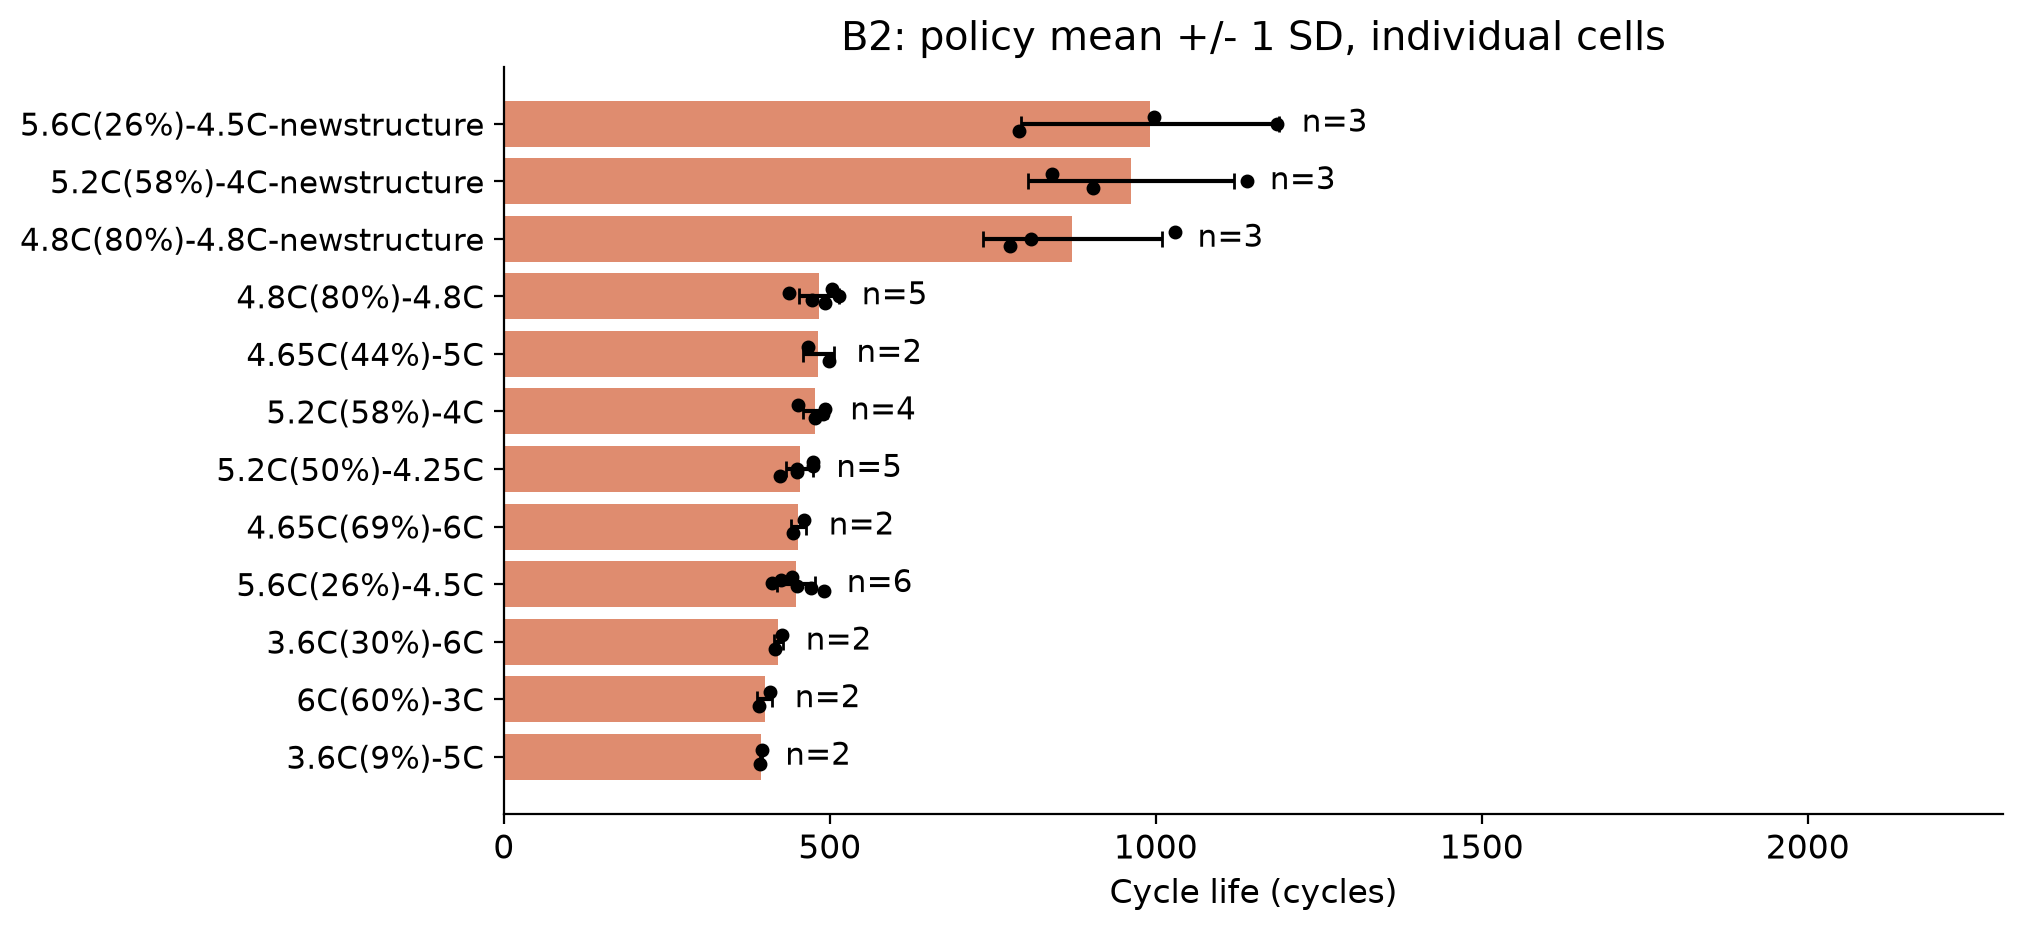
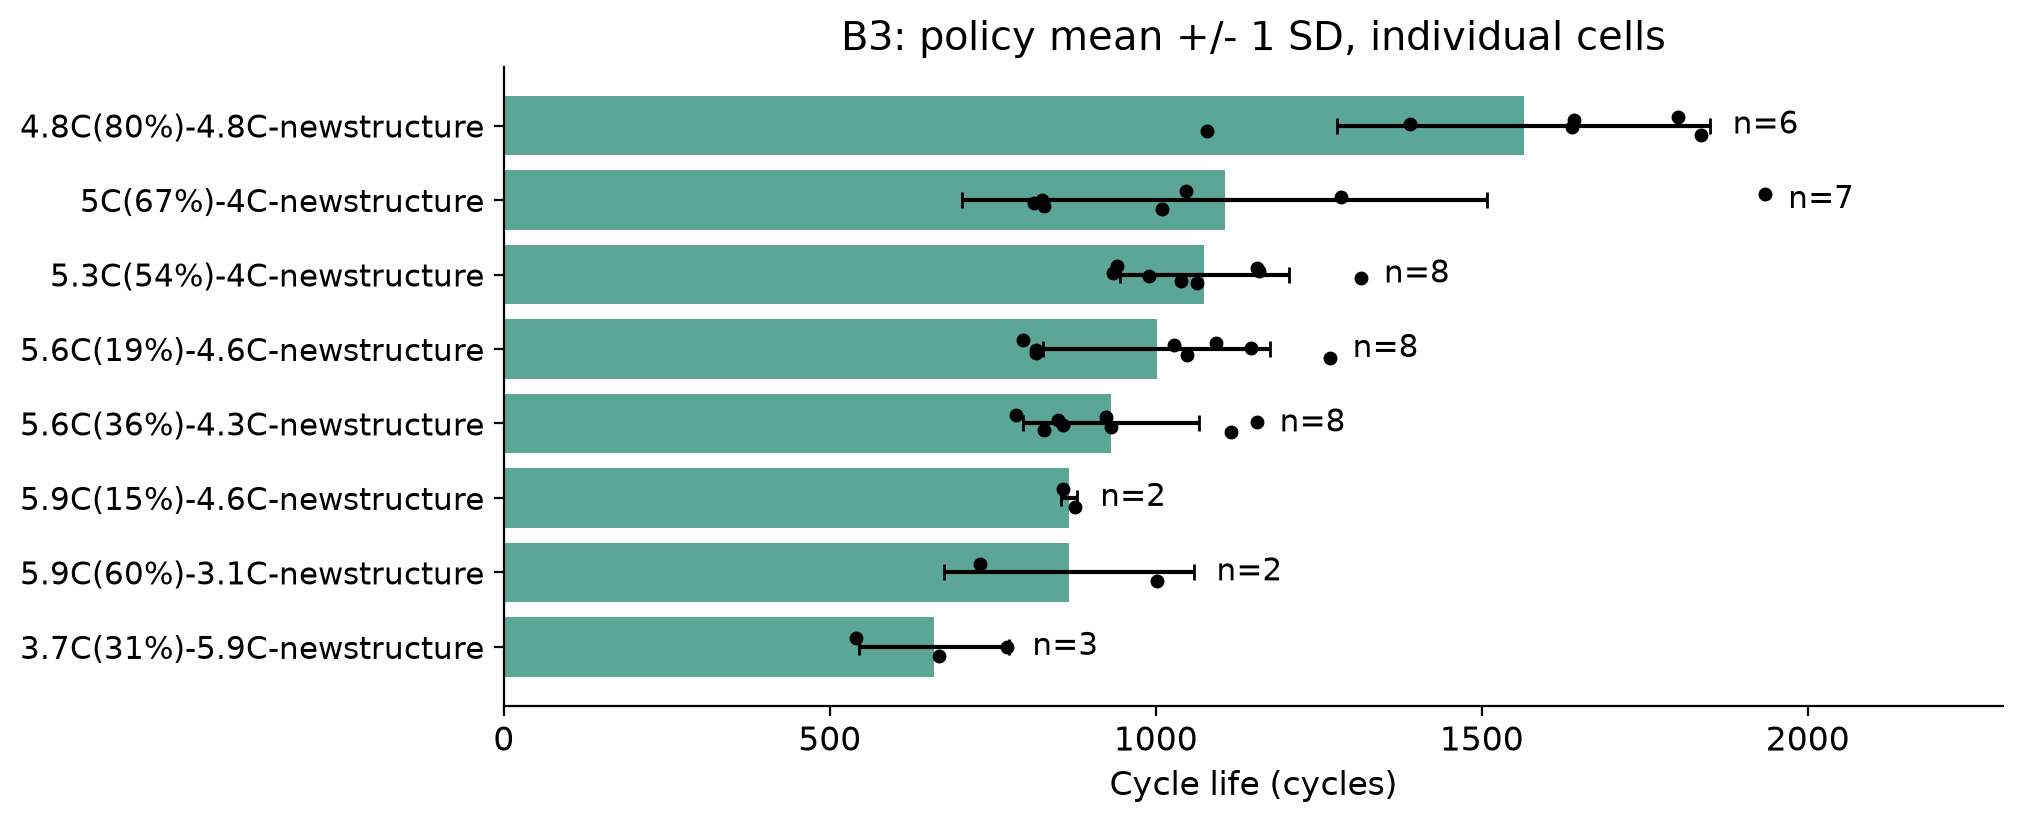

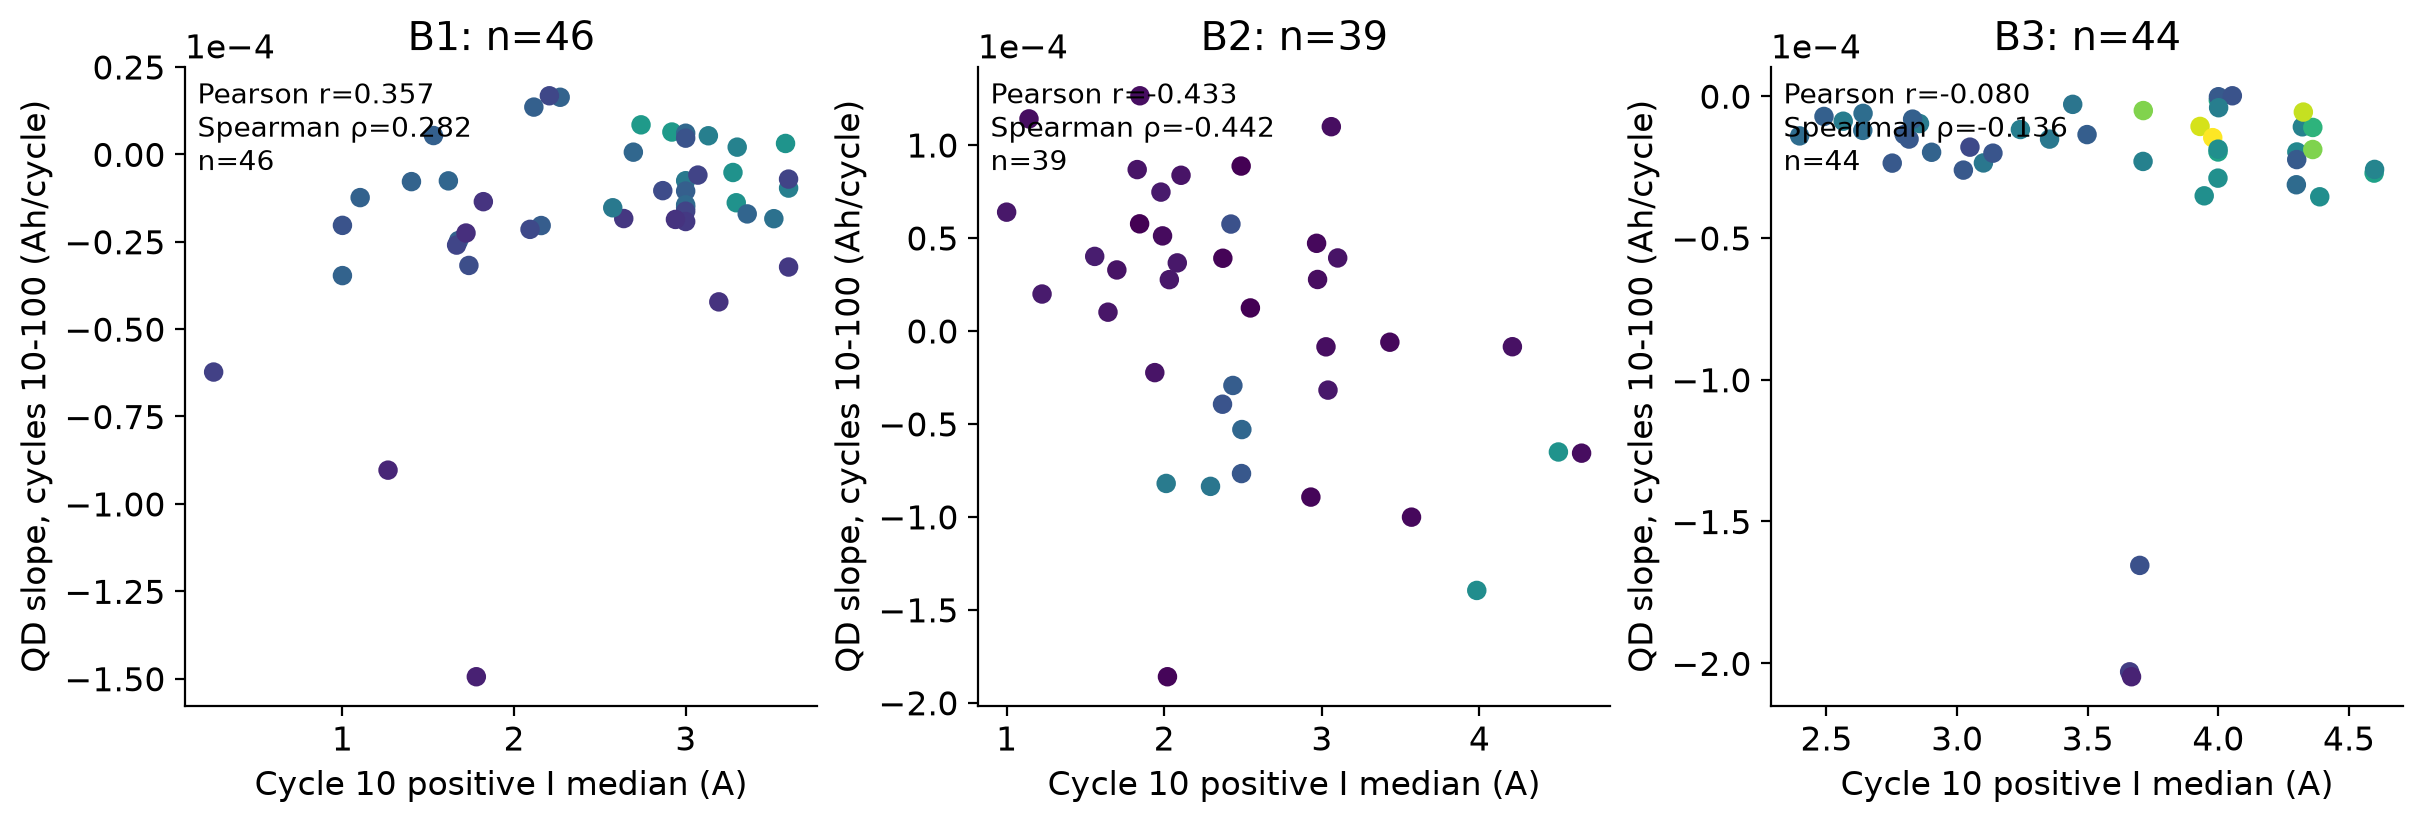

배치,피처,수명 상관관계
B1,C1,"Pearson r=-0.580, Spearman ρ=-0.483, n=46"
B1,C2,"Pearson r=-0.096, Spearman ρ=0.047, n=46"
B1,switch_SOC,"Pearson r=0.235, Spearman ρ=0.185, n=46"
B1,mean_chargetime,"Pearson r=0.577, Spearman ρ=0.613, n=46"
B1,I10_charge_median,"Pearson r=0.351, Spearman ρ=0.297, n=46"
B2,C1,"Pearson r=0.191, Spearman ρ=0.055, n=39"
B2,C2,"Pearson r=-0.116, Spearman ρ=-0.119, n=39"
B2,switch_SOC,"Pearson r=0.116, Spearman ρ=0.288, n=39"
B2,mean_chargetime,"Pearson r=0.087, Spearman ρ=-0.393, n=39"
B2,I10_charge_median,"Pearson r=0.233, Spearman ρ=-0.104, n=39"

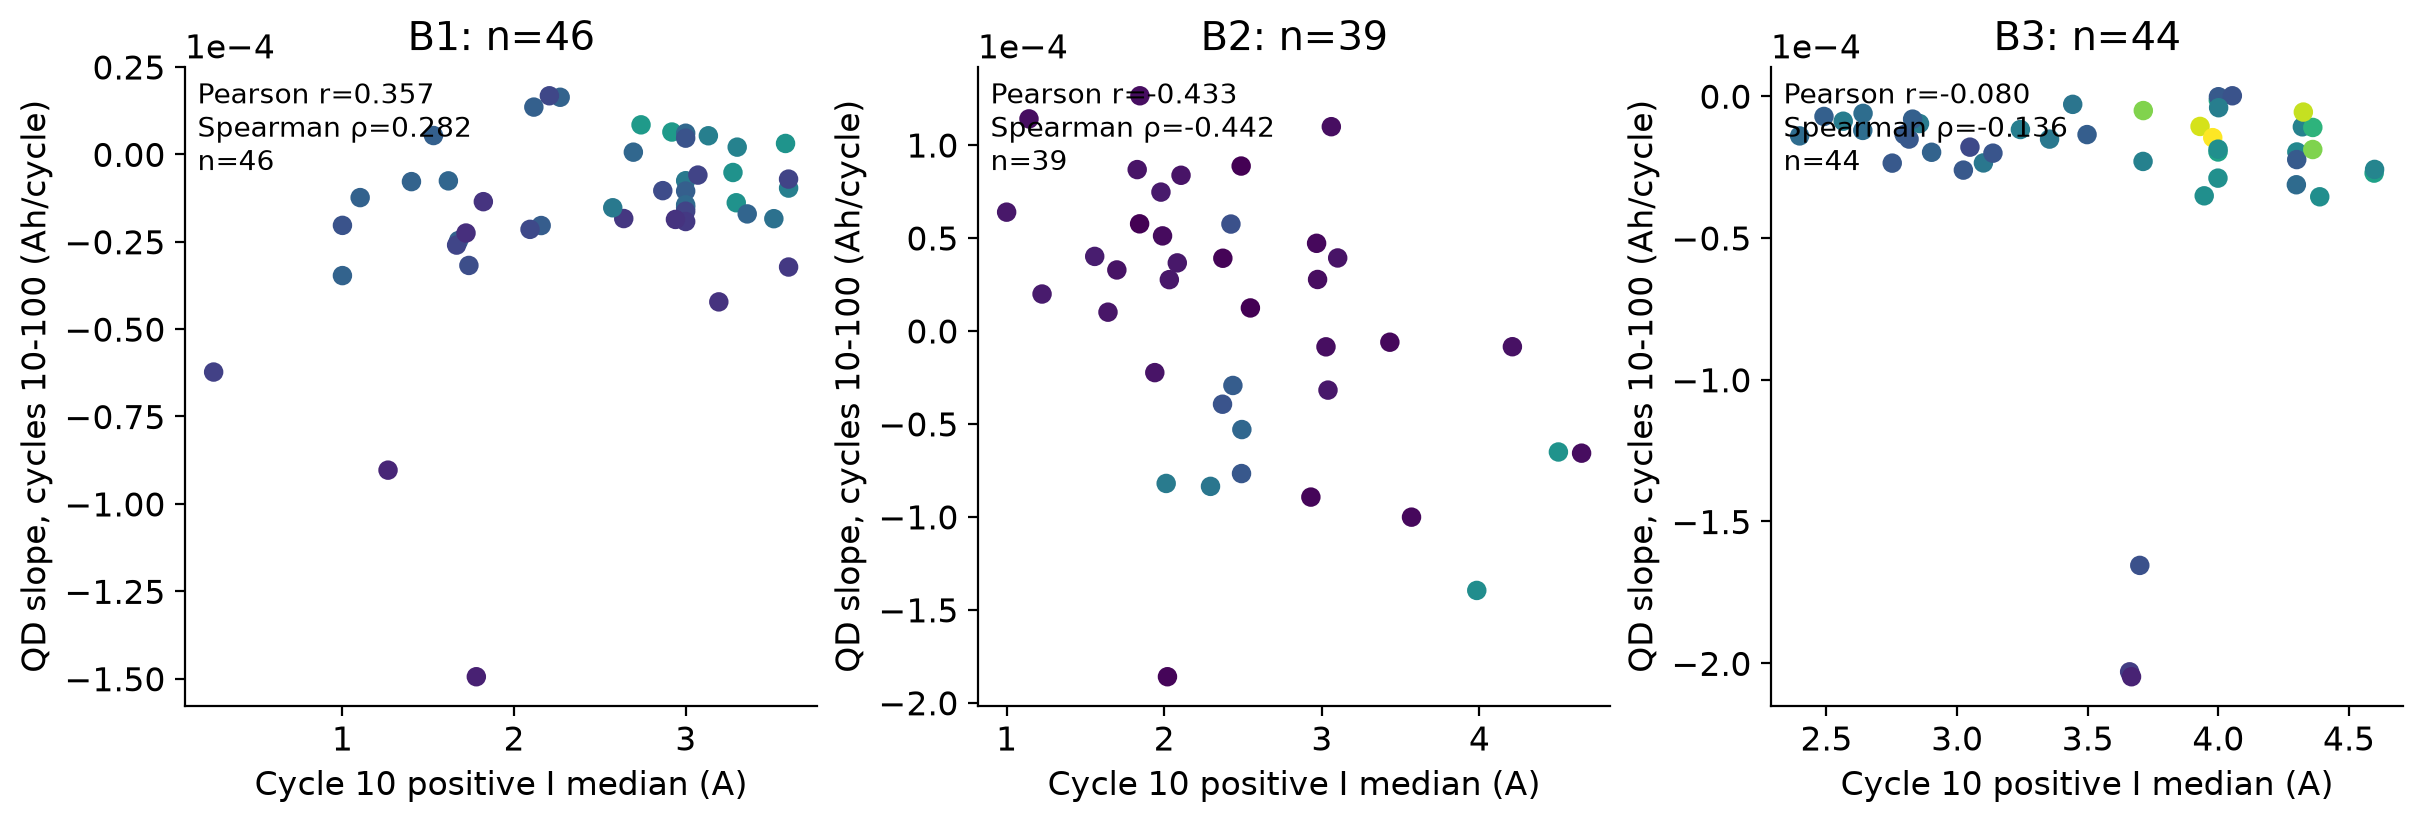

In [6]:
policy_stats=usable.groupby(['batch','policy']).cycle_life.agg(['count','mean','median','std']).reset_index()
parse_fail=usable[usable[['C1','switch_SOC','C2']].isna().any(axis=1)]
img=''
for bid in FILES:
    d=policy_stats[policy_stats.batch==bid].sort_values('mean')
    fig,ax=plt.subplots(figsize=(10,max(4,len(d)*.27+1.3)),layout='constrained')
    y=np.arange(len(d))
    ax.barh(y,d['mean'],xerr=d['std'].fillna(0),color=BATCH_COLORS[bid],alpha=.7,capsize=3)
    for j,r in enumerate(d.itertuples()):
        vals=usable.loc[(usable.batch==bid)&(usable.policy==r.policy),'cycle_life']
        jitter=np.linspace(-.12,.12,len(vals)) if len(vals)>1 else [0]
        ax.scatter(vals,j+np.array(jitter),color='black',s=16,zorder=3)
        right=max(vals.max(),r.mean+(r.std if np.isfinite(r.std) else 0))
        ax.text(right+35,j,f'n={r.count}',va='center',fontsize=11)
    ax.set_yticks(y,d.policy,fontsize=11)
    ax.set(title=f'{bid}: policy mean +/- 1 SD, individual cells',xlabel='Cycle life (cycles)',xlim=(0,2300))
    img+=fig_save(fig,f'q4_charging_policy_{bid.lower()}.png',f'{bid}: 정책별 평균 ±1표준편차와 개별 셀. n=1은 표준편차를 추정할 수 없어 오차막대 없이 표시한다. newstructure 접미사는 보존한다.')
policy_corr=pd.DataFrame([{'batch':bid,'feature':f,'relationship':r_text(d,f)}
    for bid,d in feat.groupby('batch') for f in ['C1','C2','switch_SOC','mean_chargetime','I10_charge_median']])
add('Q4 · 고속 충전이면 언제나 수명이 짧은가?',img+
    '<p><b>수치 요약:</b> C1–수명 r은 B1 −0.580, B2 +0.191, B3 −0.083이다. 초기 충전시간–수명 r은 +0.577, +0.087, +0.637이다. 따라서 B1의 관계를 모든 배치의 동일한 충전 효과로 일반화할 수 없다.</p>'+
    '<p><b>관찰:</b> 동일 명목 C-rate라도 전환 SOC, 두 번째 단계, newstructure 조건에 따라 수명이 다르다. 정책별 표본 수와 분포를 함께 보아야 하며 전체 C1만으로 충전 강도를 대표하기 어렵다.</p>'+
    f'<p>수명 라벨이 있는 셀의 정책 분해 실패: {len(parse_fail)}개. 접미사는 원문 정책에 유지하고 newstructure를 별도 표식으로 저장했다.</p>'+
    '<p><b>해석:</b> 빠른 충전의 영향을 관찰할 수 있지만 정책과 구조·배치·온도 등이 함께 변한다. 충전 속도 자체의 인과효과나 구조 변경의 효과를 확정하지 않는다.</p>'+
    '<p><b>전략:</b> C1·SOC·C2를 수치 피처 후보로 분해해 미관측 정책에도 적용 가능하게 한다. 정책 문자열은 보조 범주형 후보로 남기며 구조 접미사를 삭제해 서로 다른 실험을 합치지 않는다. 구조 표식은 Batch 1에 변화가 없으면 학습 입력에서 제외하고 도메인 이동 점검에 사용한다.</p>')
fig,axs=plt.subplots(1,3,figsize=(12,4),layout='constrained')
for ax,bid in zip(axs,FILES):
    d=feat[feat.batch==bid]
    ax.scatter(d.I10_charge_median,d.QD_slope_10_100,c=d.cycle_life,cmap='viridis',norm=norm)
    ax.set(title=f'{bid}: n={len(d)}',xlabel='Cycle 10 positive I median (A)',ylabel='QD slope, cycles 10-100 (Ah/cycle)')
    ax.ticklabel_format(axis='y',style='sci',scilimits=(0,0))
    ax.text(.02,.98,r_text(d,'I10_charge_median','QD_slope_10_100').replace(', ','\n'),transform=ax.transAxes,va='top',fontsize=10)
img=fig_save(fig,'q4_current_degradation.png','10사이클 양수 전류(I>0.1A) 중앙값과 10–100사이클 QD 기울기. 전체 충전 프로토콜의 시간 가중 평균은 아니며 설명용 요약값이다.')
current_corr=pd.DataFrame([{'batch':bid,'signal':f,'early_degradation_relationship':r_text(d,f,'QD_slope_10_100')}
                           for bid,d in feat.groupby('batch') for f in ['I10_charge_median','mean_chargetime']])
add('Q4 보충 · 충전 신호와 초기 열화 속도',img+table(policy_corr)+table(current_corr)+
    '<p>전류의 양수 표본 중앙값은 충전 패턴의 일부만 요약한다. 초기 충전시간과 함께 확인하지만, 샘플링 간격과 단계별 지속시간 차이가 남는다. 낮은 상관도 인과관계의 부재를 의미하지 않는다. 이 신호와 C-rate·충전시간 사이의 중복은 다음 피처 상관행렬에서 점검한다.</p>')
policy_stats.to_csv(OUTPUT_DIR/'policy_statistics.csv',index=False)

## 5. 초기 신호 상관관계와 다중공선성

동일 셀의 수백 사이클을 독립 표본으로 세지 않는다. 배치별 + 전체 셀당 한 행을 사용한다.
Pearson / Spearman과 유효 n을 기록하고, 학습용 피처 선정 근거는 Batch 1에서 별도로 확인한다.

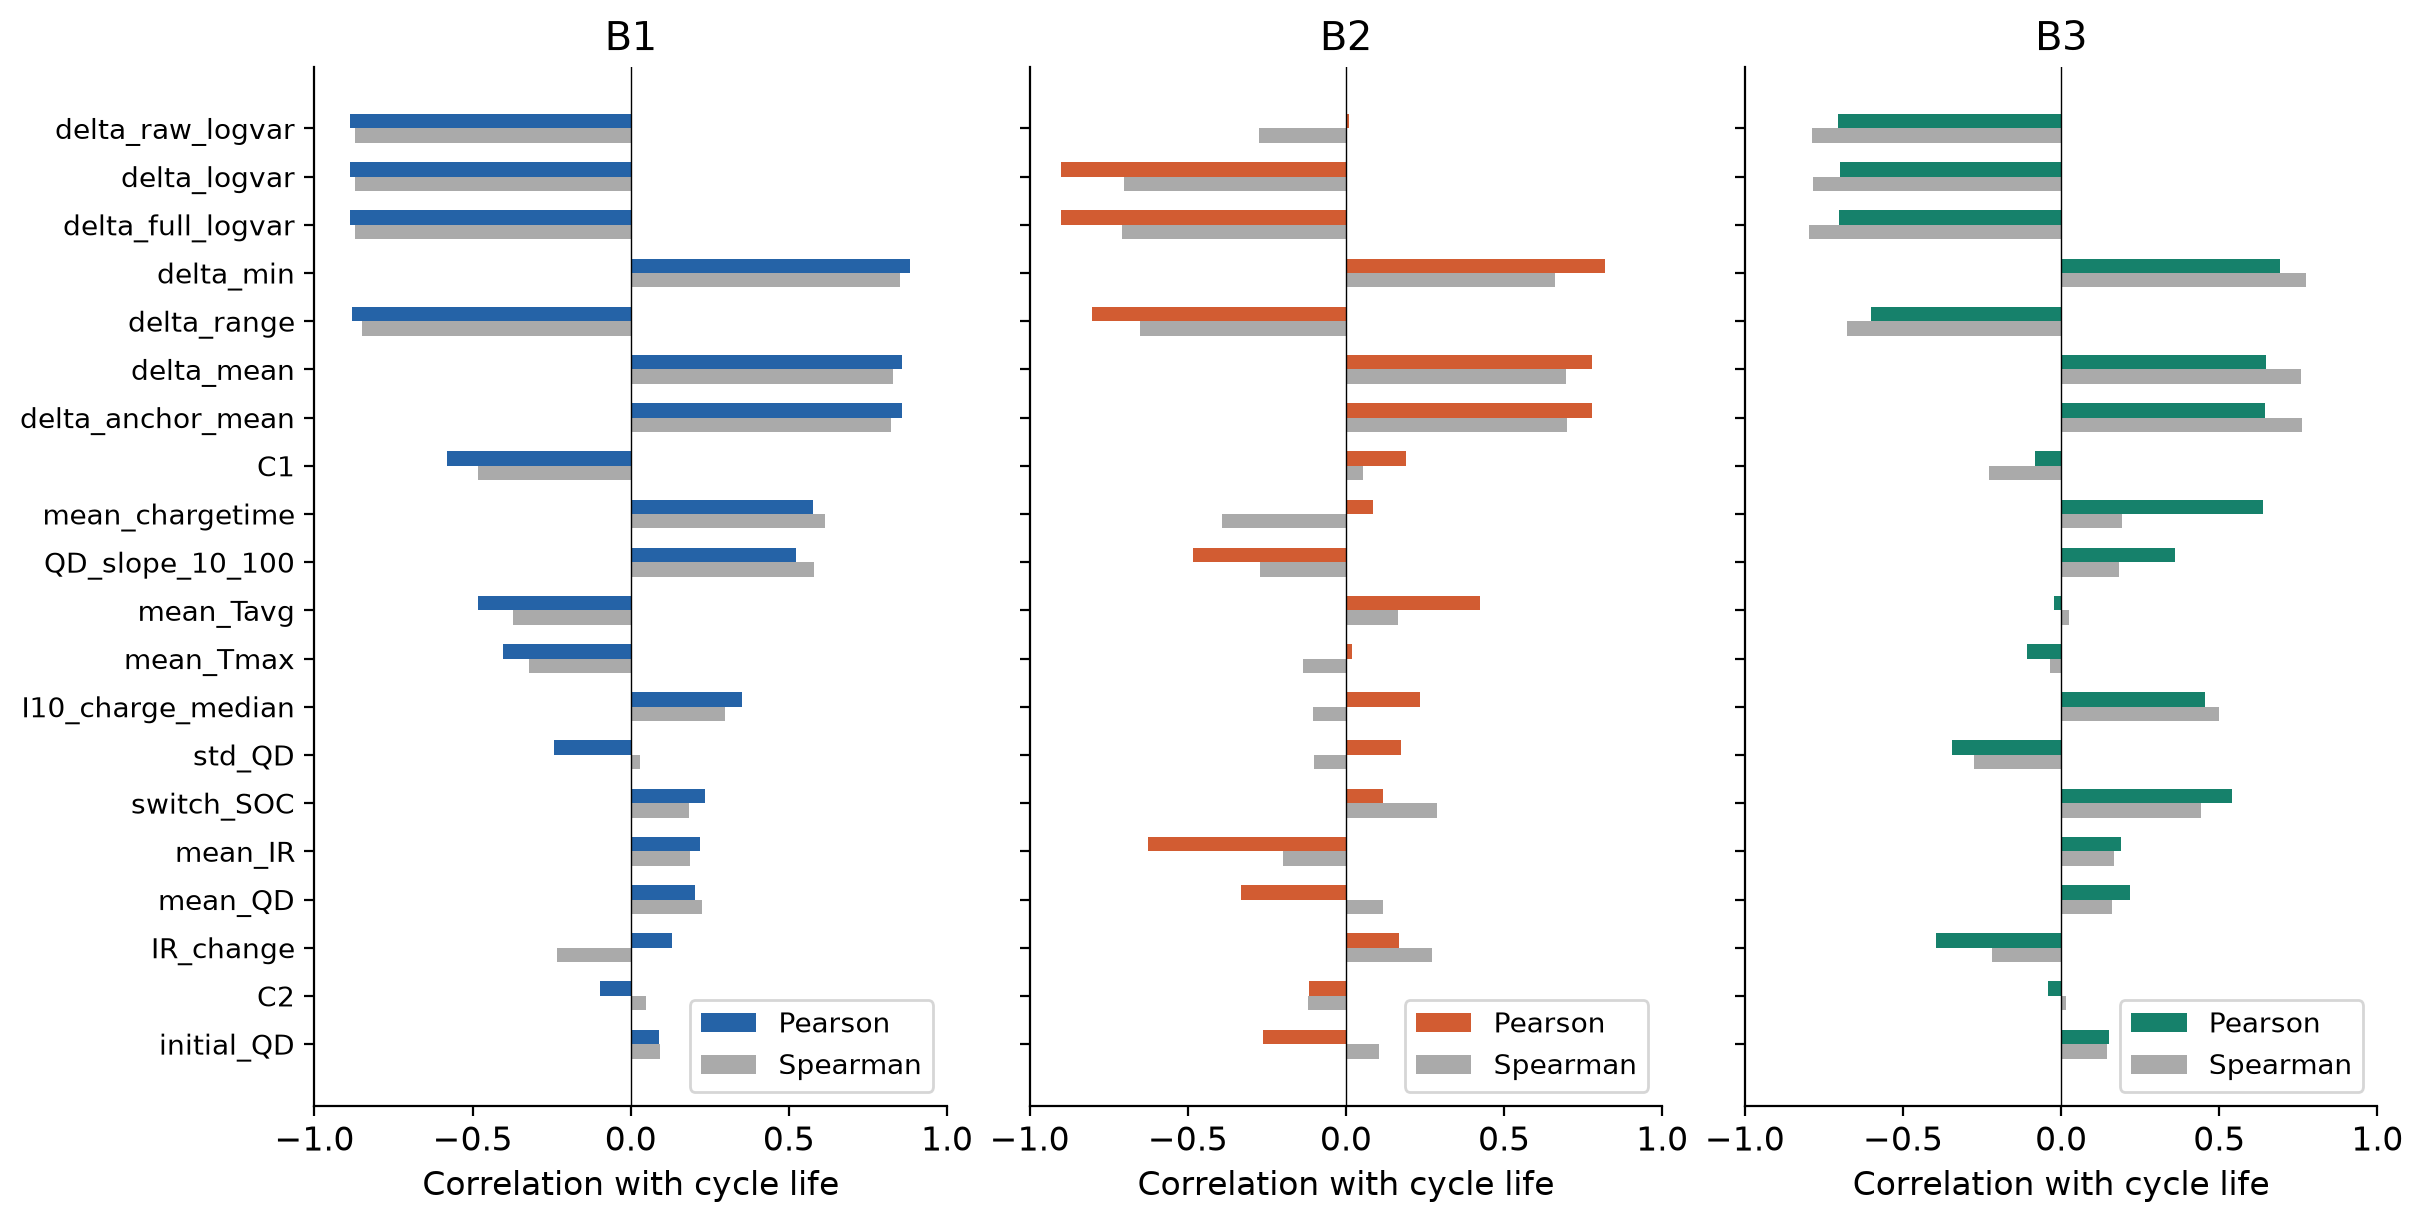

피처,All,B1,B2,B3
delta_raw_logvar,-0.528,-0.888,0.011,-0.706
delta_logvar,-0.849,-0.887,-0.901,-0.700
delta_full_logvar,-0.851,-0.886,-0.902,-0.702
delta_min,0.827,0.882,0.818,0.692
delta_range,-0.800,-0.882,-0.802,-0.602
delta_mean,0.803,0.858,0.778,0.647
delta_anchor_mean,0.802,0.858,0.777,0.644
C1,-0.078,-0.580,0.191,-0.083
mean_chargetime,-0.194,0.577,0.087,0.637
QD_slope_10_100,-0.132,0.524,-0.484,0.361

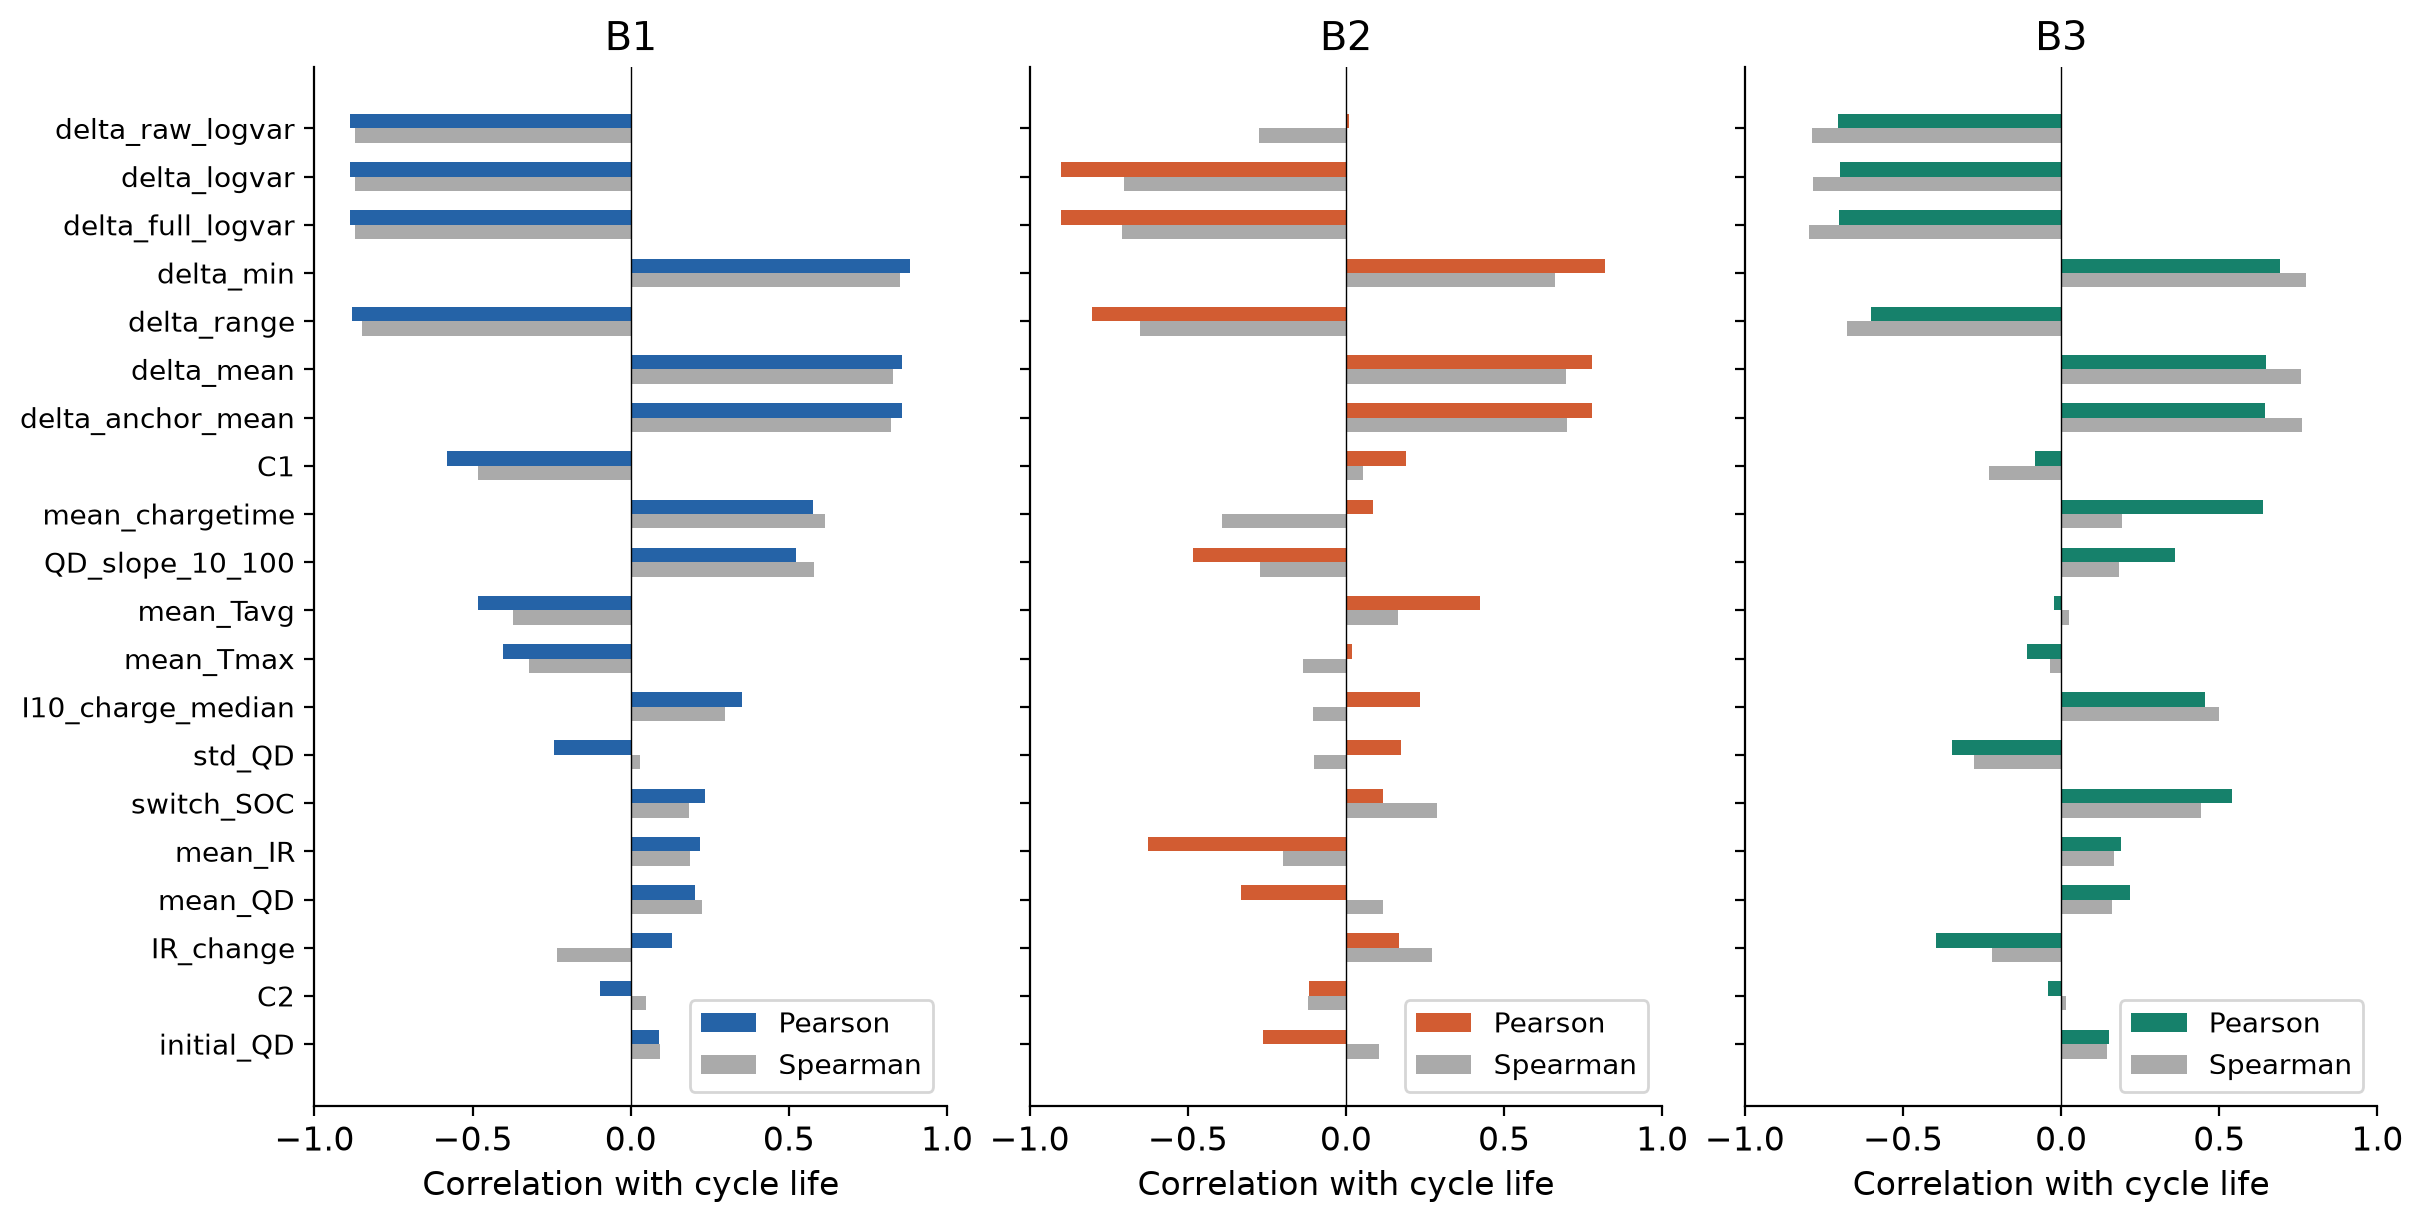

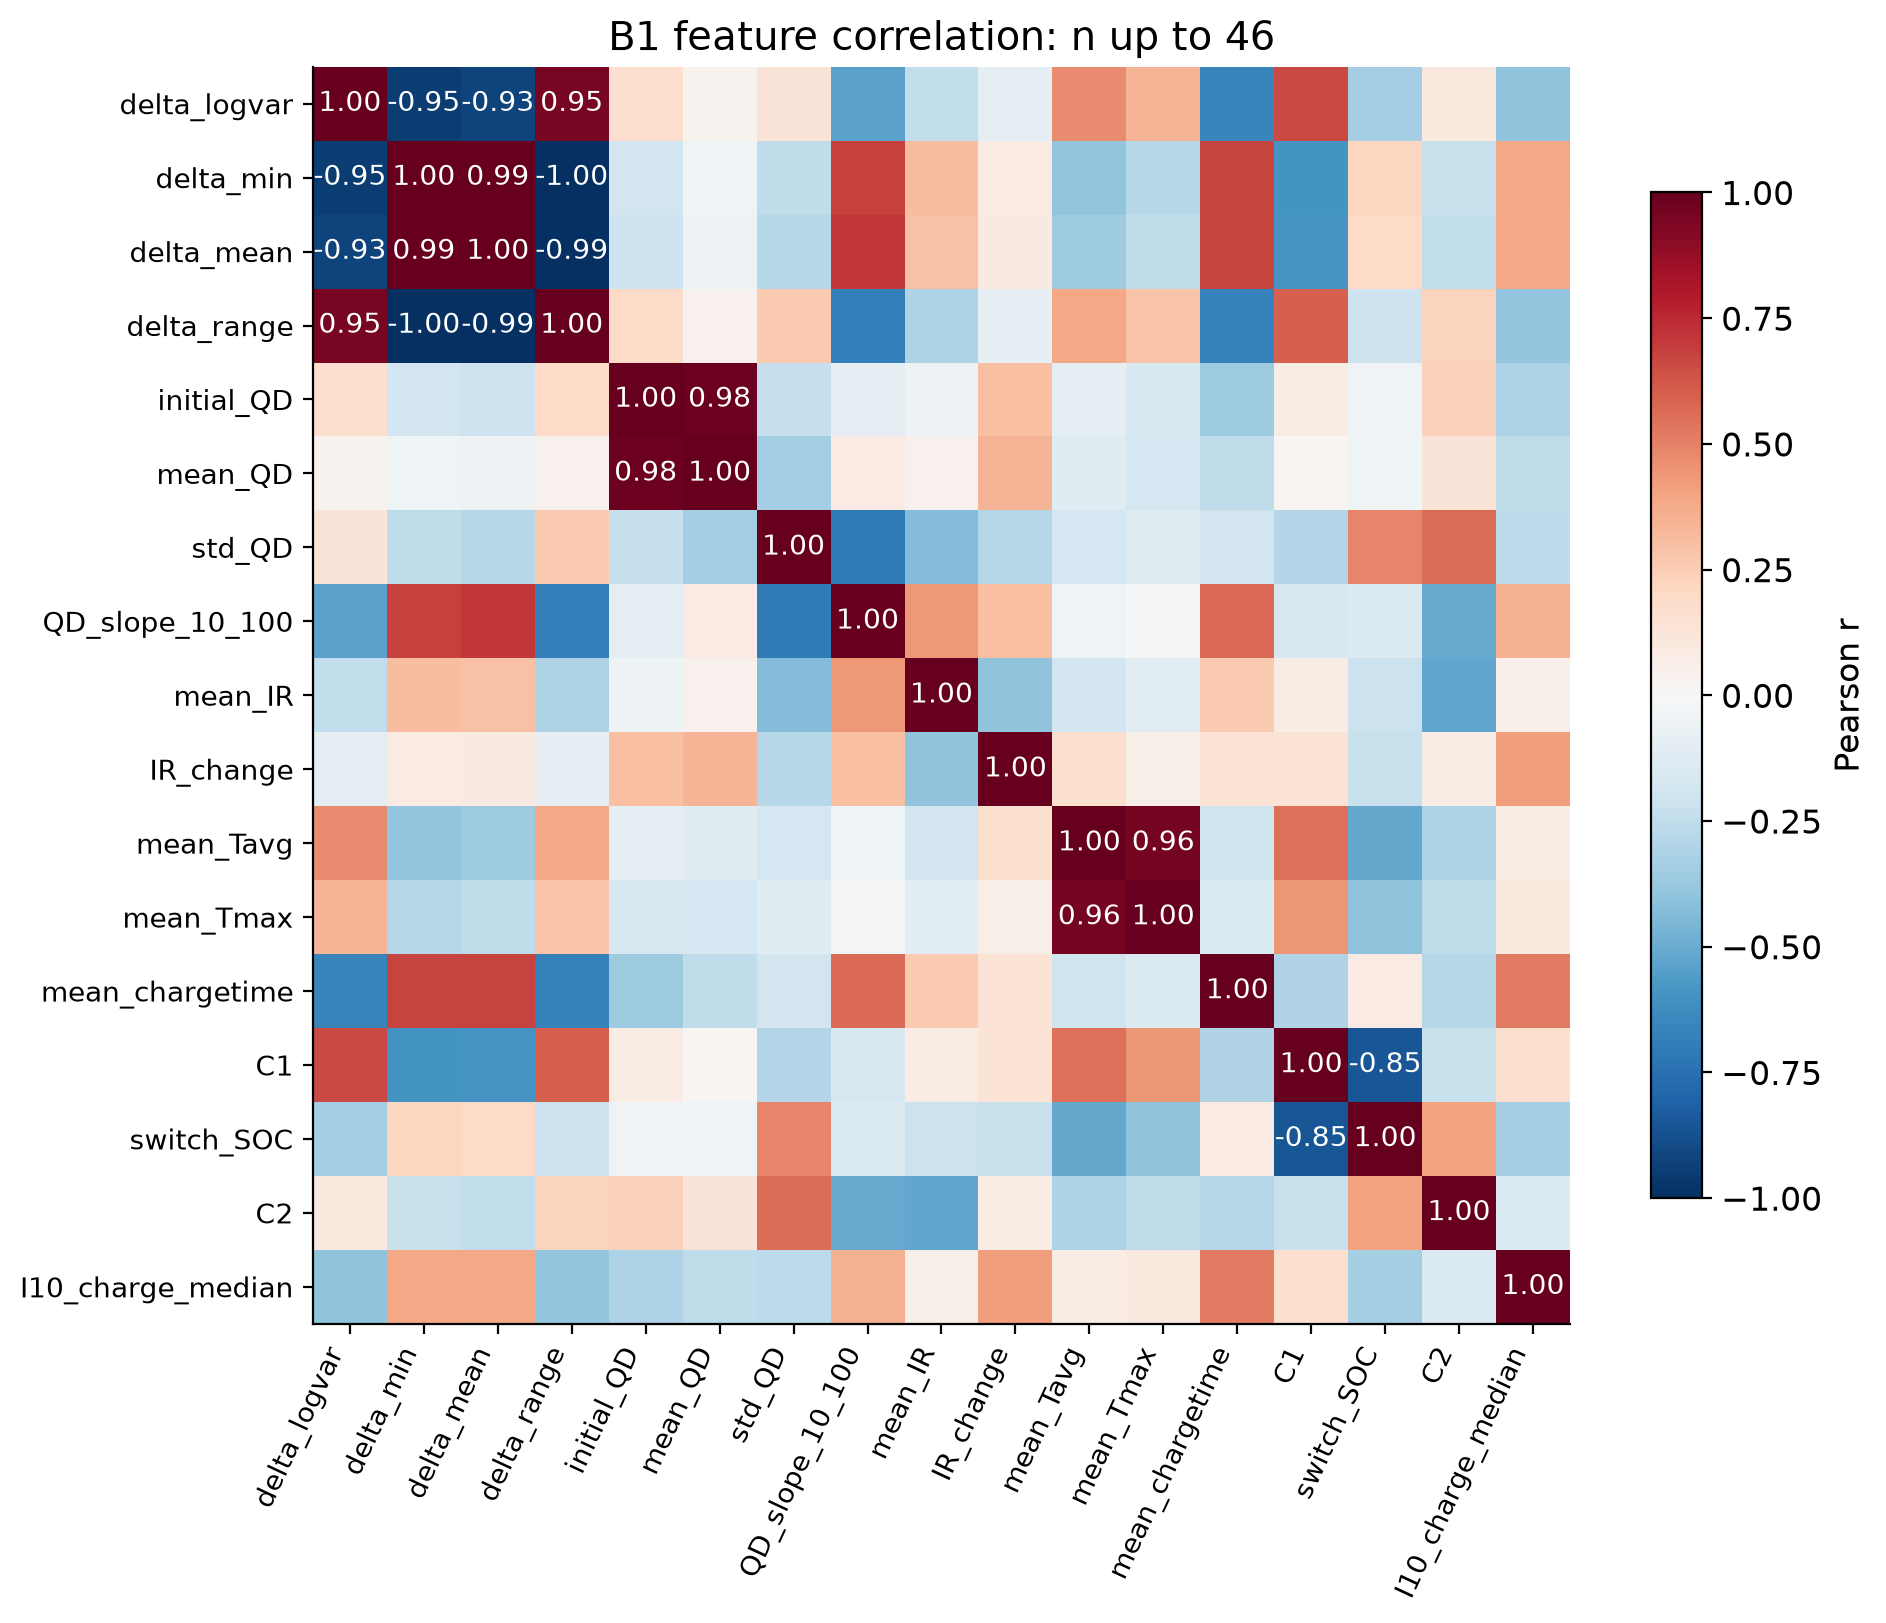

피처 1,피처 2,r,유효 n
delta_min,delta_range,-1.000,46
delta_mean,delta_range,-0.994,46
delta_min,delta_mean,0.994,46
initial_QD,mean_QD,0.981,46
mean_Tavg,mean_Tmax,0.956,46
delta_logvar,delta_min,-0.946,46
delta_logvar,delta_range,0.946,46
delta_logvar,delta_mean,-0.928,46
C1,switch_SOC,-0.854,46

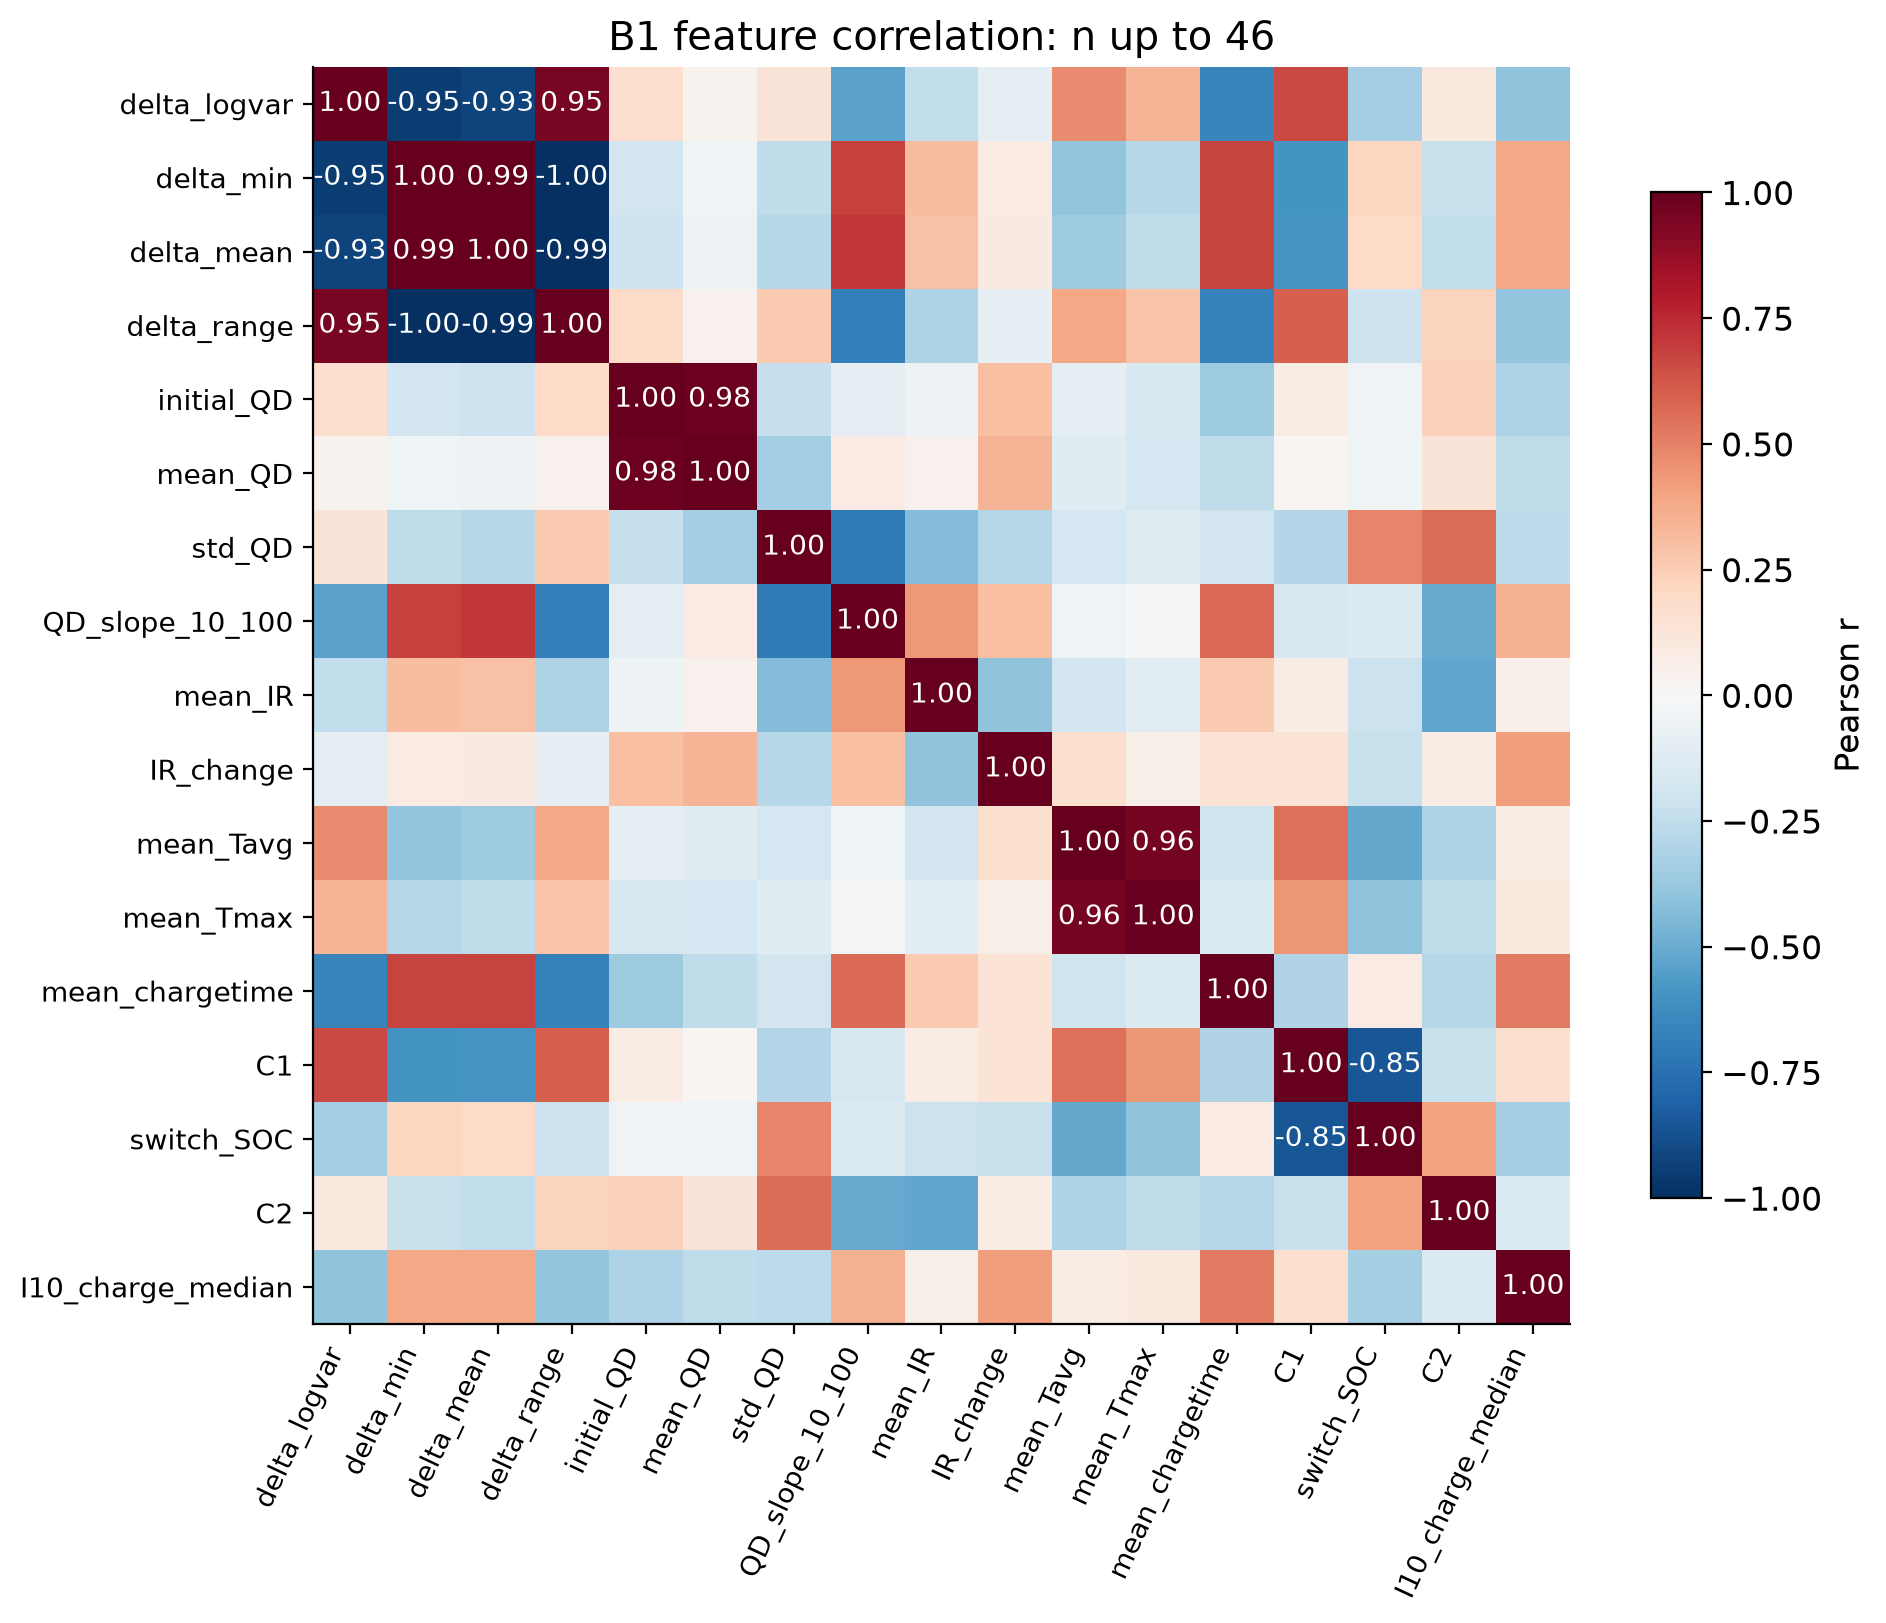

In [7]:
F=['delta_logvar','delta_min','delta_mean','delta_range','delta_anchor_mean','delta_full_logvar','delta_raw_logvar',
   'initial_QD','mean_QD','std_QD','QD_slope_10_100','mean_IR','IR_change','mean_Tavg','mean_Tmax',
   'mean_chargetime','C1','switch_SOC','C2','I10_charge_median']
corr_records=[]
for bid,d in list(feat.groupby('batch'))+[('All',feat)]:
    for f in F:
        a=d[[f,'cycle_life']].dropna()
        ok=len(a)>=3 and a[f].nunique()>1 and a.cycle_life.nunique()>1
        corr_records.append({'batch':bid,'feature':f,'n':len(a),
                             'Pearson':a[f].corr(a.cycle_life) if ok else np.nan,
                             'Spearman':a[f].corr(a.cycle_life,method='spearman') if ok else np.nan})
corr_df=pd.DataFrame(corr_records)
rank=corr_df[corr_df.batch=='B1'].assign(abs_r=lambda x:x.Pearson.abs()).sort_values('abs_r',ascending=False)
fig,axs=plt.subplots(1,3,figsize=(12,6),layout='constrained',sharey=True)
for ax,bid in zip(axs,FILES):
    d=corr_df[corr_df.batch==bid].set_index('feature').loc[rank.feature]
    y=np.arange(len(d));ax.barh(y-.15,d.Pearson,height=.3,color=BATCH_COLORS[bid],label='Pearson')
    ax.barh(y+.15,d.Spearman,height=.3,color='#aaa',label='Spearman')
    ax.set_yticks(y,d.index,fontsize=10);ax.invert_yaxis();ax.set(title=bid,xlim=(-1,1),xlabel='Correlation with cycle life')
    ax.axvline(0,color='black',lw=.5);ax.legend(fontsize=10,loc='lower right')
img=fig_save(fig,'q5_feature_target_correlations.png','피처–수명 Pearson·Spearman 상관. 피처 순서는 Batch 1의 Pearson 절댓값 순이며 배치별 관계를 별도로 표시한다. 결측·상수 피처는 산출 불가.')
compact=corr_df.pivot(index='feature',columns='batch',values='Pearson').reindex(rank.feature).reset_index()
compact.columns.name=None
count_table=corr_df[corr_df.batch=='B1'][['feature','n','Pearson','Spearman']].set_index('feature').loc[rank.feature].reset_index()
valid_counts=feat.groupby('batch')[['delta_logvar','mean_IR','IR_change','mean_Tavg','mean_chargetime']].count().reset_index()
add('Q5 · 어떤 신호를 우선 후보로 둘 것인가?',img+table(compact)+table(count_table)+table(valid_counts)+
    '<p><b>핵심 발견:</b> 온도 평균–수명 r은 B1 −0.482, B2 +0.425, B3 −0.022인데 전체에서는 +0.239다. 충전시간도 B1 +0.577·B3 +0.637과 전체 −0.194가 다르다. 배치가 섞인 상관으로 물리적 원인을 단정하지 않는다. ΔQ 원본 로그 분산은 세 배치에서 음의 관계를 보이지만 raw 재보간은 B2의 0값 오류 때문에 r=+0.011로 왜곡된다. 이 진단 피처를 학습 후보로 채택하지 않는다.</p>'+ 
    '<p><b>관찰:</b> 각 초기 신호의 관계 크기와 방향은 배치마다 다를 수 있다. All 열은 배치 차이가 섞인 결과라 배치 내 관계를 대체하지 않는다. 유효 n은 결측 제거 후 셀 수이다.</p>'+
    '<p><b>전략:</b> ΔQ 로그 분산·초기 용량 변동/기울기·충전 및 온도 신호를 소수의 피처군으로 검토한다. Batch 1에서 검증하고, 단순 평균 IR처럼 약한 선형 신호도 변화율이나 비선형 관계를 확인한 뒤 판단한다. 상관계수만으로 최종 피처 또는 성능을 확정하지 않는다.</p>')
# 피처 중복은 Batch 1에서 결정할 계획이다. 상수/결측 값은 pairwise로 처리하며 n을 명시한다.
M=['delta_logvar','delta_min','delta_mean','delta_range','initial_QD','mean_QD','std_QD','QD_slope_10_100',
   'mean_IR','IR_change','mean_Tavg','mean_Tmax','mean_chargetime','C1','switch_SOC','C2','I10_charge_median']
b1=feat[feat.batch=='B1'];mat=b1[M].corr()
pairs=[]
for i,f in enumerate(M):
    for g in M[i+1:]:
        r=mat.loc[f,g]
        if np.isfinite(r) and abs(r)>=.85:
            pairs.append({'feature_1':f,'feature_2':g,'r':r,'n':len(b1[[f,g]].dropna())})
pairs_df=pd.DataFrame(pairs,columns=['feature_1','feature_2','r','n']).sort_values('r',key=abs,ascending=False)
fig,ax=plt.subplots(figsize=(10,8),layout='constrained')
im=ax.imshow(mat,cmap='RdBu_r',vmin=-1,vmax=1)
ax.set_xticks(range(len(M)),M,rotation=65,ha='right',fontsize=10);ax.set_yticks(range(len(M)),M,fontsize=10)
for i in range(len(M)):
    for j in range(len(M)):
        val=mat.iloc[i,j]
        if np.isfinite(val) and abs(val)>=.85:
            ax.text(j,i,f'{val:.2f}',ha='center',va='center',fontsize=10,
                    color='white' if abs(val)>.65 else 'black')
fig.colorbar(im,ax=ax,shrink=.8,label='Pearson r');ax.set_title(f'B1 feature correlation: n up to {len(b1)}')
img=fig_save(fig,'q5_multicollinearity.png','Batch 1 초기 피처 간 상관행렬. |r|≥0.85인 쌍을 아래 표로 별도 표시하고 중복 피처·규제 전략을 수립한다.')
add('Q5 보충 · 파생변수의 중복을 어떻게 줄일 것인가?',img+table(pairs_df)+
    '<p><b>수치 근거:</b> B1의 ΔQ 최소–범위 r=−0.999966, 평균–범위 r=−0.993615로 거의 같은 정보를 담는다. 온도 평균–최대 r=0.955804, 초기 QD 기준–평균 r=0.980642다. 각 군의 대표값부터 투입하고 나머지는 제거 비교로 검증한다.</p>'+ 
    '<p><b>전략:</b> ΔQ 분산·범위·최솟값·평균을 모두 자동 투입하지 않는다. 각 군에서 해석 가능하고 원점 변화에 강한 대표 피처를 우선한다. 온도 평균/최댓값, 초기 QD 수준, 충전시간/정책/전류도 같은 정보를 중복할 수 있다. |r|≥0.85는 탐색 기준이며 최종 제거는 학습 fold 안에서 수행한다.</p>'+
    '<p>Ridge는 잔존 공선성에 규제를 적용하고 Elastic Net은 선택·규제를 함께 검토한다. 트리 모델에서도 중복 피처를 그대로 늘려 중요도를 과해석하지 않는다. 최종 설계 행렬에서 조건수 또는 VIF를 추가 확인하되 n 대비 피처 수를 먼저 줄인다.</p>')
corr_df.to_csv(OUTPUT_DIR/'feature_target_correlations.csv',index=False)
pairs_df.to_csv(OUTPUT_DIR/'collinearity_pairs.csv',index=False)

## 6. 모델 설계 전략과 DAY 2 검증 계획

선택 태스크는 **초기 100사이클에서 총 cycle_life를 예측하는 회귀**다.
여기서는 후보와 검증 계획을 설계하며 모델을 학습하거나 성능 숫자를 채우지 않는다.

In [8]:
batch_comparison=usable.groupby('batch').agg(라벨셀=('cell_id','size'),수명중앙값=('cycle_life','median'),정책수=('policy','nunique'),구조접미사비율=('new_structure','mean')).reset_index()
for name in ['delta_logvar','mean_Tavg','mean_chargetime']:
    batch_comparison[name+' 중앙값']=feat.groupby('batch')[name].median().reindex(batch_comparison.batch).to_numpy()
batch_comparison['구조접미사비율']*=100
add('배치 비교 요약 · 관계 변화와 데이터 이동',table(batch_comparison)+
    '<p>B1과 B2의 수명 중앙값은 858.5 대 472사이클로 유사하지 않다. 이 로컬 파일에서는 요구사항의 일반적인 B1/B2 유사 분포 설명이 그대로 성립하지 않는다. B3는 중앙값 1,005.5사이클이며 전 셀 정책에 newstructure가 있다.</p>'+
    '<p>평균 온도는 B3가 높은데 수명도 길어 배치가 섞인 온도 상관을 원인으로 해석할 수 없다. 정책·구조·측정 차이가 결합된 상황이므로 B1 내 신호로 전략을 설계하고, 외부 배치의 성능 저하는 타깃 분포·미관측 정책·센서 정합성별로 해석한다. 표의 구조접미사비율은 원문 표식의 비율(%)이며 실제 구조 사양을 검증한 값은 아니다.</p>')

b1corr=corr_df[corr_df.batch=='B1'].set_index('feature')
def evidence(f):
    r=b1corr.loc[f]
    return f'B1 r={r.Pearson:.3f}, ρ={r.Spearman:.3f}, n={int(r.n)}'
feature_design=pd.DataFrame([
 ['ΔQ 로그 분산','log10(var(Q100−Q10)); 2.1–3.4V, 500점','10·100',evidence('delta_logvar'),'우선 후보: 원점 이동에 불변','0분산/비유한→NaN; 대치·스케일 fold 내부'],
 ['초기 QD 기울기','polyfit(cycle,QD,1)의 기울기','10–100',evidence('QD_slope_10_100'),'후보: 초기 열화 방향·속도','QD 비정상값 제외; std_QD와 중복 비교'],
 ['초기 QD 변동성','QD 표본 표준편차(ddof=1)','2–100',evidence('std_QD'),'보조 후보: 순위 상관이 약해 우선순위 낮음','단일 스파이크 민감도 및 강건 통계 비교'],
 ['초기 충전시간','양수 chargetime 평균','2–100',evidence('mean_chargetime'),'후보: 충전 과정 요약','C1/C2/전류와 중복; 단위 원문 메타데이터 확인'],
 ['온도 대표값','Tavg 평균; Tmax 대체 비교','2–100',evidence('mean_Tavg'),'대표값 하나부터 비교','평균·최대 중복 시 축소; 변화량은 후속 확인'],
 ['정책 수치 분해','C1, 전환 SOC(%), C2','실험 시작 시',evidence('C1'),'후보: 미관측 정책에 수치적 대응','정책 파싱·단위 검증; fold 내부 스케일링'],
 ['IR 평균/변화','IR>0 평균; median(IR91:100)−median(IR2:10)','≤100',evidence('mean_IR'),'보조 후보: ΔIR와 제거 비교','0값은 미측정 가능성; 실제 기록 확인 후 대치'],
 ['ΔQ 최소·평균·범위','min/mean/ptp(ΔQ)','10·100',evidence('delta_min'),'보류: 공선성·원점 민감도','로그 분산과 군별 제거 비교'],
 ['정책 문자열','policy_readable 원문','실험 시작 시','정책별 n·분포 및 미관측 정책','보조 비교: One-hot/CatBoost','미관측 범주 지원; 접미사 보존'],
 ['ID·배치·knee·전체 길이·종료 비율','설명용 메타데이터','미래 정보 포함','Q1·Q2 품질 및 분포','입력 제외','분할 관리와 오류 분석에만 사용'],
 ['newstructure','정책 접미사 표식','실험 시작 시','B1 내 구조 변화 유무','B1에서 상수이면 입력 제외','배치 이동 설명에 사용; 데이터 수집 확장 필요']
],columns=['피처군','계산/정의','관측 기간','객관적 근거','채택 계획','전처리·공선성'])
models=pd.DataFrame([
 ['중앙값 기준 모델','셀 수가 적고 배치 분포 차이가 큼','학습 라벨 중앙값으로 기본 난이도 확인','튜닝 없음; 단순 예측을 넘어서는지 비교'],
 ['Ridge / Elastic Net','ΔQ 통계와 초기 신호의 상관·중복 존재','표준화한 소수 피처, 규제로 분산 감소','alpha를 B1 그룹 CV에서 선택; Elastic Net l1_ratio도 제한된 후보'],
 ['Random Forest / Extra Trees','정책 전환·온도·열화 신호 상호작용 가능','비선형 대안으로 선형 모델과 비교','깊이 2–4, min_samples_leaf 3–8 우선; 외삽과 소표본 과적합 확인'],
 ['CatBoost (보조 후보)','정책 원문은 범주형이며 미관측 정책이 나타남','범주형 처리 대안; 수치 분해와 비교','깊이 2–4·강한 규제·작은 탐색; 초기 모델로 무조건 채택하지 않음']
],columns=['후보','EDA 발견','선정 이유','검증/제어 계획'])
class_info='; '.join(f'{r.batch}: 550 미만 {r.class0}/{r.n}, 550 이상 {r.class1}/{r.n}' for r in groups.itertuples())
add('설계 · 회귀를 선택하고 소수 피처·규제 모델부터 비교',
    '<p><b>선택:</b> 초기 100사이클 이내에서 제공된 총 수명 cycle_life를 회귀 예측한다. 초기 ΔQ 신호를 활용할 수 있고, '+class_info+'. Batch 1의 550 미만 표본 부족 때문에 5사이클 이진 분류는 검증 분할과 F1 추정이 매우 불안정하다.</p>'+
    '<p>cycle_life는 총 수명이며 RUL 그 자체가 아니다. 관측 종료 100사이클에서의 잔여 수명을 별도로 표현한다면 동일 EOL 정의하에서 cycle_life−100과 연결하되, 미완주/라벨 정의 확인을 선행한다.</p>'+table(feature_design)+table(models)+
    '<p><b>우선 순서:</b> 데이터·라벨 정합성 → 중앙값 기준 → ΔQ 중심 소수 피처의 Ridge → 피처군 추가/제거 비교 → 비선형 후보. 모든 후보는 계획이며 최적 모델·성능은 확정하지 않았다. 로그 타깃도 B1 CV에서만 비교하고 역변환 후 원래 사이클 단위의 MAPE를 평가한다.</p>')
# 공개 성능 측정이 아니라 분할 계획만 작성한다. 원문 정책 그룹을 고정 난수로 나눈다.
b1pol=sorted(usable.loc[usable.batch=='B1','policy'].unique())
rng=np.random.default_rng(42);shuffled=np.array(b1pol,dtype=object);rng.shuffle(shuffled)
n_hold=max(1,int(np.ceil(.2*len(shuffled))))
valid_policies=set(shuffled[:n_hold])
split=usable.loc[usable.batch=='B1',['cell_id','policy','cycle_life']].copy()
split['planned_split']=np.where(split.policy.isin(valid_policies),'Valid hold-out','Train for CV')
assert not (set(split.loc[split.planned_split=='Valid hold-out','policy']) & set(split.loc[split.planned_split=='Train for CV','policy']))
split_summary=split.groupby('planned_split').agg(cells=('cell_id','size'),policy_groups=('policy','nunique'),
    min_life=('cycle_life','min'),max_life=('cycle_life','max')).reset_index()
unseen=[]
train_policy=set(usable.loc[usable.batch=='B1','policy'])
for bid in ['B2','B3']:
    d=usable[usable.batch==bid];n=(~d.policy.isin(train_policy)).sum()
    unseen.append({'batch':bid,'unseen_policy_cells':n,'total_cells':len(d),'unseen_pct':100*n/len(d)})
perf=pd.DataFrame([
 ['Train (Batch 1 CV)','미측정','hold-out을 제외한 B1에서 GroupKFold 5-fold 평균 MAPE'],
 ['Valid (Batch 1 Hold-out)','미측정','정책 그룹 단위 약 20%; seed=42; 재사용 튜닝 금지'],
 ['Test (Batch 2)','미측정','라벨이 있는 B2 최종 평가; 튜닝에 사용하지 않음'],
 ['Gap (Train-Valid)','미측정','Valid MAPE − Train CV MAPE (퍼센트포인트)'],
 ['Gap (Valid-Test)','미측정','Test MAPE − Valid MAPE (퍼센트포인트)'],
 ['Gap (Target-Test)','미측정','Test MAPE − 9.1% (퍼센트포인트); 양수=목표 대비 저하']
],columns=['구분','MAPE (%)','평가 계획 / 산식'])
add('DAY 2 · 분할과 평가를 먼저 고정한다',table(split_summary)+table(pd.DataFrame(unseen))+table(perf)+
    '<p><b>분할:</b> B1의 원문 정책 그룹을 정렬 후 seed=42로 섞어 약 20% 그룹을 hold-out으로 고정한다. 나머지 그룹에서 5-fold GroupKFold로 후보를 비교한다. 동일 셀·정책이 분할을 넘지 않으며 반복 측정 행 단위의 무작위 분할은 하지 않는다. 라벨 정합성 확인으로 셀이 변경되면 동일 규칙으로 다시 고정하고 변경 로그를 남긴다.</p>'+
    '<p><b>파이프라인:</b> 학습 fold에서만 결측 대치 → 공선성 축소/피처 선택 → 스케일/인코딩 → 규제·모델 학습. 미관측 정책은 One-hot ignore 또는 모델의 미관측 범주 처리로 대응한다. Train 지표는 재학습 적합 오차가 아니라 CV 평가 평균이다.</p>'+
    '<p><b>분할 한계:</b> 고정한 hold-out의 수명은 534–757사이클, CV 학습 부분은 636–1,227사이클이다. 짧은 수명 정책이 hold-out에 몰려 있어 이 점수는 미관측 정책과 수명 분포 이동이 함께 작용한 결과로 해석해야 한다. 데이터/라벨 확정 뒤 정책 그룹 단위의 반복 분할을 보조 평가로 검토하되 결과가 좋아지는 분할을 고르지 않는다.</p>'+
    '<p><b>외부 평가:</b> B2는 최종 테스트, B3는 선택적 추가 테스트다. 원문 정책의 미관측 비율은 위와 같아 분해 수치와 측정 신호의 일반화가 중요하다. DAY 1에서 B2/B3를 탐색했으므로 완전히 보지 않은 테스트라고 주장할 수 없다. 성능 기반 튜닝은 B1에 제한한다.</p>'+
    '<p><b>해석:</b> MAPE=100×mean(|y−ŷ|/y). 요구사항의 비교 목표 9.1%는 참조 기준이며, 로컬 데이터와 원논문 배치·전처리·평가 구성 차이가 있어 직접 재현했다고 주장하지 않는다. 전체 지표와 함께 수명 구간·정책·구조별 잔차와 가장 큰 오차 셀을 확인한다.</p>')
split.to_csv(OUTPUT_DIR/'planned_b1_split.csv',index=False)
feature_design.to_csv(OUTPUT_DIR/'feature_design.csv',index=False)
models.to_csv(OUTPUT_DIR/'model_candidates.csv',index=False)

배치,라벨셀,수명중앙값,정책수,구조접미사비율,delta_logvar 중앙값,mean_Tavg 중앙값,mean_chargetime 중앙값
B1,46,858.500,23,0.000,-3.879,32.802,11.145
B2,39,472.000,12,23.077,-3.518,33.013,10.175
B3,44,1005.500,8,100.000,-4.196,34.112,10.043


피처군,계산/정의,관측 기간,객관적 근거,채택 계획,전처리·공선성
ΔQ 로그 분산,"log10(var(Q100−Q10)); 2.1–3.4V, 500점",10·100,"B1 r=-0.887, ρ=-0.872, n=46",우선 후보: 원점 이동에 불변,0분산/비유한→NaN; 대치·스케일 fold 내부
초기 QD 기울기,"polyfit(cycle,QD,1)의 기울기",10–100,"B1 r=0.524, ρ=0.578, n=46",후보: 초기 열화 방향·속도,QD 비정상값 제외; std_QD와 중복 비교
초기 QD 변동성,QD 표본 표준편차(ddof=1),2–100,"B1 r=-0.243, ρ=0.031, n=46",보조 후보: 순위 상관이 약해 우선순위 낮음,단일 스파이크 민감도 및 강건 통계 비교
초기 충전시간,양수 chargetime 평균,2–100,"B1 r=0.577, ρ=0.613, n=46",후보: 충전 과정 요약,C1/C2/전류와 중복; 단위 원문 메타데이터 확인
온도 대표값,Tavg 평균; Tmax 대체 비교,2–100,"B1 r=-0.482, ρ=-0.371, n=46",대표값 하나부터 비교,평균·최대 중복 시 축소; 변화량은 후속 확인
정책 수치 분해,"C1, 전환 SOC(%), C2",실험 시작 시,"B1 r=-0.580, ρ=-0.483, n=46",후보: 미관측 정책에 수치적 대응,정책 파싱·단위 검증; fold 내부 스케일링
IR 평균/변화,IR>0 평균; median(IR91:100)−median(IR2:10),≤100,"B1 r=0.218, ρ=0.189, n=46",보조 후보: ΔIR와 제거 비교,0값은 미측정 가능성; 실제 기록 확인 후 대치
ΔQ 최소·평균·범위,min/mean/ptp(ΔQ),10·100,"B1 r=0.882, ρ=0.853, n=46",보류: 공선성·원점 민감도,로그 분산과 군별 제거 비교
정책 문자열,policy_readable 원문,실험 시작 시,정책별 n·분포 및 미관측 정책,보조 비교: One-hot/CatBoost,미관측 범주 지원; 접미사 보존
ID·배치·knee·전체 길이·종료 비율,설명용 메타데이터,미래 정보 포함,Q1·Q2 품질 및 분포,입력 제외,분할 관리와 오류 분석에만 사용


## 7. 인쇄 가능한 HTML 제작

PNG 원본은 output/image에 저장하고 동일 바이트를 Base64로 포함한다.
파일 하나로 열리며 사용자 동작으로만 인쇄창을 호출한다. PDF를 생성하지 않는다.

In [9]:
add('적용 범위와 남은 확인 · ESS 운영으로 연결',
    '<p><b>활용:</b> 초기 관측을 통해 배터리 셀의 총 수명 순위와 예상 수명을 추정하면 교체 계획, 셀 선별, 운영 조건 검토의 입력으로 활용할 수 있다. DAY 1 결과는 설계 근거이며 실제 운영 정확도나 비용 절감을 증명한 결과가 아니다.</p>'+
    '<p><b>제약:</b> 실험 셀 데이터에서 팩·모듈 ESS로 이동하면 온도 관리, 실제 충방전 패턴, 제조 차이와 셀 간 상호작용이 추가된다. 로컬 Batch 2의 구조·정책 변화, 누락 타깃, Batch 1 종료 상태와 미확인 물리 셀 ID는 성능 비교의 주요 제한이다.</p>'+
    '<p><b>우선 확인:</b> ① 원본 출처·배치 대응과 cycle_life의 EOL 기준 ② Batch 1 일부 셀의 미완주·후속 측정 여부 ③ 실제 물리 셀 식별자·중복 ④ 온도·IR·충전시간의 측정 정의와 결측 코드 ⑤ raw 방전과 Qdlin 보간·시작 용량 차이. 확인 결과를 DAY 2 데이터 확정 기록에 남긴다.</p>'+
    '<p><b>교정 사항:</b> 셀 순서 색상을 수명 색상으로 해석하던 설명, 0.88×초기용량을 80%로 표기하던 기준선, IR 스파이크 원인·온도 인과관계의 단정은 제거했다. 설명용 knee와 모델용 초기 피처를 분리했다.</p>')
refs='''<p>제공 문서: 요구사항/요구사항 문서.md, 요구사항/추가적인_평가기준.md, 요구사항/sample.md, day1/day1.md.</p>
<p>데이터 안내: <a href="https://www.kaggle.com/datasets/itshpark/data-driven-prediction-of-battery-cycle">Kaggle · Data-driven prediction of battery cycle</a>. 실제 분석은 로컬에 제공된 세 파일을 사용했다.</p>
<p>서지: Severson et al. (2019), Data-driven prediction of battery cycle life before capacity degradation, Nature Energy 4, 383–391. 성능 비교 수치 9.1%는 과제 요구사항에서 인용했다.</p>
<p>자료 구조·원논문 정제 절차 확인: <a href="https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation">원논문 공개 저장소</a>의 <a href="https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/BuildPkl_Batch1.ipynb">BuildPkl_Batch1</a> 및 <a href="https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/Load%20Data.ipynb">Load Data</a>. 로컬 배치와 다르므로 해당 셀 인덱스 교정·제외 목록은 직접 적용하지 않았다. 확인일: 2026-10-01.</p>'''
add('참고자료와 재현 방법',refs+
    '<p>day1/day1.ipynb를 프로젝트 루트 또는 day1에서 위에서 아래로 실행한다. 프로젝트 .venv/bin/python을 커널로 선택하며 필요한 라이브러리는 day1/requirements.txt에 기록했다. mat73 전체 로딩 대신 h5py 선택 필드 로딩을 사용한다. 분석 표는 output의 CSV, 그림 원본은 output/image에 저장된다. HTML은 동일한 실행 결과에서 생성된다.</p>')
CSS='''
:root{--ink:#172536;--muted:#526373;--accent:#145b70;--line:#d5dfe5}
*{box-sizing:border-box}body{margin:0;background:#edf2f5;color:var(--ink);font:15px/1.7 -apple-system,BlinkMacSystemFont,"Apple SD Gothic Neo","Malgun Gothic",sans-serif}
main{max-width:1040px;margin:28px auto;background:white;padding:52px 60px;box-shadow:0 8px 40px #182a3b12}
h1{font-size:38px;line-height:1.2;letter-spacing:-1px;margin:18px 0}h2{font-size:24px;line-height:1.4;color:var(--accent);border-bottom:2px solid var(--accent);padding-bottom:12px;margin:36px 0 20px}
h3{font-size:18px}p{margin:12px 0}.eyebrow{font-size:12px;letter-spacing:2px;text-transform:uppercase;color:var(--accent);font-weight:700}.lead{font-size:20px;line-height:1.6}
.meta{color:var(--muted)}.note{background:#eff7f8;border-left:4px solid var(--accent);padding:14px 18px;margin:18px 0}.cover{padding:24px 0 44px}
figure{margin:20px 0;break-inside:avoid}img{width:100%;height:auto;display:block}figcaption{font-size:12px;color:var(--muted);line-height:1.5;margin-top:8px}
table{width:100%;border-collapse:collapse;font-size:11px;line-height:1.5;margin:16px 0;table-layout:auto}th{text-align:left;background:#eff4f6;color:var(--accent);font-weight:700}td,th{padding:7px 8px;border-bottom:1px solid var(--line);overflow-wrap:anywhere;vertical-align:top}thead{display:table-header-group}tr{break-inside:avoid}
a{color:var(--accent);overflow-wrap:anywhere}button{border:0;border-radius:6px;background:var(--accent);color:white;padding:12px 18px;font:inherit;cursor:pointer}.toolbar{max-width:1040px;margin:20px auto 0;padding:0 12px}.toolbar p{font-size:13px}.footer{margin-top:28px;padding-top:16px;border-top:1px solid var(--line);font-size:12px;color:var(--muted)}
@page{size:A4;margin:15mm}
@media print{body{background:white;font-size:10pt;line-height:1.55}main{width:auto;max-width:none;margin:0;padding:0;box-shadow:none}.toolbar{display:none}.cover{break-after:page;padding:22mm 0 0}.section{break-before:page}h1{font-size:32pt}h2{font-size:17pt;margin:0 0 5mm}p{margin:3mm 0}table{font-size:7pt;line-height:1.4}td,th{padding:1.7mm 1.5mm}figure{margin:4mm 0;break-inside:avoid}figcaption{font-size:8pt}h2,h3{break-after:avoid}.note{background:white;border:1px solid var(--line);border-left:3px solid var(--accent)}.lead{font-size:16pt}.eyebrow{font-size:9pt}a{color:var(--ink);text-decoration:none}.footer{font-size:8pt}}
'''
cover=f'''<div class="cover"><div class="eyebrow">DATA SCIENCE MINI PROJECT · DAY 1</div><h1>초기 충방전 신호로<br>배터리 수명을 설명하다</h1><p class="lead">세 배치 EDA에서 모델 설계 전략까지</p><p class="meta">울산 3반 · 신현중<br>2026년 10월 1일 · ESS 배터리 수명 예측</p>
<div class="note"><b>설계 결정</b><p>초기 100사이클에서 총 cycle_life를 예측하는 회귀를 선택한다. ΔQ 통계·초기 열화·충전·온도 신호를 소수 피처군으로 구성하고 Ridge/Elastic Net부터 검증한다.</p></div>
<p>분석 범위: Batch 1·2·3 원본 {len(meta)}셀, 수명 라벨 보유 {len(usable)}셀. 다섯 EDA 질문과 데이터 품질·배치 이동·공선성을 확인했다.</p>
<p><b>주요 발견</b><br>{html.escape(summary)}.<br>초기 ΔQ 로그 분산은 B1 수명과 r=−0.887이며, 유사한 ΔQ 통계량 사이에는 강한 공선성이 확인됐다.</p><p>550사이클 분류 기준에서 {html.escape(class_info)}. 학습 배치의 클래스 불균형은 회귀 선택의 근거다.</p>
<p class="meta">DAY 1 모델 설계 문서. DAY 2의 최종 학습·튜닝·테스트 성능은 포함하지 않는다.</p></div>'''
def organize_report(parts):
    assert len(parts)==15, '기존 분석 섹션 수를 확인하세요.'
    titles=[
        'Question 1. Cycle Life 분포는 어떻게 생겼는가?',
        'Question 2. 열화 곡선 — 방전 용량이 어떻게 감소하는가?',
        'Question 3. ΔQ(V) 곡선 — 초기 사이클에서 차이가 보이는가?',
        'Question 4. 충전 조건(C-rate)과 수명의 관계는?',
        'Question 5. 상관관계 — 어떤 신호가 수명과 연관되어 있는가?',
        '모델 설계 전략 1. Feature Engineering',
        '모델 설계 전략 2. Regression vs Classification · Target Variable',
        '모델 설계 전략 3. Modeling Strategy']
    checks=[
        ['150–2,300사이클 Histogram', '장수명(>1,000) / 단수명(<500) 비율', '극단 수명 셀 식별과 짧은 수명의 원인 검토'],
        ['사이클별 Qd 추이', '일정한 열화와 가속 열화 비교', 'Knee point 탐색'],
        ['Q₁₀₀(V) − Q₁₀(V) 계산', '장수명 / 단수명 ΔQ 형태 비교', '구분 가능한 통계 피처 추출'],
        ['충전 프로토콜별 평균 수명', '고속 충전과 단수명의 관계', '충전 전류 패턴과 열화 속도의 상관'],
        ['초기 피처와 Cycle Life 상관계수', '가장 강한 관계 식별', '다중공선성 확인']]
    answers=[
        '배치별 수명 분포가 다르다. 중앙값은 B1 858.5, B2 472.0, B3 1,005.5사이클이다. 단수명 비율은 0.0% / 71.8% / 0.0%, 장수명 비율은 21.7% / 7.7% / 52.3%다. 극단 수명 셀의 정책과 종료 용량은 확인했지만 짧은 수명의 원인은 확정하지 않았다.',
        '용량 감소는 셀마다 다르며, 후기 기울기가 더 가파른 가속 열화 후보가 확인된다. 설명용 knee 후보는 B1 45/46, B2 39/39, B3 44/44셀이고, 후보의 중앙 시작점은 각각 607, 356, 818.5사이클이다. 제공 수명 라벨과 초기 용량 대비 80% 기준은 구분한다.',
        '초기 사이클 10·100의 ΔQ(V)에는 수명과 연관된 신호가 있다. ΔQ 로그 분산과 수명의 Pearson 상관은 B1 −0.887, B2 −0.901, B3 −0.700이다. B1·B3에는 <500사이클 셀이 없어 해당 단수명 집단 비교는 산출하지 않는다.',
        '고속 충전이면 항상 수명이 짧다고 단정할 수 없다. 첫 충전 C-rate(C1)와 수명의 상관은 B1 −0.580, B2 +0.191, B3 −0.083으로 배치마다 다르다. 충전 전류와 초기 QD 기울기의 상관도 +0.357 / −0.433 / −0.080으로 일관되지 않는다.',
        '학습 배치 B1에서 ΔQ 로그 분산은 수명과 강한 음의 관계를 보인다(Pearson −0.887, Spearman −0.872). 다만 ΔQ 최소·평균·범위와 로그 분산이 중복 정보를 담으며, 온도·충전시간의 관계는 배치에 따라 달라진다. 전체 상관을 배치 내 관계와 함께 해석한다.']
    implications=[
        '타깃 분포 이동을 전제로 배치별 평가와 수명 구간별 잔차 분석을 계획한다. B1에 550 미만 셀이 1개뿐이므로 회귀를 선택한다. 짧은 수명 셀을 오류로 간주해 삭제하지 않고 셀별 원인은 후속 확인한다.',
        '초기 100사이클의 QD 기울기를 피처 후보로 삼는다. 전체 기록으로 찾은 knee와 종료 용량은 미래 정보이므로 모델 입력에서 제외한다.',
        'ΔQ 로그 분산을 우선 피처로 선정한다. 최소·평균·범위는 중복과 오프셋 민감도를 검토해 추가하며, raw 재보간 정합성 문제가 있는 신호는 진단용으로 제한한다.',
        'C1·전환 SOC·C2와 초기 충전시간을 후보로 구성하되 중복 피처를 비교한다. 정책별 표본 수·구조 차이를 확인하고 충전 조건의 인과효과를 단정하지 않는다.',
        'B1 내 상관을 피처 선별 근거로 사용한다. 공선성이 높은 피처군을 축소하고 Ridge/Elastic Net 규제를 비교한다. 선택·대치·스케일링은 학습 fold 안에서만 수행한다.']
    source_groups=[[1],[2,3],[4,5],[6,7],[8,9]]
    result=[]
    for i,indices in enumerate(source_groups):
        body='<div class="answer"><b>핵심 답변</b><p>'+answers[i]+'</p></div>'
        body+='<div class="checklist"><b>확인 항목</b><ul>'+''.join('<li>'+v+'</li>' for v in checks[i])+'</ul></div>'
        body+='<h3>핵심 내용 · 그래프와 해석</h3>'
        for j in indices:
            if len(indices)>1: body+='<h4>'+html.escape(parts[j]['title'])+'</h4>'
            body+=parts[j]['body']
        body+='<div class="implication"><h3>시사점 · 모델 설계 연결</h3><p>'+implications[i]+'</p></div>'
        result.append({'id':'q'+str(i+1),'title':titles[i],'body':body})
    design=parts[11]['body']; tables=re.findall(r'<table\b.*?</table>',design,flags=re.S)
    assert len(tables)==2
    featurebody='<div class="answer"><b>선별 원칙</b><p>Q3·Q5의 ΔQ 관계를 우선 반영하고, Q2의 초기 열화 기울기와 Q4의 충전 조건을 후보로 추가한다. 강한 공선성과 배치별 관계 변화는 피처 축소·검증에 반영한다.</p></div>'+tables[0]
    featurebody+='<h3>피처 구성 순서</h3><ol><li>ΔQ 로그 분산 단일 피처를 기준으로 시작한다(Q3·Q5).</li><li>QD 기울기, 충전시간, 온도 대표값, 정책 수치를 피처군 단위로 추가·제거한다(Q2·Q4·Q5).</li><li>ΔQ 최소·평균·범위는 중복 검토 후 채택한다. ID·배치·knee·전체 기록 길이·종료 비율은 입력에서 제외한다.</li></ol>'
    result.append({'id':'feature-engineering','title':titles[5],'body':featurebody})
    targetbody=design[:design.index(tables[0])]
    targetbody+='<div class="implication"><h3>선택 근거 · Q1과 연결</h3><p>설명용 장·단수명 구분(>1,000 / <500)과 분류 후보 기준(550)은 목적이 다르다. B1의 550 미만 표본은 1/46개여서 분류 검증이 불안정하다. 총 수명을 연속값으로 예측하는 회귀를 선택하며, 입력 관측 기간은 초기 100사이클, Target Variable은 제공된 cycle_life(사이클)다.</p></div>'
    result.append({'id':'target-selection','title':titles[6],'body':targetbody})
    strategy='<h3>후보 모델 · EDA 시사점과 선정 이유</h3><ol class="model-list">'
    models=[
        ('중앙값 기준 모델','Q1: 소표본과 배치별 수명 분포 차이','학습 라벨 중앙값을 예측하는 기준을 두어 복잡한 모델의 개선 여부를 확인한다.'),
        ('Ridge / Elastic Net · 우선 후보','Q3·Q5: ΔQ 로그 분산의 강한 관계와 ΔQ 통계 간 공선성','소수 피처를 표준화하고 규제로 중복 피처의 영향을 줄인다. alpha와 l1_ratio는 B1 그룹 CV에서 제한된 범위로 비교한다.'),
        ('Random Forest / Extra Trees · 비교 후보','Q4·Q5: 정책·온도·열화 신호의 관계가 배치별로 변함','비선형 관계·상호작용 가능성을 검증하는 후보이며, 그 존재가 입증됐다고 주장하지 않는다. 깊이 2–4, min_samples_leaf 3–8부터 비교하고 과적합·외삽 한계를 확인한다.'),
        ('CatBoost · 보조 후보','Q4: 정책 원문이 범주형이고 외부 배치에 미관측 정책이 존재','정책 수치 분해와 범주형 처리 방식의 차이를 비교한다. B1이 소표본이므로 얕은 깊이·강한 규제를 사용하고 CV 근거가 있을 때 채택한다.')]
    for name,ev,why in models: strategy+='<li><h4>'+name+'</h4><p><b>EDA 근거:</b> '+ev+'</p><p><b>선정 이유·검증:</b> '+why+'</p></li>'
    strategy+='</ol><h3>후보별 제어 계획</h3>'+tables[1]+design[design.index(tables[1])+len(tables[1]):]
    strategy+='<h3>데이터 처리 · 분할 · 평가 전략</h3>'+parts[12]['body']
    result.append({'id':'modeling-strategy','title':titles[7],'body':strategy})
    for aid,j,title in [('appendix-quality',0,'부록 A. 데이터 구성·품질과 EOL 주의'),('appendix-batches',10,'부록 B. Batch 1·2·3 비교 요약'),('appendix-limits',13,'부록 C. ESS 적용 범위와 남은 확인'),('appendix-references',14,'부록 D. 참고자료와 재현 방법')]:
        result.append({'id':aid,'title':title,'body':parts[j]['body']})
    toc='<nav class="toc" aria-label="보고서 목차"><h2>목차 · 요구사항 순서</h2><h3>Question · 핵심 내용(그래프 + 해석) &amp; 시사점</h3><ol>'
    toc+=''.join('<li><a href="#'+p['id']+'">'+html.escape(p['title'])+'</a></li>' for p in result[:5])+'</ol><h3>모델 설계 전략</h3><ol>'
    toc+=''.join('<li><a href="#'+p['id']+'">'+html.escape(p['title'])+'</a></li>' for p in result[5:8])+'</ol><h3>부록 · 자료 검증과 참고</h3><ul>'
    toc+=''.join('<li><a href="#'+p['id']+'">'+html.escape(p['title'])+'</a></li>' for p in result[8:])+'</ul></nav>'
    return result,toc

ORDERED_REPORT, TOC = organize_report(REPORT)
CSS += '\n.toc{padding:8px 0 30px}.toc ol,.toc ul{padding-left:24px}.toc li{margin:8px 0}.toc a{text-decoration:none}.answer,.implication{background:#eff7f8;border-left:4px solid var(--accent);padding:14px 18px;margin:20px 0}.answer p,.implication p{margin:8px 0}.implication h3{margin:0}.checklist{padding:12px 18px;background:#f5f7fa}.checklist ul{margin:8px 0}.model-list{padding-left:24px}.model-list>li{padding:8px 0;border-bottom:1px solid var(--line)}h4{font-size:16px;color:var(--accent);margin:18px 0 8px}\n@media print{.toc{break-after:page}.answer,.implication,.checklist{background:white;padding:3mm;border:1px solid var(--line);break-inside:avoid}.toc li{margin:2mm 0}h4{font-size:11pt;break-after:avoid}.model-list>li{break-inside:avoid}.toc a::after{content:""}}\n'
body=''.join('<section class="section" id="'+part['id']+'"><h2>'+html.escape(part['title'])+'</h2>'+part['body']+'</section>' for part in ORDERED_REPORT)
HTML_PATH.write_text('<!doctype html><html lang="ko"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1"><title>DS-MINI-Design-울산_3반-신현중</title><style>'+CSS+'</style></head><body><div class="toolbar"><button onclick="window.print()">인쇄 / PDF로 저장</button><p>인쇄 대상에서 PDF로 저장을 선택하고, A4 용지로 확인한 뒤 DS-MINI-Design-울산_3반-신현중.pdf로 저장하세요. 브라우저 머리글·바닥글은 필요하면 해제하세요.</p></div><main>'+cover+TOC+body+'<div class="footer">울산 3반 · 신현중 | DAY 1 · ESS Battery Life Design | PDF 저장은 사용자가 인쇄창에서 진행합니다.</div></main></body></html>',encoding='utf-8')
manifest={'figures':FIGURES,'report_sections':len(ORDERED_REPORT), 'main_sections':8, 'report_layout':'requirements_order','raw_cells':len(meta),'target_cells':len(usable),
          'html':HTML_PATH.name,'pdf_generated':False,
          'versions':{p:importlib.metadata.version(p) for p in ['numpy','pandas','scipy','h5py','matplotlib','nbformat','nbclient']}}
(OUTPUT_DIR/'analysis_manifest.json').write_text(json.dumps(manifest,ensure_ascii=False,indent=2))
print('HTML 생성:',HTML_PATH)
print('그래프:',len(FIGURES),'개; 보고서 섹션:',len(ORDERED_REPORT),'개')
print('PDF는 생성하지 않았습니다.')

HTML 생성: /Users/u085/Documents/교육자료/데이터 분석/day1/output/DS-MINI-Design-울산_3반-신현중.html
그래프: 11 개; 보고서 섹션: 12 개 (본문 8개 + 부록 4개)
PDF는 생성하지 않았습니다.


## 완료 기준

- 그래프 PNG와 표 CSV는 `day1/output`에 저장되고 위 출력에 분석·해석이 기록된다.
- HTML에 PNG를 Base64로 포함해 이미지 폴더 없이도 열 수 있다.
- 실제 브라우저 표시 및 A4 인쇄 레이아웃은 별도로 확인한다. PDF 파일은 만들지 않는다.
- 라벨 정의·물리 셀 식별 등 확인하지 못한 사항은 보고서에 남겨 DAY 2 데이터 확정 전에 검증한다.